#**CHI square**

In [1]:
TARGET_COL = "lung_cancer_risk"
USE_EXISTING_DATAFRAMES = False
TRAIN_DF_NAME = "train_df"
TEST_DF_NAME = "test_df"

TRAIN_PATH = "/content/train.csv"
TEST_PATH = "/content/test.csv"

ID_COLS = []
OUTPUT_DIR = "/content"

TRAIN_OUTPUT_PATH = f"{OUTPUT_DIR}/train_fs_selected.csv"
TEST_OUTPUT_PATH = f"{OUTPUT_DIR}/test_fs_selected.csv"
FEATURE_LIST_PATH = f"{OUTPUT_DIR}/selected_features.csv"

TOP_K_MODE = "auto"
TOP_K_VALUE = None

RANDOM_STATE = 42
VERBOSE = True

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy import sparse
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (
    SelectKBest,
    VarianceThreshold,
    chi2,
)

def _print(msg=""):
    if VERBOSE:
        print(msg)

def load_dataframe():
    if USE_EXISTING_DATAFRAMES:
        if TRAIN_DF_NAME not in globals():
            raise ValueError(f"'{TRAIN_DF_NAME}' not found in memory.")
        if TEST_DF_NAME not in globals():
            raise ValueError(f"'{TEST_DF_NAME}' not found in memory.")
        train_df = globals()[TRAIN_DF_NAME].copy()
        test_df = globals()[TEST_DF_NAME].copy()
    else:
        if not os.path.exists(TRAIN_PATH):
            raise FileNotFoundError(f"Train file not found: {TRAIN_PATH}")
        if not os.path.exists(TEST_PATH):
            raise FileNotFoundError(f"Test file not found: {TEST_PATH}")
        train_df = pd.read_csv(TRAIN_PATH)
        test_df = pd.read_csv(TEST_PATH)
    return train_df, test_df

def infer_task_type(y: pd.Series) -> str:
    """Infer classification vs regression adaptively."""
    if pd.api.types.is_bool_dtype(y) or pd.api.types.is_object_dtype(y) or pd.api.types.is_categorical_dtype(y):
        return "classification"

    if pd.api.types.is_integer_dtype(y):
        nunique = y.nunique(dropna=True)
        n = len(y)
        if nunique <= max(20, int(0.05 * n)):
            return "classification"

    if pd.api.types.is_float_dtype(y):
        nunique = y.nunique(dropna=True)
        n = len(y)
        if nunique <= max(10, int(0.03 * n)):
            return "classification"

    return "regression"

def align_test_to_train_columns(X_train: pd.DataFrame, X_test: pd.DataFrame):
    """Strictly keep train feature schema; add missing test cols as NaN, drop extra test cols."""
    train_cols = list(X_train.columns)

    for col in train_cols:
        if col not in X_test.columns:
            X_test[col] = np.nan

    extra_test_cols = [c for c in X_test.columns if c not in train_cols]
    if extra_test_cols:
        X_test = X_test.drop(columns=extra_test_cols)

    X_test = X_test[train_cols]
    return X_train, X_test

def get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols):
    """Robust feature name extraction after preprocessing."""
    feature_names = []

    if len(numeric_cols) > 0:
        feature_names.extend([f"num__{c}" for c in numeric_cols])

    if len(categorical_cols) > 0:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(categorical_cols)
        feature_names.extend([f"cat__{c}" for c in cat_names])

    return np.array(feature_names, dtype=object)

def choose_auto_k(n_features: int) -> int:
    """Adaptive top-k size, not fixed."""
    if n_features <= 20:
        return n_features
    k = int(max(10, min(n_features, round(np.sqrt(n_features) * 3))))
    return max(1, min(k, n_features))

def to_dense_if_needed(X):
    return X.toarray() if sparse.issparse(X) else X

def build_dataframe_from_matrix(X, feature_names, index=None):
    X_dense = to_dense_if_needed(X)
    return pd.DataFrame(X_dense, columns=feature_names, index=index)

train_df, test_df = load_dataframe()

if TARGET_COL not in train_df.columns:
    raise ValueError(f"TARGET_COL='{TARGET_COL}' not found in train data.")

_print("=" * 90)
_print("Loaded data")
_print(f"Train shape: {train_df.shape}")
_print(f"Test shape : {test_df.shape}")

train_df_original = train_df.copy()
test_df_original = test_df.copy()

y_train_raw = train_df[TARGET_COL].copy()
X_train = train_df.drop(columns=[TARGET_COL]).copy()

if TARGET_COL in test_df.columns:
    y_test_raw = test_df[TARGET_COL].copy()
    X_test = test_df.drop(columns=[TARGET_COL]).copy()
    test_has_target = True
else:
    y_test_raw = None
    X_test = test_df.copy()
    test_has_target = False

drop_cols = [c for c in ID_COLS if c in X_train.columns]
if drop_cols:
    X_train = X_train.drop(columns=drop_cols, errors="ignore")
    X_test = X_test.drop(columns=drop_cols, errors="ignore")

X_train, X_test = align_test_to_train_columns(X_train, X_test)

TASK_TYPE = infer_task_type(y_train_raw)
_print(f"Detected task type: {TASK_TYPE}")

if TASK_TYPE != "classification":
    raise ValueError("Chi-square feature selection supports classification targets only.")

label_encoder = LabelEncoder()
y_train_model = label_encoder.fit_transform(y_train_raw.astype(str))

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

_print(f"Numeric columns     : {len(numeric_cols)}")
_print(f"Categorical columns : {len(categorical_cols)}")

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

feature_names_prep = get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols)

_print(f"Features after preprocessing: {X_train_prep.shape[1]}")

vt = VarianceThreshold(threshold=0.0)
X_train_vt = vt.fit_transform(X_train_prep)
X_test_vt = vt.transform(X_test_prep)

vt_mask = vt.get_support()
feature_names_vt = feature_names_prep[vt_mask]

_print(f"Features after removing constant columns: {X_train_vt.shape[1]}")

X_train_check = to_dense_if_needed(X_train_vt)
if np.nanmin(X_train_check) < 0:
    raise ValueError("Negative values found after preprocessing. Chi-square requires non-negative features.")

n_features_after_vt = X_train_vt.shape[1]

if n_features_after_vt == 0:
    raise ValueError("No features left after preprocessing and constant feature removal.")

if TOP_K_MODE == "manual":
    if TOP_K_VALUE is None:
        raise ValueError("TOP_K_VALUE cannot be None when TOP_K_MODE='manual'")
    top_k = max(1, min(int(TOP_K_VALUE), n_features_after_vt))
else:
    top_k = choose_auto_k(n_features_after_vt)

chi2_selector = SelectKBest(score_func=chi2, k=top_k)
X_train_final = chi2_selector.fit_transform(X_train_vt, y_train_model)
X_test_final = chi2_selector.transform(X_test_vt)

chi2_mask = chi2_selector.get_support()
final_features = feature_names_vt[chi2_mask]

chi2_scores = chi2_selector.scores_
chi2_pvalues = getattr(chi2_selector, "pvalues_", None)

selected_features_df = pd.DataFrame({
    "selected_feature": final_features
})

all_feature_scores_df = pd.DataFrame({
    "feature": feature_names_vt,
    "chi2_score": chi2_scores,
    "p_value": chi2_pvalues if chi2_pvalues is not None else np.nan
}).sort_values(by="chi2_score", ascending=False, na_position="last").reset_index(drop=True)

selected_train_df = build_dataframe_from_matrix(X_train_final, final_features, index=train_df_original.index)
selected_test_df = build_dataframe_from_matrix(X_test_final, final_features, index=test_df_original.index)

selected_train_df[TARGET_COL] = y_train_raw.values
if test_has_target:
    selected_test_df[TARGET_COL] = y_test_raw.values

os.makedirs(OUTPUT_DIR, exist_ok=True)

selected_train_df.to_csv(TRAIN_OUTPUT_PATH, index=False)
selected_test_df.to_csv(TEST_OUTPUT_PATH, index=False)
selected_features_df.to_csv(FEATURE_LIST_PATH, index=False)

ALL_SCORES_PATH = f"{OUTPUT_DIR}/chi2_feature_scores.csv"
all_feature_scores_df.to_csv(ALL_SCORES_PATH, index=False)

summary_df = pd.DataFrame({
    "item": [
        "Task type",
        "Original train rows",
        "Original test rows",
        "Original raw feature count",
        "Features after preprocessing",
        "Features after constant removal",
        "Chi-square selected",
        "Final selected features",
        "Saved train file",
        "Saved test file",
        "Saved feature list",
        "Saved Chi-square score file",
    ],
    "value": [
        TASK_TYPE,
        train_df_original.shape[0],
        test_df_original.shape[0],
        X_train.shape[1],
        X_train_prep.shape[1],
        X_train_vt.shape[1],
        len(final_features),
        len(final_features),
        TRAIN_OUTPUT_PATH,
        TEST_OUTPUT_PATH,
        FEATURE_LIST_PATH,
        ALL_SCORES_PATH,
    ]
})

_print("\n" + "=" * 90)
_print("FEATURE SELECTION SUMMARY")
_print("=" * 90)
display(summary_df)

_print("\nPreview of final selected features:")
display(selected_features_df.head(100))

_print("\nTop 20 Chi-square-ranked features:")
display(all_feature_scores_df.head(20))

_print("\nTop 20 selected features:")
print(final_features[:20].tolist())

_print("\nSaved files:")
print(f"Train selected file : {TRAIN_OUTPUT_PATH}")
print(f"Test selected file  : {TEST_OUTPUT_PATH}")
print(f"Feature list file   : {FEATURE_LIST_PATH}")
print(f"Chi-square score file: {ALL_SCORES_PATH}")

globals()["selected_train_df"] = selected_train_df
globals()["selected_test_df"] = selected_test_df
globals()["selected_features"] = final_features.tolist()
globals()["fs_summary_df"] = summary_df
globals()["chi2_scores_df"] = all_feature_scores_df

_print("\nDone. Global outputs created:")
print("selected_train_df")
print("selected_test_df")
print("selected_features")
print("fs_summary_df")
print("chi2_scores_df")

Loaded data
Train shape: (4000, 30)
Test shape : (1000, 30)
Detected task type: classification
Numeric columns     : 29
Categorical columns : 0
Features after preprocessing: 29
Features after removing constant columns: 29

FEATURE SELECTION SUMMARY


,item,value
0,Task type,classification
1,Original train rows,4000
2,Original test rows,1000
3,Original raw feature count,29
4,Features after preprocessing,29
5,Features after constant removal,29
6,Chi-square selected,16
7,Final selected features,16
8,Saved train file,/content/train_fs_selected.csv
9,Saved test file,/content/test_fs_selected.csv



Preview of final selected features:


,selected_feature
0,num__age
1,num__gender
2,num__smoker
3,num__smoking_years
4,num__cigarettes_per_day
5,num__pack_years
6,num__passive_smoking
7,num__radon_exposure
8,num__family_history_cancer
9,num__copd



Top 20 Chi-square-ranked features:


,feature,chi2_score,p_value
0,num__xray_abnormal,1796.924602,0.000000e+00
1,num__shortness_of_breath,1392.935724,7.203010e-305
2,num__chronic_cough,1368.564331,1.424040e-299
3,num__copd,1277.047177,1.099578e-279
4,num__smoker,866.426509,1.951859e-190
5,num__pack_years,731.615691,3.989130e-161
6,num__smoking_years,653.149422,4.615050e-144
7,num__cigarettes_per_day,628.670008,9.729328e-139
8,num__crp_level,457.876297,1.393311e-101
9,num__oxygen_saturation,164.659254,1.085789e-37



Top 20 selected features:
['num__age', 'num__gender', 'num__smoker', 'num__smoking_years', 'num__cigarettes_per_day', 'num__pack_years', 'num__passive_smoking', 'num__radon_exposure', 'num__family_history_cancer', 'num__copd', 'num__chronic_cough', 'num__shortness_of_breath', 'num__oxygen_saturation', 'num__fev1_x10', 'num__crp_level', 'num__xray_abnormal']

Saved files:
Train selected file : /content/train_fs_selected.csv
Test selected file  : /content/test_fs_selected.csv
Feature list file   : /content/selected_features.csv
Chi-square score file: /content/chi2_feature_scores.csv

Done. Global outputs created:
selected_train_df
selected_test_df
selected_features
fs_summary_df
chi2_scores_df



[13:50:47] LOADING DATA
Train shape   : (4000, 17)
Feature shape : (4000, 16)
Classes       : ['0', '1']
Device        : cpu
Test shape    : (1000, 17)
Test labels   : present

[13:50:47] STARTING NESTED CV (5 OUTER x 2 INNER)

[13:50:47] OUTER FOLD 1/5
  trial 1/3 | acc=0.95250 | f1=0.90777 | rec=0.94444 | prec=0.87383 | mcc=0.87704 | auc=0.98862 | logloss=0.39876 | thr=0.438 | pos_w=1.250
  trial 2/3 | acc=0.95813 | f1=0.91593 | rec=0.92172 | prec=0.91022 | mcc=0.88809 | auc=0.99077 | logloss=0.31893 | thr=0.487 | pos_w=1.250
  trial 3/3 | acc=0.96625 | f1=0.93182 | rec=0.93182 | prec=0.93182 | mcc=0.90939 | auc=0.99405 | logloss=0.11137 | thr=0.382 | pos_w=1.250
  best hp  : embed=192 | heads=4 | depth=3 | ff_mult=2.0 | drop=0.1 | tok_drop=0.02 | lr=0.0008 | wd=1e-05 | bs=1024
  best thr : 0.382
  fold result | acc=0.96625 | prec=0.89401 | rec=0.97980 | spec=0.96179 | f1=0.93494 | mcc=0.91396 | auc=0.99650 | logloss=0.07600

[13:56:02] OUTER FOLD 2/5
  trial 1/3 | acc=0.95656 | f1=

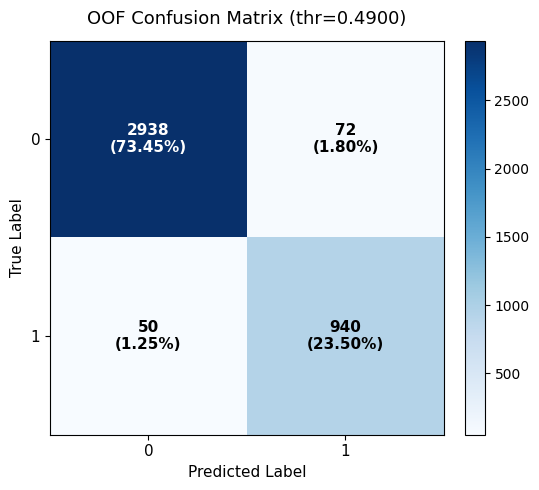


--------------------------------------------------------------------------------
OOF CALIBRATION INPUT PREVIEW (use for calibration / Platt / Isotonic)
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.001244
      0       0.044330
      0       0.001353
      1       0.953762
      0       0.001296
      1       0.981853
      0       0.000843
      0       0.001174
      0       0.002767
      0       0.006433

Shape: (4000, 2)


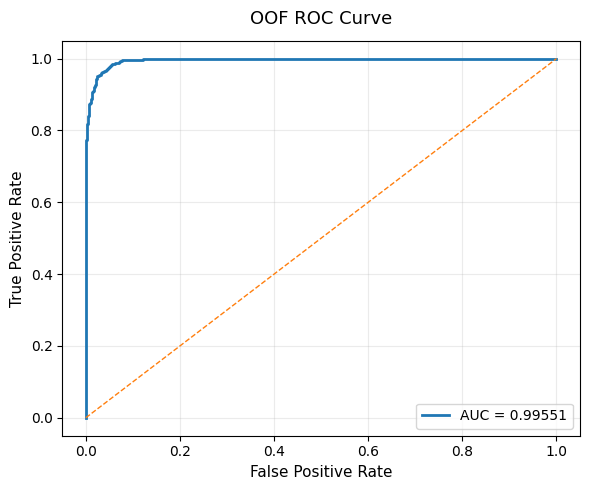


--------------------------------------------------------------------------------
OOF ROC ARRAYS PREVIEW
--------------------------------------------------------------------------------
     fpr      tpr  threshold
0.000000 0.000000        inf
0.000000 0.001010   0.997582
0.000000 0.073737   0.996218
0.000000 0.075758   0.996202
0.000000 0.129293   0.995885
0.000000 0.131313   0.995882
0.000000 0.575758   0.983405
0.000332 0.575758   0.983399
0.000332 0.702020   0.968782
0.000664 0.702020   0.968755

Shape: (206, 3)

--------------------------------------------------------------------------------
FINAL VALIDATION CALIBRATION INPUT PREVIEW (good for Platt / Isotonic)
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.006707
      0       0.010549
      0       0.006769
      1       0.952224
      0       0.033166
      1       0.952310
      1       0.951448
      0       0.006907
      0       0.006545
      0       

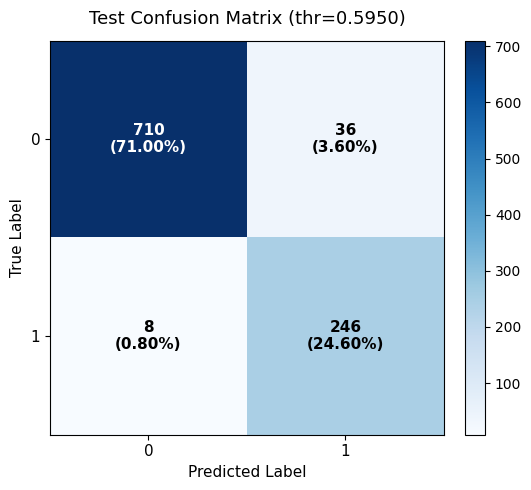


--------------------------------------------------------------------------------
TEST CALIBRATION INPUT PREVIEW
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.006708
      0       0.118914
      1       0.952317
      0       0.270700
      0       0.006694
      0       0.006783
      1       0.951735
      0       0.006875
      0       0.006836
      0       0.019612

Shape: (1000, 2)


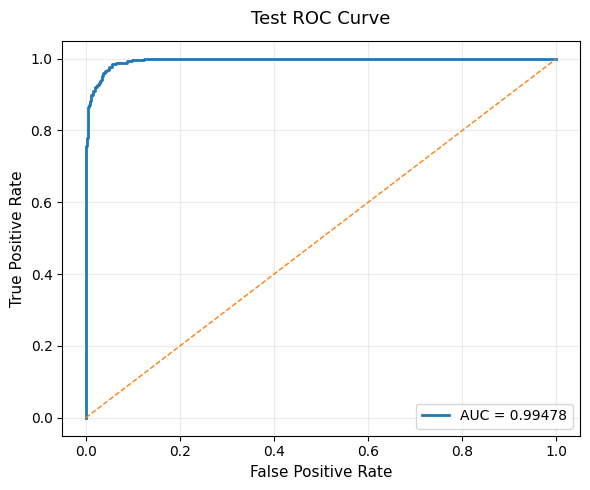


--------------------------------------------------------------------------------
TEST ROC ARRAYS PREVIEW
--------------------------------------------------------------------------------
     fpr      tpr  threshold
0.000000 0.000000        inf
0.000000 0.003937   0.954559
0.000000 0.070866   0.953557
0.000000 0.078740   0.953540
0.000000 0.287402   0.952360
0.000000 0.295276   0.952357
0.000000 0.618110   0.949919
0.001340 0.618110   0.949870
0.001340 0.755906   0.947971
0.002681 0.755906   0.947810

Shape: (74, 3)

READY VARIABLES IN MEMORY
                                     Use            Variable Name   Shape
                         OOF true labels   y_true_oof_calibration (4000,)
             OOF probabilities (class 1)   y_prob_oof_calibration (4000,)
            Final validation true labels y_true_valid_calibration  (400,)
Final validation probabilities (class 1) y_prob_valid_calibration  (400,)
                 Final validation logits logits_valid_temperature  (400,)
       

In [2]:
import os
import json
import time
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    matthews_corrcoef,
    confusion_matrix,
    balanced_accuracy_score,
    brier_score_loss,
    roc_curve,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

TRAIN_PATH = "/content/train_fs_selected.csv"
TEST_PATH  = "/content/test_fs_selected.csv"
TARGET_COLUMN = "lung_cancer_risk"
ID_COLUMNS = []
DROP_COLUMNS = []

OUTPUT_DIR = "/content/fast_nested_tabsymformer_fast_f1fix"
SAVE_OUTPUTS = False
SHOW_PLOTS = False

SEED = 42

OUTER_FOLDS = 5
INNER_FOLDS = 2

N_TRIALS = 3
MAX_EPOCHS_INNER = 6
MAX_EPOCHS_OUTER = 10
MAX_EPOCHS_FINAL = 12

PATIENCE_INNER = 2
PATIENCE_OUTER = 3
PATIENCE_FINAL = 3

OUTER_DEV_VALID_SIZE = 0.12
FINAL_VALID_SIZE = 0.10

USE_AMP = True
NUM_WORKERS = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

THRESHOLD_GRID = np.linspace(0.16, 0.60, 177)
ACC_DROP_TOL = 0.0015

MIN_DYNAMIC_PRECISION = 0.970
PRECISION_RELAX = 0.012

USE_MILD_POS_WEIGHT = True
POS_WEIGHT_POWER = 0.35
POS_WEIGHT_MAX = 1.25

HP_ACC_TOL = 0.0015

FINAL_ENSEMBLE_SEEDS = [42]

SEARCH_CANDIDATES = [
    {"embed_dim": 128, "num_heads": 4, "depth": 2, "ff_mult": 2.0, "dropout": 0.08, "token_dropout": 0.01, "lr": 1.0e-3, "weight_decay": 1e-5, "batch_size": 2048},
    {"embed_dim": 160, "num_heads": 4, "depth": 2, "ff_mult": 2.0, "dropout": 0.10, "token_dropout": 0.02, "lr": 8.0e-4, "weight_decay": 1e-5, "batch_size": 2048},
    {"embed_dim": 192, "num_heads": 4, "depth": 3, "ff_mult": 2.0, "dropout": 0.10, "token_dropout": 0.02, "lr": 8.0e-4, "weight_decay": 1e-5, "batch_size": 1024},
]

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

def now():
    return time.strftime("%H:%M:%S")

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def safe_read_csv(path):
    if path is None or str(path).strip() == "":
        return None
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)

def to_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def clip_probs(prob, eps=1e-7):
    return np.clip(np.asarray(prob, dtype=np.float64), eps, 1 - eps)

def safe_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, prob))

def safe_pr_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, prob))

def metric_score_binary(y_true, y_pred, metric_name="accuracy"):
    if metric_name == "accuracy":
        return accuracy_score(y_true, y_pred)
    if metric_name == "f1":
        return f1_score(y_true, y_pred, zero_division=0)
    if metric_name == "mcc":
        return matthews_corrcoef(y_true, y_pred)
    if metric_name == "balanced_accuracy":
        return balanced_accuracy_score(y_true, y_pred)
    raise ValueError(f"Unsupported metric: {metric_name}")

def _threshold_table(y_true, prob, grid):
    rows = []
    prob = clip_probs(prob)

    for t in grid:
        pred = (prob >= t).astype(int)
        acc = accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)
        f1v = f1_score(y_true, pred, zero_division=0)
        mcc = matthews_corrcoef(y_true, pred)

        rows.append({
            "threshold": float(t),
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1v),
            "mcc": float(mcc),
        })

    return pd.DataFrame(rows)

def _pick_best_threshold_from_df(df_thr: pd.DataFrame) -> float:
    """
    Tie-break order after accuracy safety:
    1) max F1
    2) max Recall
    3) max Accuracy
    4) max MCC
    5) max Precision
    6) lower threshold
    """
    if df_thr.empty:
        return 0.50

    df_thr = df_thr.sort_values(
        by=["f1", "recall", "accuracy", "mcc", "precision", "threshold"],
        ascending=[False, False, False, False, False, True]
    ).reset_index(drop=True)

    return float(df_thr.loc[0, "threshold"])

def tune_threshold_constrained(
    y_true,
    prob,
    grid=None,
    acc_drop_tol=0.0015,
    min_dynamic_precision=0.970,
    precision_relax=0.012,
):
    """
    Accuracy-safe threshold tuning with dynamic precision protection.

    Steps:
    1) compute full threshold table
    2) keep thresholds within best-accuracy tolerance
    3) estimate precision at the best-accuracy operating region
    4) allow a small precision relaxation from that reference
    5) inside that safe region, maximize F1 -> Recall -> Accuracy -> MCC
    """
    if grid is None:
        grid = np.linspace(0.16, 0.60, 177)

    prob = clip_probs(prob)
    thr_df = _threshold_table(y_true, prob, grid)

    best_acc = float(thr_df["accuracy"].max())
    acc_floor = best_acc - float(acc_drop_tol)

    safe_df = thr_df.loc[thr_df["accuracy"] >= acc_floor].copy()
    if safe_df.empty:
        safe_df = thr_df.copy()

    best_acc_df = thr_df.loc[thr_df["accuracy"] >= best_acc - 1e-12].copy()
    best_acc_df = best_acc_df.sort_values(
        by=["f1", "recall", "mcc", "precision", "threshold"],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

    ref_precision = float(best_acc_df.loc[0, "precision"])
    precision_floor = max(float(min_dynamic_precision), ref_precision - float(precision_relax))

    guarded_df = safe_df.loc[safe_df["precision"] >= precision_floor].copy()
    if guarded_df.empty:
        guarded_df = safe_df.copy()

    return _pick_best_threshold_from_df(guarded_df)

def choose_best_hp_info(info_list, acc_tol=0.0015):
    """
    Keep only HPs within best accuracy tolerance,
    then choose the one with better F1 / recall / MCC.
    """
    rows = []
    for i, info in enumerate(info_list):
        m = info["metrics"]
        rows.append({
            "idx": i,
            "accuracy": float(m["accuracy"]),
            "f1": float(m["f1"]),
            "recall": float(m["recall"]),
            "precision": float(m["precision"]),
            "mcc": float(m["mcc"]),
            "logloss": float(m["logloss"]),
        })

    df = pd.DataFrame(rows)
    best_acc = float(df["accuracy"].max())

    keep = df.loc[df["accuracy"] >= best_acc - float(acc_tol)].copy()
    keep = keep.sort_values(
        by=["f1", "recall", "mcc", "precision", "accuracy", "logloss"],
        ascending=[False, False, False, False, False, True]
    ).reset_index(drop=True)

    return info_list[int(keep.loc[0, "idx"])]

def compute_metrics(y_true, prob, threshold=0.5):
    prob = clip_probs(prob)
    pred = (prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "specificity": float(specificity),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "roc_auc": safe_auc(y_true, prob),
        "pr_auc": safe_pr_auc(y_true, prob),
        "logloss": float(log_loss(y_true, prob, labels=[0, 1])),
        "brier": float(brier_score_loss(y_true, prob)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def plot_conf_matrix(cm, title="Confusion Matrix", class_names=("0", "1")):
    cm = np.asarray(cm)
    total = cm.sum()
    pct = (cm / total * 100.0) if total > 0 else np.zeros_like(cm, dtype=float)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)

    thresh = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f"{cm[i, j]}\n({pct[i, j]:.2f}%)",
                ha="center", va="center",
                fontsize=11,
                fontweight="bold",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()

def plot_roc_curve_from_prob(y_true, prob, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        print(f"{title}: skipped because only one class is present.")
        return None, None, None, np.nan

    fpr, tpr, thresholds = roc_curve(y_true, prob)
    auc_val = roc_auc_score(y_true, prob)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.5f}")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    ax.legend(loc="lower right")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return fpr, tpr, thresholds, auc_val

def print_preview_table(df, title, n=10):
    print("\n" + "-" * 80)
    print(title)
    print("-" * 80)
    print(df.head(n).to_string(index=False))
    print(f"\nShape: {df.shape}")

def hp_to_str(hp):
    return (
        f"embed={hp['embed_dim']} | heads={hp['num_heads']} | depth={hp['depth']} | "
        f"ff_mult={hp['ff_mult']} | drop={hp['dropout']} | tok_drop={hp['token_dropout']} | "
        f"lr={hp['lr']} | wd={hp['weight_decay']} | bs={hp['batch_size']}"
    )

class FoldPreprocessor:
    def __init__(self):
        self.imputer = SimpleImputer(strategy="median")
        self.scaler = StandardScaler()

    def fit(self, X_df):
        X_num = to_numeric_df(X_df)
        X_imp = self.imputer.fit_transform(X_num)
        self.scaler.fit(X_imp)
        return self

    def transform(self, X_df):
        X_num = to_numeric_df(X_df)
        X_imp = self.imputer.transform(X_num)
        X_scaled = self.scaler.transform(X_imp)
        X_scaled = np.clip(X_scaled, -8.0, 8.0).astype(np.float32)
        return X_scaled

    def fit_transform(self, X_df):
        self.fit(X_df)
        return self.transform(X_df)

class NumericFeatureTokenizer(nn.Module):
    """
    Each scalar feature becomes a learnable token.
    token_j = x_j * W_j + B_j + E_j
    """
    def __init__(self, n_features, embed_dim, token_dropout=0.01):
        super().__init__()
        self.n_features = n_features
        self.embed_dim = embed_dim
        self.token_dropout = float(token_dropout)

        self.weight = nn.Parameter(torch.randn(n_features, embed_dim) * 0.02)
        self.bias = nn.Parameter(torch.zeros(n_features, embed_dim))
        self.feature_embed = nn.Parameter(torch.randn(n_features, embed_dim) * 0.02)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        tokens = x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0) + self.feature_embed.unsqueeze(0)

        if self.training and self.token_dropout > 0:
            keep = (torch.rand((x.size(0), x.size(1), 1), device=x.device) > self.token_dropout).float()
            tokens = tokens * keep

        tokens = self.norm(tokens)
        return tokens

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_mult=2.0, dropout=0.10):
        super().__init__()
        ff_dim = int(embed_dim * ff_mult)

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.drop1 = nn.Dropout(dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff1 = nn.Linear(embed_dim, ff_dim * 2)
        self.ff2 = nn.Linear(ff_dim, embed_dim)
        self.drop2 = nn.Dropout(dropout)

        self.gate = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        y = self.norm1(x)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x = x + self.drop1(attn_out)

        y = self.norm2(x)
        a, b = self.ff1(y).chunk(2, dim=-1)
        y = a * F.gelu(b)
        y = self.ff2(self.drop2(y))

        gate = self.gate(x)
        x = x + gate * y
        return x

class TabFGT(nn.Module):
    """
    Faster custom transformer for encoded numeric tabular data.
    Lighter head: CLS + mean pooling only.
    """
    def __init__(
        self,
        input_dim,
        embed_dim=160,
        num_heads=4,
        depth=2,
        ff_mult=2.0,
        dropout=0.10,
        token_dropout=0.01,
    ):
        super().__init__()

        self.tokenizer = NumericFeatureTokenizer(
            n_features=input_dim,
            embed_dim=embed_dim,
            token_dropout=token_dropout
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.cls_bias = nn.Parameter(torch.zeros(1, 1, embed_dim))

        self.blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ff_mult=ff_mult,
                dropout=dropout
            )
            for _ in range(depth)
        ])

        self.final_norm = nn.LayerNorm(embed_dim)

        head_dim = embed_dim * 2
        hidden2 = max(embed_dim, 128)

        self.head = nn.Sequential(
            nn.LayerNorm(head_dim),
            nn.Linear(head_dim, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, hidden2 // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2 // 2, 1),
        )

    def forward(self, x):
        tok = self.tokenizer(x)
        cls = self.cls_token.expand(x.size(0), -1, -1) + self.cls_bias
        tok = torch.cat([cls, tok], dim=1)

        for block in self.blocks:
            tok = block(tok)

        tok = self.final_norm(tok)

        cls_tok = tok[:, 0]
        feat_tok = tok[:, 1:]
        mean_tok = feat_tok.mean(dim=1)

        rep = torch.cat([cls_tok, mean_tok], dim=1)
        out = self.head(rep).squeeze(1)
        return out

def make_loader(X, y=None, batch_size=1024, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    if y is None:
        ds = TensorDataset(X_t)
    else:
        y_t = torch.tensor(y, dtype=torch.float32)
        ds = TensorDataset(X_t, y_t)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )

@torch.no_grad()
def predict_proba(model, X, batch_size=1024):
    model.eval()
    loader = make_loader(X, y=None, batch_size=batch_size, shuffle=False)
    probs = []

    for batch in loader:
        xb = batch[0].to(DEVICE, non_blocking=True)
        logits = model(xb)
        p = torch.sigmoid(logits).detach().cpu().numpy()
        probs.append(p)

    return np.concatenate(probs).astype(np.float64)

@torch.no_grad()
def predict_logits(model, X, batch_size=1024):
    model.eval()
    loader = make_loader(X, y=None, batch_size=batch_size, shuffle=False)
    logits_all = []

    for batch in loader:
        xb = batch[0].to(DEVICE, non_blocking=True)
        logits = model(xb).detach().cpu().numpy()
        logits_all.append(logits)

    return np.concatenate(logits_all).astype(np.float64)

def train_one_model(
    X_train, y_train,
    X_valid, y_valid,
    hp,
    max_epochs=12,
    patience=3,
    seed=42
):
    set_seed(seed)

    model = TabFGT(
        input_dim=X_train.shape[1],
        embed_dim=hp["embed_dim"],
        num_heads=hp["num_heads"],
        depth=hp["depth"],
        ff_mult=hp["ff_mult"],
        dropout=hp["dropout"],
        token_dropout=hp["token_dropout"],
    ).to(DEVICE)

    train_loader = make_loader(X_train, y_train, batch_size=hp["batch_size"], shuffle=True)
    valid_loader = make_loader(X_valid, y_valid, batch_size=max(1024, hp["batch_size"]), shuffle=False)

    pos_count = max(float(np.sum(np.asarray(y_train) == 1)), 1.0)
    neg_count = max(float(np.sum(np.asarray(y_train) == 0)), 1.0)

    if USE_MILD_POS_WEIGHT:
        pos_weight_value = float(np.clip((neg_count / pos_count) ** POS_WEIGHT_POWER, 1.0, POS_WEIGHT_MAX))
    else:
        pos_weight_value = 1.0

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"]
    )

    steps_per_epoch = max(1, len(train_loader))
    total_steps = max(1, max_epochs * steps_per_epoch)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=hp["lr"],
        total_steps=total_steps,
        pct_start=0.20,
        div_factor=8.0,
        final_div_factor=80.0,
    )

    use_amp_now = bool(USE_AMP and DEVICE.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp_now)

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = np.inf
    best_epoch = 0
    bad_epochs = 0
    min_delta = 5e-4

    for epoch in range(1, max_epochs + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp_now):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

        model.eval()
        val_probs = []
        for xb, _ in valid_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp_now):
                logits = model(xb)
                p = torch.sigmoid(logits)
            val_probs.append(p.detach().cpu().numpy())

        val_probs = np.concatenate(val_probs).astype(np.float64)
        val_loss = log_loss(y_valid, clip_probs(val_probs), labels=[0, 1])

        if val_loss < best_val_loss - min_delta:
            best_val_loss = float(val_loss)
            best_epoch = int(epoch)
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    model.load_state_dict(best_state)
    return model, best_epoch, best_val_loss, pos_weight_value

def inner_cv_score(X_df, y, hp, seed=42):
    skf = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=seed)
    oof_prob = np.zeros(len(y), dtype=np.float64)
    pos_weights_used = []

    for inner_fold, (tr_idx, va_idx) in enumerate(skf.split(X_df, y), start=1):
        X_tr_df = X_df.iloc[tr_idx].reset_index(drop=True)
        X_va_df = X_df.iloc[va_idx].reset_index(drop=True)
        y_tr = y[tr_idx]
        y_va = y[va_idx]

        prep = FoldPreprocessor()
        X_tr = prep.fit_transform(X_tr_df)
        X_va = prep.transform(X_va_df)

        model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
            X_tr, y_tr,
            X_va, y_va,
            hp=hp,
            max_epochs=MAX_EPOCHS_INNER,
            patience=PATIENCE_INNER,
            seed=seed + inner_fold * 77
        )
        pos_weights_used.append(float(pos_weight_value))

        prob = predict_proba(model, X_va, batch_size=max(1024, hp["batch_size"]))
        oof_prob[va_idx] = prob

    best_thr = tune_threshold_constrained(
        y_true=y,
        prob=oof_prob,
        grid=THRESHOLD_GRID,
        acc_drop_tol=ACC_DROP_TOL,
        min_dynamic_precision=MIN_DYNAMIC_PRECISION,
        precision_relax=PRECISION_RELAX,
    )
    metrics = compute_metrics(y, oof_prob, threshold=best_thr)

    return {
        "hp": hp,
        "threshold": best_thr,
        "metrics": metrics,
        "score": metrics["accuracy"],
        "mean_pos_weight": float(np.mean(pos_weights_used)) if len(pos_weights_used) > 0 else 1.0,
    }

set_seed(SEED)
ensure_dir(OUTPUT_DIR)

print("\n" + "=" * 80)
print(f"[{now()}] LOADING DATA")
print("=" * 80)

train_df = safe_read_csv(TRAIN_PATH)
test_df = safe_read_csv(TEST_PATH)

if TARGET_COLUMN not in train_df.columns:
    raise ValueError(f"Target column '{TARGET_COLUMN}' not found.")

drop_train = list(set(ID_COLUMNS + DROP_COLUMNS + [TARGET_COLUMN]))
X_train_df = train_df.drop(columns=[c for c in drop_train if c in train_df.columns], errors="ignore").copy()
y_raw = train_df[TARGET_COLUMN].copy()

le = LabelEncoder()
y = le.fit_transform(y_raw)

if len(le.classes_) != 2:
    raise ValueError(f"Binary classification only. Found classes: {list(le.classes_)}")

class_names = [str(x) for x in le.classes_]

print(f"Train shape   : {train_df.shape}")
print(f"Feature shape : {X_train_df.shape}")
print(f"Classes       : {class_names}")
print(f"Device        : {DEVICE}")

if test_df is not None:
    drop_test = list(set(ID_COLUMNS + DROP_COLUMNS + [TARGET_COLUMN]))
    X_test_df = test_df.drop(columns=[c for c in drop_test if c in test_df.columns], errors="ignore").copy()

    if TARGET_COLUMN in test_df.columns:
        y_test = le.transform(test_df[TARGET_COLUMN])
        has_test_labels = True
    else:
        y_test = None
        has_test_labels = False

    print(f"Test shape    : {test_df.shape}")
    print(f"Test labels   : {'present' if has_test_labels else 'absent'}")
else:
    X_test_df = None
    y_test = None
    has_test_labels = False

print("\n" + "=" * 80)
print(f"[{now()}] STARTING NESTED CV ({OUTER_FOLDS} OUTER x {INNER_FOLDS} INNER)")
print("=" * 80)

outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)

oof_prob = np.zeros(len(y), dtype=np.float64)
outer_rows = []
outer_thresholds = []
outer_best_hps = []
outer_test_probs = []

candidate_pool = SEARCH_CANDIDATES[:N_TRIALS]

for outer_fold, (dev_idx, hold_idx) in enumerate(outer_cv.split(X_train_df, y), start=1):
    print(f"\n[{now()}] OUTER FOLD {outer_fold}/{OUTER_FOLDS}")

    X_dev_df = X_train_df.iloc[dev_idx].reset_index(drop=True)
    y_dev = y[dev_idx]

    X_hold_df = X_train_df.iloc[hold_idx].reset_index(drop=True)
    y_hold = y[hold_idx]

    fold_infos = []

    for trial_id, hp in enumerate(candidate_pool, start=1):
        info = inner_cv_score(
            X_df=X_dev_df,
            y=y_dev,
            hp=hp,
            seed=SEED + outer_fold * 100 + trial_id
        )
        fold_infos.append(info)

        m = info["metrics"]
        print(
            f"  trial {trial_id}/{len(candidate_pool)} | "
            f"acc={m['accuracy']:.5f} | f1={m['f1']:.5f} | rec={m['recall']:.5f} | "
            f"prec={m['precision']:.5f} | mcc={m['mcc']:.5f} | "
            f"auc={m['roc_auc']:.5f} | logloss={m['logloss']:.5f} | "
            f"thr={info['threshold']:.3f} | pos_w={info['mean_pos_weight']:.3f}"
        )

    best_info = choose_best_hp_info(fold_infos, acc_tol=HP_ACC_TOL)
    best_hp = best_info["hp"]
    best_thr = best_info["threshold"]

    outer_best_hps.append(best_hp)
    outer_thresholds.append(best_thr)

    print(f"  best hp  : {hp_to_str(best_hp)}")
    print(f"  best thr : {best_thr:.3f}")

    X_tr_df, X_va_df, y_tr, y_va = train_test_split(
        X_dev_df, y_dev,
        test_size=OUTER_DEV_VALID_SIZE,
        random_state=SEED + outer_fold,
        stratify=y_dev
    )

    prep = FoldPreprocessor()
    X_tr = prep.fit_transform(X_tr_df)
    X_va = prep.transform(X_va_df)
    X_hold = prep.transform(X_hold_df)

    model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
        X_tr, y_tr,
        X_va, y_va,
        hp=best_hp,
        max_epochs=MAX_EPOCHS_OUTER,
        patience=PATIENCE_OUTER,
        seed=SEED + outer_fold * 1000
    )

    hold_prob = predict_proba(model, X_hold, batch_size=max(1024, best_hp["batch_size"]))
    oof_prob[hold_idx] = hold_prob

    fold_metrics = compute_metrics(y_hold, hold_prob, threshold=best_thr)
    fold_metrics["outer_fold"] = outer_fold
    fold_metrics["best_epoch"] = best_epoch
    fold_metrics["best_val_loss"] = best_val_loss
    fold_metrics["pos_weight"] = float(pos_weight_value)
    outer_rows.append(fold_metrics)

    print(
        f"  fold result | acc={fold_metrics['accuracy']:.5f} | "
        f"prec={fold_metrics['precision']:.5f} | rec={fold_metrics['recall']:.5f} | "
        f"spec={fold_metrics['specificity']:.5f} | f1={fold_metrics['f1']:.5f} | "
        f"mcc={fold_metrics['mcc']:.5f} | auc={fold_metrics['roc_auc']:.5f} | "
        f"logloss={fold_metrics['logloss']:.5f}"
    )

    if X_test_df is not None:
        X_test_proc = prep.transform(X_test_df)
        test_prob_fold = predict_proba(model, X_test_proc, batch_size=max(1024, best_hp["batch_size"]))
        outer_test_probs.append(test_prob_fold)

outer_df = pd.DataFrame(outer_rows)

global_threshold = tune_threshold_constrained(
    y_true=y,
    prob=oof_prob,
    grid=THRESHOLD_GRID,
    acc_drop_tol=ACC_DROP_TOL,
    min_dynamic_precision=MIN_DYNAMIC_PRECISION,
    precision_relax=PRECISION_RELAX,
)

oof_metrics = compute_metrics(y, oof_prob, threshold=global_threshold)

print("\n" + "=" * 80)
print(f"[{now()}] NESTED CV SUMMARY")
print("=" * 80)
print(outer_df[
    ["outer_fold", "accuracy", "precision", "recall", "specificity", "f1",
     "mcc", "balanced_accuracy", "roc_auc", "pr_auc", "logloss", "threshold", "pos_weight"]
].round(5).to_string(index=False))

print("\nOOF SUMMARY")
print(pd.DataFrame([oof_metrics]).round(5).to_string(index=False))

if SHOW_PLOTS:
    cm_oof = confusion_matrix(y, (oof_prob >= global_threshold).astype(int), labels=[0, 1])
    plot_conf_matrix(
        cm_oof,
        title=f"OOF Confusion Matrix (thr={global_threshold:.3f})",
        class_names=class_names
    )

hp_keys = [tuple(sorted(hp.items())) for hp in outer_best_hps]
hp_counter = Counter(hp_keys)
max_count = max(hp_counter.values())
candidates = [dict(k) for k, v in hp_counter.items() if v == max_count]

if len(candidates) == 1:
    final_best_hp = candidates[0]
else:
    rows = []
    for cand in candidates:
        mask = [hp == cand for hp in outer_best_hps]
        rows.append({
            "hp": cand,
            "mean_acc": float(outer_df.loc[mask, "accuracy"].mean()),
            "mean_f1": float(outer_df.loc[mask, "f1"].mean()),
            "mean_recall": float(outer_df.loc[mask, "recall"].mean()),
            "mean_mcc": float(outer_df.loc[mask, "mcc"].mean()),
            "mean_logloss": float(outer_df.loc[mask, "logloss"].mean()),
        })

    hp_df = pd.DataFrame(rows)
    best_mean_acc = float(hp_df["mean_acc"].max())

    keep = hp_df.loc[hp_df["mean_acc"] >= best_mean_acc - HP_ACC_TOL].copy()
    keep = keep.sort_values(
        by=["mean_f1", "mean_recall", "mean_mcc", "mean_acc", "mean_logloss"],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

    final_best_hp = keep.iloc[0]["hp"]

print("\n" + "=" * 80)
print(f"[{now()}] FINAL CHOSEN SETTINGS")
print("=" * 80)
print("Final best hyperparameters:")
print(json.dumps(final_best_hp, indent=2))
print(f"OOF-derived threshold: {global_threshold:.4f}")

final_models = []
final_preps = []
final_valid_probs = []
final_valid_targets = []
final_valid_logits = []

for i, seed_i in enumerate(FINAL_ENSEMBLE_SEEDS, start=1):
    print(f"\n[{now()}] FINAL MODEL {i}/{len(FINAL_ENSEMBLE_SEEDS)}")

    X_tr_df, X_va_df, y_tr, y_va = train_test_split(
        X_train_df, y,
        test_size=FINAL_VALID_SIZE,
        random_state=seed_i,
        stratify=y
    )

    prep = FoldPreprocessor()
    X_tr = prep.fit_transform(X_tr_df)
    X_va = prep.transform(X_va_df)

    model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
        X_tr, y_tr,
        X_va, y_va,
        hp=final_best_hp,
        max_epochs=MAX_EPOCHS_FINAL,
        patience=PATIENCE_FINAL,
        seed=seed_i
    )

    final_models.append(model)
    final_preps.append(prep)

    va_prob = predict_proba(model, X_va, batch_size=max(1024, final_best_hp["batch_size"]))
    va_logit = predict_logits(model, X_va, batch_size=max(1024, final_best_hp["batch_size"]))

    final_valid_probs.append(va_prob)
    final_valid_targets.append(np.asarray(y_va, dtype=int))
    final_valid_logits.append(va_logit)

    print(
        f"  best_epoch={best_epoch} | best_val_loss={best_val_loss:.5f} | "
        f"pos_weight={pos_weight_value:.3f}"
    )

def predict_ensemble(models, preps, X_df, batch_size=1024):
    probs = []
    for model, prep in zip(models, preps):
        X_proc = prep.transform(X_df)
        p = predict_proba(model, X_proc, batch_size=batch_size)
        probs.append(p)
    return np.mean(np.vstack(probs), axis=0)

final_valid_prob = None
final_valid_y = None
final_valid_logit = None

if len(final_valid_probs) > 0:
    final_valid_prob = np.concatenate(final_valid_probs).astype(np.float64)
    final_valid_y = np.concatenate(final_valid_targets).astype(int)
    final_valid_logit = np.concatenate(final_valid_logits).astype(np.float64)

    final_threshold = tune_threshold_constrained(
        y_true=final_valid_y,
        prob=final_valid_prob,
        grid=THRESHOLD_GRID,
        acc_drop_tol=ACC_DROP_TOL,
        min_dynamic_precision=MIN_DYNAMIC_PRECISION,
        precision_relax=PRECISION_RELAX,
    )
else:
    final_threshold = global_threshold

print(f"\n[{now()}] FINAL DEPLOYMENT THRESHOLD: {final_threshold:.4f}")

if X_test_df is not None:
    print("\n" + "=" * 80)
    print(f"[{now()}] TEST RESULT")
    print("=" * 80)

    final_test_prob = predict_ensemble(
        final_models,
        final_preps,
        X_test_df,
        batch_size=max(1024, final_best_hp["batch_size"])
    )
    final_test_pred = (final_test_prob >= final_threshold).astype(int)

    if has_test_labels:
        test_metrics = compute_metrics(y_test, final_test_prob, threshold=final_threshold)
        print(pd.DataFrame([test_metrics]).round(5).to_string(index=False))

        if SHOW_PLOTS:
            cm_test = confusion_matrix(y_test, final_test_pred, labels=[0, 1])
            plot_conf_matrix(
                cm_test,
                title=f"Test Confusion Matrix (thr={final_threshold:.3f})",
                class_names=class_names
            )

        if len(outer_test_probs) > 0:
            nested_test_prob = np.mean(np.vstack(outer_test_probs), axis=0)
            nested_test_metrics = compute_metrics(y_test, nested_test_prob, threshold=global_threshold)

            print("\nOuter-fold test ensemble reference:")
            print(pd.DataFrame([nested_test_metrics]).round(5).to_string(index=False))
    else:
        test_metrics = None
        print("Test labels not available.")
else:
    final_test_prob = None
    final_test_pred = None
    test_metrics = None

if SAVE_OUTPUTS:
    ensure_dir(OUTPUT_DIR)

    outer_df.to_csv(os.path.join(OUTPUT_DIR, "outer_fold_results.csv"), index=False)
    pd.DataFrame([oof_metrics]).to_csv(os.path.join(OUTPUT_DIR, "oof_metrics.csv"), index=False)

    with open(os.path.join(OUTPUT_DIR, "final_best_hyperparameters.json"), "w") as f:
        json.dump(
            {
                "best_hyperparameters": final_best_hp,
                "oof_global_threshold": global_threshold,
                "final_threshold": final_threshold,
                "classes": class_names,
                "device": str(DEVICE),
                "model_name": "TabFGT-Fast-F1Fix",
                "threshold_grid_start": float(THRESHOLD_GRID[0]),
                "threshold_grid_end": float(THRESHOLD_GRID[-1]),
                "acc_drop_tol": float(ACC_DROP_TOL),
                "min_dynamic_precision": float(MIN_DYNAMIC_PRECISION),
                "precision_relax": float(PRECISION_RELAX),
                "use_mild_pos_weight": bool(USE_MILD_POS_WEIGHT),
                "pos_weight_power": float(POS_WEIGHT_POWER),
                "pos_weight_max": float(POS_WEIGHT_MAX),
                "hp_acc_tol": float(HP_ACC_TOL),
            },
            f,
            indent=2
        )

    oof_pred = (oof_prob >= global_threshold).astype(int)
    oof_df = pd.DataFrame({
        "true_label_encoded": y,
        "true_label": [class_names[i] for i in y],
        "prob_positive": oof_prob,
        "pred_label_encoded": oof_pred,
        "pred_label": [class_names[i] for i in oof_pred],
    })
    if ID_COLUMNS:
        ids = [c for c in ID_COLUMNS if c in train_df.columns]
        if len(ids) > 0:
            oof_df = pd.concat([train_df[ids].reset_index(drop=True), oof_df], axis=1)
    oof_df.to_csv(os.path.join(OUTPUT_DIR, "oof_predictions.csv"), index=False)

    if X_test_df is not None:
        test_out = pd.DataFrame({
            "prob_positive": final_test_prob,
            "pred_label_encoded": final_test_pred,
            "pred_label": [class_names[i] for i in final_test_pred],
        })
        if ID_COLUMNS:
            ids = [c for c in ID_COLUMNS if c in test_df.columns]
            if len(ids) > 0:
                test_out = pd.concat([test_df[ids].reset_index(drop=True), test_out], axis=1)
        test_out.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)

    print("\nSaved outputs in:", OUTPUT_DIR)

print("\n" + "=" * 80)
print(f"[{now()}] FINAL REPORT")
print("=" * 80)
print(f"Model         : TabFGT-Fast-F1Fix")
print(f"Final HP      : {hp_to_str(final_best_hp)}")
print(f"OOF thr       : {global_threshold:.4f}")
print(f"Final thr     : {final_threshold:.4f}")
print(f"OOF accuracy  : {oof_metrics['accuracy']:.5f}")
print(f"OOF precision : {oof_metrics['precision']:.5f}")
print(f"OOF recall    : {oof_metrics['recall']:.5f}")
print(f"OOF spec      : {oof_metrics['specificity']:.5f}")
print(f"OOF f1        : {oof_metrics['f1']:.5f}")
print(f"OOF mcc       : {oof_metrics['mcc']:.5f}")
print(f"OOF roc_auc   : {oof_metrics['roc_auc']:.5f}")
print(f"OOF logloss   : {oof_metrics['logloss']:.5f}")

if test_metrics is not None:
    print("\nTEST headline metrics")
    print(f"Test accuracy : {test_metrics['accuracy']:.5f}")
    print(f"Test precision: {test_metrics['precision']:.5f}")
    print(f"Test recall   : {test_metrics['recall']:.5f}")
    print(f"Test spec     : {test_metrics['specificity']:.5f}")
    print(f"Test f1       : {test_metrics['f1']:.5f}")
    print(f"Test mcc      : {test_metrics['mcc']:.5f}")
    print(f"Test roc_auc  : {test_metrics['roc_auc']:.5f}")
    print(f"Test logloss  : {test_metrics['logloss']:.5f}")

print("\n" + "=" * 80)
print(f"[{now()}] DISPLAY OUTPUTS")
print("=" * 80)

y_true_oof_calibration = np.asarray(y, dtype=int)
y_prob_oof_calibration = np.asarray(oof_prob, dtype=np.float64)
y_pred_oof_display = (y_prob_oof_calibration >= global_threshold).astype(int)

cm_oof_display = confusion_matrix(y_true_oof_calibration, y_pred_oof_display, labels=[0, 1])

print("\nOOF CONFUSION MATRIX")
print(pd.DataFrame(
    cm_oof_display,
    index=[f"True_{class_names[0]}", f"True_{class_names[1]}"],
    columns=[f"Pred_{class_names[0]}", f"Pred_{class_names[1]}"]
).to_string())

plot_conf_matrix(
    cm_oof_display,
    title=f"OOF Confusion Matrix (thr={global_threshold:.4f})",
    class_names=class_names
)

oof_calibration_df = pd.DataFrame({
    "y_true": y_true_oof_calibration,
    "y_prob_class1": y_prob_oof_calibration
})

print_preview_table(
    oof_calibration_df,
    "OOF CALIBRATION INPUT PREVIEW (use for calibration / Platt / Isotonic)",
    n=10
)

oof_roc_fpr, oof_roc_tpr, oof_roc_thresholds, oof_roc_auc = plot_roc_curve_from_prob(
    y_true_oof_calibration,
    y_prob_oof_calibration,
    title="OOF ROC Curve"
)

if oof_roc_fpr is not None:
    oof_roc_df = pd.DataFrame({
        "fpr": oof_roc_fpr,
        "tpr": oof_roc_tpr,
        "threshold": oof_roc_thresholds
    })
    print_preview_table(
        oof_roc_df,
        "OOF ROC ARRAYS PREVIEW",
        n=10
    )

if final_valid_prob is not None and final_valid_y is not None:
    y_true_valid_calibration = np.asarray(final_valid_y, dtype=int)
    y_prob_valid_calibration = np.asarray(final_valid_prob, dtype=np.float64)

    valid_calibration_df = pd.DataFrame({
        "y_true": y_true_valid_calibration,
        "y_prob_class1": y_prob_valid_calibration
    })

    print_preview_table(
        valid_calibration_df,
        "FINAL VALIDATION CALIBRATION INPUT PREVIEW (good for Platt / Isotonic)",
        n=10
    )

    if final_valid_logit is not None:
        logits_valid_temperature = np.asarray(final_valid_logit, dtype=np.float64)

        valid_temperature_df = pd.DataFrame({
            "y_true": y_true_valid_calibration,
            "logit": logits_valid_temperature
        })

        print_preview_table(
            valid_temperature_df,
            "FINAL VALIDATION TEMPERATURE-SCALING INPUT PREVIEW (y_true + logits)",
            n=10
        )
    else:
        logits_valid_temperature = None
else:
    y_true_valid_calibration = None
    y_prob_valid_calibration = None
    logits_valid_temperature = None

if final_test_prob is not None and has_test_labels:
    y_true_test_calibration = np.asarray(y_test, dtype=int)
    y_prob_test_calibration = np.asarray(final_test_prob, dtype=np.float64)
    y_pred_test_display = (y_prob_test_calibration >= final_threshold).astype(int)

    cm_test_display = confusion_matrix(y_true_test_calibration, y_pred_test_display, labels=[0, 1])

    print("\nTEST CONFUSION MATRIX")
    print(pd.DataFrame(
        cm_test_display,
        index=[f"True_{class_names[0]}", f"True_{class_names[1]}"],
        columns=[f"Pred_{class_names[0]}", f"Pred_{class_names[1]}"]
    ).to_string())

    plot_conf_matrix(
        cm_test_display,
        title=f"Test Confusion Matrix (thr={final_threshold:.4f})",
        class_names=class_names
    )

    test_calibration_df = pd.DataFrame({
        "y_true": y_true_test_calibration,
        "y_prob_class1": y_prob_test_calibration
    })

    print_preview_table(
        test_calibration_df,
        "TEST CALIBRATION INPUT PREVIEW",
        n=10
    )

    test_roc_fpr, test_roc_tpr, test_roc_thresholds, test_roc_auc = plot_roc_curve_from_prob(
        y_true_test_calibration,
        y_prob_test_calibration,
        title="Test ROC Curve"
    )

    if test_roc_fpr is not None:
        test_roc_df = pd.DataFrame({
            "fpr": test_roc_fpr,
            "tpr": test_roc_tpr,
            "threshold": test_roc_thresholds
        })
        print_preview_table(
            test_roc_df,
            "TEST ROC ARRAYS PREVIEW",
            n=10
        )
else:
    y_true_test_calibration = None
    y_prob_test_calibration = None
    test_roc_fpr = None
    test_roc_tpr = None
    test_roc_thresholds = None
    test_roc_auc = None

print("\n" + "=" * 80)
print("READY VARIABLES IN MEMORY")
print("=" * 80)

ready_rows = [
    ["OOF true labels", "y_true_oof_calibration", None if y_true_oof_calibration is None else y_true_oof_calibration.shape],
    ["OOF probabilities (class 1)", "y_prob_oof_calibration", None if y_prob_oof_calibration is None else y_prob_oof_calibration.shape],
    ["Final validation true labels", "y_true_valid_calibration", None if y_true_valid_calibration is None else y_true_valid_calibration.shape],
    ["Final validation probabilities (class 1)", "y_prob_valid_calibration", None if y_prob_valid_calibration is None else y_prob_valid_calibration.shape],
    ["Final validation logits", "logits_valid_temperature", None if logits_valid_temperature is None else logits_valid_temperature.shape],
    ["Test true labels", "y_true_test_calibration", None if y_true_test_calibration is None else y_true_test_calibration.shape],
    ["Test probabilities (class 1)", "y_prob_test_calibration", None if y_prob_test_calibration is None else y_prob_test_calibration.shape],
    ["OOF ROC FPR", "oof_roc_fpr", None if oof_roc_fpr is None else oof_roc_fpr.shape],
    ["OOF ROC TPR", "oof_roc_tpr", None if oof_roc_tpr is None else oof_roc_tpr.shape],
    ["OOF ROC thresholds", "oof_roc_thresholds", None if oof_roc_thresholds is None else oof_roc_thresholds.shape],
    ["Test ROC FPR", "test_roc_fpr", None if test_roc_fpr is None else test_roc_fpr.shape],
    ["Test ROC TPR", "test_roc_tpr", None if test_roc_tpr is None else test_roc_tpr.shape],
    ["Test ROC thresholds", "test_roc_thresholds", None if test_roc_thresholds is None else test_roc_thresholds.shape],
]

ready_df = pd.DataFrame(ready_rows, columns=["Use", "Variable Name", "Shape"])
print(ready_df.to_string(index=False))

print("\nBEST TO USE FOR CALIBRATION")
print("- OOF true labels + OOF probabilities      : y_true_oof_calibration, y_prob_oof_calibration")
if y_true_test_calibration is not None and y_prob_test_calibration is not None:
    print("- Test true labels + test probabilities    : y_true_test_calibration, y_prob_test_calibration")
if y_true_valid_calibration is not None and y_prob_valid_calibration is not None:
    print("- Validation true labels + probabilities   : y_true_valid_calibration, y_prob_valid_calibration")
if logits_valid_temperature is not None and y_true_valid_calibration is not None:
    print("- Temperature scaling inputs               : y_true_valid_calibration, logits_valid_temperature")

print("\nBEST TO USE FOR ROC")
print("- OOF ROC arrays  : oof_roc_fpr, oof_roc_tpr, oof_roc_thresholds")
if test_roc_fpr is not None:
    print("- Test ROC arrays : test_roc_fpr, test_roc_tpr, test_roc_thresholds")

#**MI based**

In [ ]:
TARGET_COL = "lung_cancer_risk"
USE_EXISTING_DATAFRAMES = False
TRAIN_DF_NAME = "train_df"
TEST_DF_NAME = "test_df"

TRAIN_PATH = "/content/train.csv"
TEST_PATH = "/content/test.csv"

ID_COLS = []
OUTPUT_DIR = "/content"

TRAIN_OUTPUT_PATH = f"{OUTPUT_DIR}/train_fs_selected.csv"
TEST_OUTPUT_PATH = f"{OUTPUT_DIR}/test_fs_selected.csv"
FEATURE_LIST_PATH = f"{OUTPUT_DIR}/selected_features.csv"

TOP_K_MODE = "auto"
TOP_K_VALUE = None

RANDOM_STATE = 42
VERBOSE = True

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy import sparse
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (
    SelectKBest,
    VarianceThreshold,
    mutual_info_classif,
    mutual_info_regression,
)

def _print(msg=""):
    if VERBOSE:
        print(msg)

def load_dataframe():
    if USE_EXISTING_DATAFRAMES:
        if TRAIN_DF_NAME not in globals():
            raise ValueError(f"'{TRAIN_DF_NAME}' not found in memory.")
        if TEST_DF_NAME not in globals():
            raise ValueError(f"'{TEST_DF_NAME}' not found in memory.")
        train_df = globals()[TRAIN_DF_NAME].copy()
        test_df = globals()[TEST_DF_NAME].copy()
    else:
        if not os.path.exists(TRAIN_PATH):
            raise FileNotFoundError(f"Train file not found: {TRAIN_PATH}")
        if not os.path.exists(TEST_PATH):
            raise FileNotFoundError(f"Test file not found: {TEST_PATH}")
        train_df = pd.read_csv(TRAIN_PATH)
        test_df = pd.read_csv(TEST_PATH)
    return train_df, test_df

def infer_task_type(y: pd.Series) -> str:
    """Infer classification vs regression adaptively."""
    if pd.api.types.is_bool_dtype(y) or pd.api.types.is_object_dtype(y) or pd.api.types.is_categorical_dtype(y):
        return "classification"

    if pd.api.types.is_integer_dtype(y):
        nunique = y.nunique(dropna=True)
        n = len(y)
        if nunique <= max(20, int(0.05 * n)):
            return "classification"

    if pd.api.types.is_float_dtype(y):
        nunique = y.nunique(dropna=True)
        n = len(y)
        if nunique <= max(10, int(0.03 * n)):
            return "classification"

    return "regression"

def align_test_to_train_columns(X_train: pd.DataFrame, X_test: pd.DataFrame):
    """Strictly keep train feature schema; add missing test cols as NaN, drop extra test cols."""
    train_cols = list(X_train.columns)

    for col in train_cols:
        if col not in X_test.columns:
            X_test[col] = np.nan

    extra_test_cols = [c for c in X_test.columns if c not in train_cols]
    if extra_test_cols:
        X_test = X_test.drop(columns=extra_test_cols)

    X_test = X_test[train_cols]
    return X_train, X_test

def get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols):
    """Robust feature name extraction after preprocessing."""
    feature_names = []

    if len(numeric_cols) > 0:
        feature_names.extend([f"num__{c}" for c in numeric_cols])

    if len(categorical_cols) > 0:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(categorical_cols)
        feature_names.extend([f"cat__{c}" for c in cat_names])

    return np.array(feature_names, dtype=object)

def choose_auto_k(n_features: int) -> int:
    """Adaptive top-k size, not fixed."""
    if n_features <= 20:
        return n_features
    k = int(max(10, min(n_features, round(np.sqrt(n_features) * 3))))
    return max(1, min(k, n_features))

def to_dense_if_needed(X):
    return X.toarray() if sparse.issparse(X) else X

def build_dataframe_from_matrix(X, feature_names, index=None):
    X_dense = to_dense_if_needed(X)
    return pd.DataFrame(X_dense, columns=feature_names, index=index)

train_df, test_df = load_dataframe()

if TARGET_COL not in train_df.columns:
    raise ValueError(f"TARGET_COL='{TARGET_COL}' not found in train data.")

_print("=" * 90)
_print("Loaded data")
_print(f"Train shape: {train_df.shape}")
_print(f"Test shape : {test_df.shape}")

train_df_original = train_df.copy()
test_df_original = test_df.copy()

y_train_raw = train_df[TARGET_COL].copy()
X_train = train_df.drop(columns=[TARGET_COL]).copy()

if TARGET_COL in test_df.columns:
    y_test_raw = test_df[TARGET_COL].copy()
    X_test = test_df.drop(columns=[TARGET_COL]).copy()
    test_has_target = True
else:
    y_test_raw = None
    X_test = test_df.copy()
    test_has_target = False

drop_cols = [c for c in ID_COLS if c in X_train.columns]
if drop_cols:
    X_train = X_train.drop(columns=drop_cols, errors="ignore")
    X_test = X_test.drop(columns=drop_cols, errors="ignore")

X_train, X_test = align_test_to_train_columns(X_train, X_test)

TASK_TYPE = infer_task_type(y_train_raw)
_print(f"Detected task type: {TASK_TYPE}")

label_encoder = None
if TASK_TYPE == "classification":
    label_encoder = LabelEncoder()
    y_train_model = label_encoder.fit_transform(y_train_raw.astype(str))
else:
    y_train_model = pd.to_numeric(y_train_raw, errors="coerce")
    if pd.isna(y_train_model).any():
        raise ValueError("Target contains non-numeric values, but task was inferred as regression.")

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

_print(f"Numeric columns     : {len(numeric_cols)}")
_print(f"Categorical columns : {len(categorical_cols)}")

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

feature_names_prep = get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols)

_print(f"Features after preprocessing: {X_train_prep.shape[1]}")

vt = VarianceThreshold(threshold=0.0)
X_train_vt = vt.fit_transform(X_train_prep)
X_test_vt = vt.transform(X_test_prep)

vt_mask = vt.get_support()
feature_names_vt = feature_names_prep[vt_mask]

_print(f"Features after removing constant columns: {X_train_vt.shape[1]}")

n_features_after_vt = X_train_vt.shape[1]

if n_features_after_vt == 0:
    raise ValueError("No features left after preprocessing and constant feature removal.")

if TOP_K_MODE == "manual":
    if TOP_K_VALUE is None:
        raise ValueError("TOP_K_VALUE cannot be None when TOP_K_MODE='manual'")
    top_k = max(1, min(int(TOP_K_VALUE), n_features_after_vt))
else:
    top_k = choose_auto_k(n_features_after_vt)

if TASK_TYPE == "classification":
    score_func = mutual_info_classif
else:
    score_func = mutual_info_regression

mi_selector = SelectKBest(score_func=score_func, k=top_k)
X_train_final = mi_selector.fit_transform(X_train_vt, y_train_model)
X_test_final = mi_selector.transform(X_test_vt)

mi_mask = mi_selector.get_support()
final_features = feature_names_vt[mi_mask]

selected_train_df = build_dataframe_from_matrix(X_train_final, final_features, index=train_df_original.index)
selected_test_df = build_dataframe_from_matrix(X_test_final, final_features, index=test_df_original.index)

selected_train_df[TARGET_COL] = y_train_raw.values
if test_has_target:
    selected_test_df[TARGET_COL] = y_test_raw.values

selected_features_df = pd.DataFrame({
    "selected_feature": final_features
})

os.makedirs(OUTPUT_DIR, exist_ok=True)

selected_train_df.to_csv(TRAIN_OUTPUT_PATH, index=False)
selected_test_df.to_csv(TEST_OUTPUT_PATH, index=False)
selected_features_df.to_csv(FEATURE_LIST_PATH, index=False)

summary_df = pd.DataFrame({
    "item": [
        "Task type",
        "Original train rows",
        "Original test rows",
        "Original raw feature count",
        "Features after preprocessing",
        "Features after constant removal",
        "Mutual Information selected",
        "Final selected features",
        "Saved train file",
        "Saved test file",
        "Saved feature list",
    ],
    "value": [
        TASK_TYPE,
        train_df_original.shape[0],
        test_df_original.shape[0],
        X_train.shape[1],
        X_train_prep.shape[1],
        X_train_vt.shape[1],
        len(final_features),
        len(final_features),
        TRAIN_OUTPUT_PATH,
        TEST_OUTPUT_PATH,
        FEATURE_LIST_PATH,
    ]
})

_print("\n" + "=" * 90)
_print("FEATURE SELECTION SUMMARY")
_print("=" * 90)
display(summary_df)

_print("\nPreview of final selected features:")
display(selected_features_df.head(100))

_print("\nTop 20 selected features:")
print(final_features[:20].tolist())

_print("\nSaved files:")
print(f"Train selected file : {TRAIN_OUTPUT_PATH}")
print(f"Test selected file  : {TEST_OUTPUT_PATH}")
print(f"Feature list file   : {FEATURE_LIST_PATH}")

globals()["selected_train_df"] = selected_train_df
globals()["selected_test_df"] = selected_test_df
globals()["selected_features"] = final_features.tolist()
globals()["fs_summary_df"] = summary_df

_print("\nDone. Global outputs created:")
print("selected_train_df")
print("selected_test_df")
print("selected_features")
print("fs_summary_df")

Loaded data
Train shape: (4000, 30)
Test shape : (1000, 30)
Detected task type: classification
Numeric columns     : 29
Categorical columns : 0
Features after preprocessing: 29
Features after removing constant columns: 29

FEATURE SELECTION SUMMARY


,item,value
0,Task type,classification
1,Original train rows,4000
2,Original test rows,1000
3,Original raw feature count,29
4,Features after preprocessing,29
5,Features after constant removal,29
6,Mutual Information selected,16
7,Final selected features,16
8,Saved train file,/content/train_fs_selected.csv
9,Saved test file,/content/test_fs_selected.csv



Preview of final selected features:


,selected_feature
0,num__age
1,num__smoker
2,num__smoking_years
3,num__cigarettes_per_day
4,num__pack_years
5,num__occupational_exposure
6,num__copd
7,num__chronic_cough
8,num__chest_pain
9,num__shortness_of_breath



Top 20 selected features:
['num__age', 'num__smoker', 'num__smoking_years', 'num__cigarettes_per_day', 'num__pack_years', 'num__occupational_exposure', 'num__copd', 'num__chronic_cough', 'num__chest_pain', 'num__shortness_of_breath', 'num__oxygen_saturation', 'num__fev1_x10', 'num__crp_level', 'num__xray_abnormal', 'num__exercise_hours_per_week', 'num__alcohol_units_per_week']

Saved files:
Train selected file : /content/train_fs_selected.csv
Test selected file  : /content/test_fs_selected.csv
Feature list file   : /content/selected_features.csv

Done. Global outputs created:
selected_train_df
selected_test_df
selected_features
fs_summary_df



[13:02:35] LOADING DATA
Train shape   : (4000, 17)
Feature shape : (4000, 16)
Classes       : ['0', '1']
Device        : cuda
Test shape    : (1000, 17)
Test labels   : present

[13:02:35] STARTING NESTED CV (5 OUTER x 2 INNER)

[13:02:35] OUTER FOLD 1/5
  trial 1/3 | acc=0.95906 | f1=0.91693 | rec=0.91288 | prec=0.92102 | mcc=0.88979 | auc=0.99113 | logloss=0.48952 | thr=0.443 | pos_w=1.250
  trial 2/3 | acc=0.95719 | f1=0.91389 | rec=0.91793 | prec=0.90989 | mcc=0.88542 | auc=0.98969 | logloss=0.43570 | thr=0.410 | pos_w=1.250
  trial 3/3 | acc=0.95844 | f1=0.91640 | rec=0.92045 | prec=0.91239 | mcc=0.88876 | auc=0.99075 | logloss=0.16956 | thr=0.572 | pos_w=1.250
  best hp  : embed=128 | heads=4 | depth=2 | ff_mult=2.0 | drop=0.08 | tok_drop=0.01 | lr=0.001 | wd=1e-05 | bs=2048
  best thr : 0.443
  fold result | acc=0.96125 | prec=0.91133 | rec=0.93434 | spec=0.97010 | f1=0.92269 | mcc=0.89697 | auc=0.99326 | logloss=0.12027

[13:02:50] OUTER FOLD 2/5
  trial 1/3 | acc=0.95312 | f1

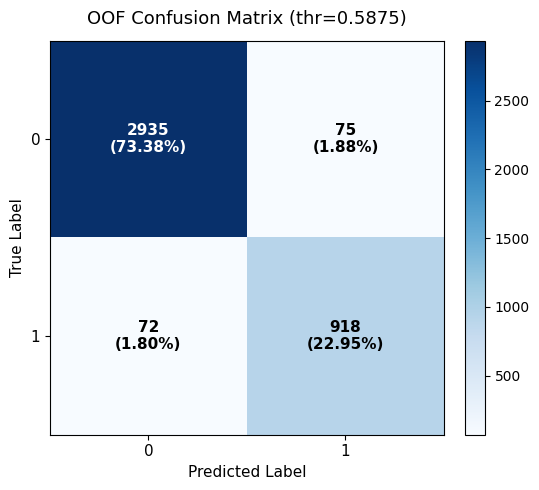


--------------------------------------------------------------------------------
OOF CALIBRATION INPUT PREVIEW (use for calibration / Platt / Isotonic)
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.002107
      0       0.028402
      0       0.002205
      1       0.565554
      0       0.016518
      1       0.972659
      0       0.019953
      0       0.002985
      0       0.003991
      0       0.031718

Shape: (4000, 2)


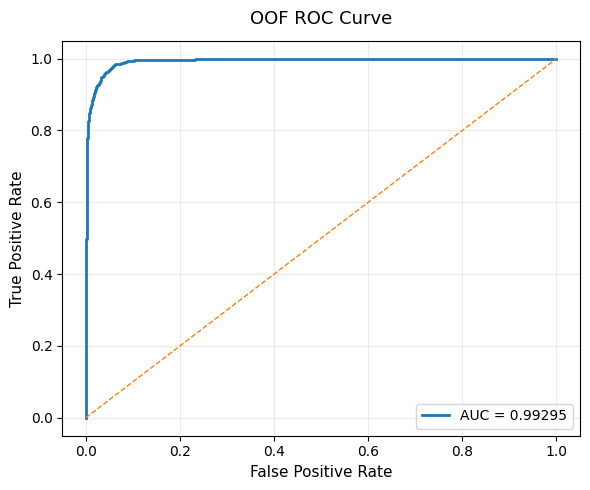


--------------------------------------------------------------------------------
OOF ROC ARRAYS PREVIEW
--------------------------------------------------------------------------------
     fpr      tpr  threshold
0.000000 0.000000        inf
0.000000 0.001010   0.982928
0.000000 0.069697   0.981723
0.000000 0.071717   0.981720
0.000000 0.408081   0.962993
0.000332 0.408081   0.962976
0.000332 0.431313   0.956988
0.000664 0.431313   0.956848
0.000664 0.440404   0.953658
0.000997 0.440404   0.953637

Shape: (220, 3)

--------------------------------------------------------------------------------
FINAL VALIDATION CALIBRATION INPUT PREVIEW (good for Platt / Isotonic)
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.000521
      0       0.013982
      0       0.000583
      1       0.990231
      0       0.003271
      1       0.993367
      1       0.982730
      0       0.000656
      0       0.000628
      0       

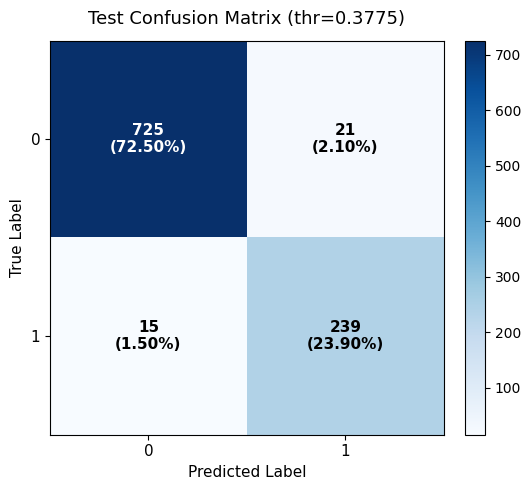


--------------------------------------------------------------------------------
TEST CALIBRATION INPUT PREVIEW
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.000418
      0       0.003290
      1       0.992797
      0       0.098863
      0       0.000859
      0       0.000689
      1       0.976915
      0       0.000490
      0       0.000389
      0       0.001707

Shape: (1000, 2)


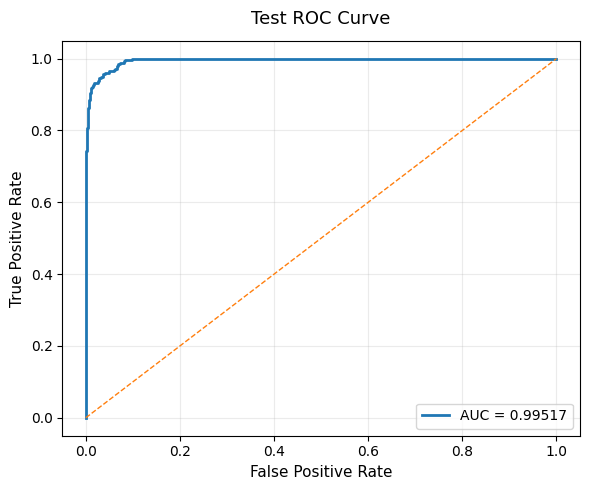


--------------------------------------------------------------------------------
TEST ROC ARRAYS PREVIEW
--------------------------------------------------------------------------------
     fpr      tpr  threshold
0.000000 0.000000        inf
0.000000 0.003937   0.994370
0.000000 0.708661   0.972542
0.001340 0.708661   0.971698
0.001340 0.744094   0.958456
0.002681 0.744094   0.958416
0.002681 0.807087   0.934342
0.004021 0.807087   0.933563
0.004021 0.858268   0.875476
0.005362 0.858268   0.869333

Shape: (58, 3)

READY VARIABLES IN MEMORY
                                     Use            Variable Name   Shape
                         OOF true labels   y_true_oof_calibration (4000,)
             OOF probabilities (class 1)   y_prob_oof_calibration (4000,)
            Final validation true labels y_true_valid_calibration  (400,)
Final validation probabilities (class 1) y_prob_valid_calibration  (400,)
                 Final validation logits logits_valid_temperature  (400,)
       

In [ ]:
import os
import json
import time
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    matthews_corrcoef,
    confusion_matrix,
    balanced_accuracy_score,
    brier_score_loss,
    roc_curve,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

TRAIN_PATH = "/content/train_fs_selected.csv"
TEST_PATH  = "/content/test_fs_selected.csv"
TARGET_COLUMN = "lung_cancer_risk"
ID_COLUMNS = []
DROP_COLUMNS = []

OUTPUT_DIR = "/content/fast_nested_tabsymformer_fast_f1fix"
SAVE_OUTPUTS = False
SHOW_PLOTS = False

SEED = 42

OUTER_FOLDS = 5
INNER_FOLDS = 2

N_TRIALS = 3
MAX_EPOCHS_INNER = 6
MAX_EPOCHS_OUTER = 10
MAX_EPOCHS_FINAL = 12

PATIENCE_INNER = 2
PATIENCE_OUTER = 3
PATIENCE_FINAL = 3

OUTER_DEV_VALID_SIZE = 0.12
FINAL_VALID_SIZE = 0.10

USE_AMP = True
NUM_WORKERS = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

THRESHOLD_GRID = np.linspace(0.16, 0.60, 177)
ACC_DROP_TOL = 0.0015

MIN_DYNAMIC_PRECISION = 0.970
PRECISION_RELAX = 0.012

USE_MILD_POS_WEIGHT = True
POS_WEIGHT_POWER = 0.35
POS_WEIGHT_MAX = 1.25

HP_ACC_TOL = 0.0015

FINAL_ENSEMBLE_SEEDS = [42]

SEARCH_CANDIDATES = [
    {"embed_dim": 128, "num_heads": 4, "depth": 2, "ff_mult": 2.0, "dropout": 0.08, "token_dropout": 0.01, "lr": 1.0e-3, "weight_decay": 1e-5, "batch_size": 2048},
    {"embed_dim": 160, "num_heads": 4, "depth": 2, "ff_mult": 2.0, "dropout": 0.10, "token_dropout": 0.02, "lr": 8.0e-4, "weight_decay": 1e-5, "batch_size": 2048},
    {"embed_dim": 192, "num_heads": 4, "depth": 3, "ff_mult": 2.0, "dropout": 0.10, "token_dropout": 0.02, "lr": 8.0e-4, "weight_decay": 1e-5, "batch_size": 1024},
]

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

def now():
    return time.strftime("%H:%M:%S")

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def safe_read_csv(path):
    if path is None or str(path).strip() == "":
        return None
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)

def to_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def clip_probs(prob, eps=1e-7):
    return np.clip(np.asarray(prob, dtype=np.float64), eps, 1 - eps)

def safe_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, prob))

def safe_pr_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, prob))

def metric_score_binary(y_true, y_pred, metric_name="accuracy"):
    if metric_name == "accuracy":
        return accuracy_score(y_true, y_pred)
    if metric_name == "f1":
        return f1_score(y_true, y_pred, zero_division=0)
    if metric_name == "mcc":
        return matthews_corrcoef(y_true, y_pred)
    if metric_name == "balanced_accuracy":
        return balanced_accuracy_score(y_true, y_pred)
    raise ValueError(f"Unsupported metric: {metric_name}")

def _threshold_table(y_true, prob, grid):
    rows = []
    prob = clip_probs(prob)

    for t in grid:
        pred = (prob >= t).astype(int)
        acc = accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)
        f1v = f1_score(y_true, pred, zero_division=0)
        mcc = matthews_corrcoef(y_true, pred)

        rows.append({
            "threshold": float(t),
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1v),
            "mcc": float(mcc),
        })

    return pd.DataFrame(rows)

def _pick_best_threshold_from_df(df_thr: pd.DataFrame) -> float:
    """
    Tie-break order after accuracy safety:
    1) max F1
    2) max Recall
    3) max Accuracy
    4) max MCC
    5) max Precision
    6) lower threshold
    """
    if df_thr.empty:
        return 0.50

    df_thr = df_thr.sort_values(
        by=["f1", "recall", "accuracy", "mcc", "precision", "threshold"],
        ascending=[False, False, False, False, False, True]
    ).reset_index(drop=True)

    return float(df_thr.loc[0, "threshold"])

def tune_threshold_constrained(
    y_true,
    prob,
    grid=None,
    acc_drop_tol=0.0015,
    min_dynamic_precision=0.970,
    precision_relax=0.012,
):
    """
    Accuracy-safe threshold tuning with dynamic precision protection.

    Steps:
    1) compute full threshold table
    2) keep thresholds within best-accuracy tolerance
    3) estimate precision at the best-accuracy operating region
    4) allow a small precision relaxation from that reference
    5) inside that safe region, maximize F1 -> Recall -> Accuracy -> MCC
    """
    if grid is None:
        grid = np.linspace(0.16, 0.60, 177)

    prob = clip_probs(prob)
    thr_df = _threshold_table(y_true, prob, grid)

    best_acc = float(thr_df["accuracy"].max())
    acc_floor = best_acc - float(acc_drop_tol)

    safe_df = thr_df.loc[thr_df["accuracy"] >= acc_floor].copy()
    if safe_df.empty:
        safe_df = thr_df.copy()

    best_acc_df = thr_df.loc[thr_df["accuracy"] >= best_acc - 1e-12].copy()
    best_acc_df = best_acc_df.sort_values(
        by=["f1", "recall", "mcc", "precision", "threshold"],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

    ref_precision = float(best_acc_df.loc[0, "precision"])
    precision_floor = max(float(min_dynamic_precision), ref_precision - float(precision_relax))

    guarded_df = safe_df.loc[safe_df["precision"] >= precision_floor].copy()
    if guarded_df.empty:
        guarded_df = safe_df.copy()

    return _pick_best_threshold_from_df(guarded_df)

def choose_best_hp_info(info_list, acc_tol=0.0015):
    """
    Keep only HPs within best accuracy tolerance,
    then choose the one with better F1 / recall / MCC.
    """
    rows = []
    for i, info in enumerate(info_list):
        m = info["metrics"]
        rows.append({
            "idx": i,
            "accuracy": float(m["accuracy"]),
            "f1": float(m["f1"]),
            "recall": float(m["recall"]),
            "precision": float(m["precision"]),
            "mcc": float(m["mcc"]),
            "logloss": float(m["logloss"]),
        })

    df = pd.DataFrame(rows)
    best_acc = float(df["accuracy"].max())

    keep = df.loc[df["accuracy"] >= best_acc - float(acc_tol)].copy()
    keep = keep.sort_values(
        by=["f1", "recall", "mcc", "precision", "accuracy", "logloss"],
        ascending=[False, False, False, False, False, True]
    ).reset_index(drop=True)

    return info_list[int(keep.loc[0, "idx"])]

def compute_metrics(y_true, prob, threshold=0.5):
    prob = clip_probs(prob)
    pred = (prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "specificity": float(specificity),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "roc_auc": safe_auc(y_true, prob),
        "pr_auc": safe_pr_auc(y_true, prob),
        "logloss": float(log_loss(y_true, prob, labels=[0, 1])),
        "brier": float(brier_score_loss(y_true, prob)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def plot_conf_matrix(cm, title="Confusion Matrix", class_names=("0", "1")):
    cm = np.asarray(cm)
    total = cm.sum()
    pct = (cm / total * 100.0) if total > 0 else np.zeros_like(cm, dtype=float)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)

    thresh = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f"{cm[i, j]}\n({pct[i, j]:.2f}%)",
                ha="center", va="center",
                fontsize=11,
                fontweight="bold",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()

def plot_roc_curve_from_prob(y_true, prob, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        print(f"{title}: skipped because only one class is present.")
        return None, None, None, np.nan

    fpr, tpr, thresholds = roc_curve(y_true, prob)
    auc_val = roc_auc_score(y_true, prob)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.5f}")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    ax.legend(loc="lower right")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return fpr, tpr, thresholds, auc_val

def print_preview_table(df, title, n=10):
    print("\n" + "-" * 80)
    print(title)
    print("-" * 80)
    print(df.head(n).to_string(index=False))
    print(f"\nShape: {df.shape}")

def hp_to_str(hp):
    return (
        f"embed={hp['embed_dim']} | heads={hp['num_heads']} | depth={hp['depth']} | "
        f"ff_mult={hp['ff_mult']} | drop={hp['dropout']} | tok_drop={hp['token_dropout']} | "
        f"lr={hp['lr']} | wd={hp['weight_decay']} | bs={hp['batch_size']}"
    )

class FoldPreprocessor:
    def __init__(self):
        self.imputer = SimpleImputer(strategy="median")
        self.scaler = StandardScaler()

    def fit(self, X_df):
        X_num = to_numeric_df(X_df)
        X_imp = self.imputer.fit_transform(X_num)
        self.scaler.fit(X_imp)
        return self

    def transform(self, X_df):
        X_num = to_numeric_df(X_df)
        X_imp = self.imputer.transform(X_num)
        X_scaled = self.scaler.transform(X_imp)
        X_scaled = np.clip(X_scaled, -8.0, 8.0).astype(np.float32)
        return X_scaled

    def fit_transform(self, X_df):
        self.fit(X_df)
        return self.transform(X_df)

class NumericFeatureTokenizer(nn.Module):
    """
    Each scalar feature becomes a learnable token.
    token_j = x_j * W_j + B_j + E_j
    """
    def __init__(self, n_features, embed_dim, token_dropout=0.01):
        super().__init__()
        self.n_features = n_features
        self.embed_dim = embed_dim
        self.token_dropout = float(token_dropout)

        self.weight = nn.Parameter(torch.randn(n_features, embed_dim) * 0.02)
        self.bias = nn.Parameter(torch.zeros(n_features, embed_dim))
        self.feature_embed = nn.Parameter(torch.randn(n_features, embed_dim) * 0.02)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        tokens = x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0) + self.feature_embed.unsqueeze(0)

        if self.training and self.token_dropout > 0:
            keep = (torch.rand((x.size(0), x.size(1), 1), device=x.device) > self.token_dropout).float()
            tokens = tokens * keep

        tokens = self.norm(tokens)
        return tokens

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_mult=2.0, dropout=0.10):
        super().__init__()
        ff_dim = int(embed_dim * ff_mult)

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.drop1 = nn.Dropout(dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff1 = nn.Linear(embed_dim, ff_dim * 2)
        self.ff2 = nn.Linear(ff_dim, embed_dim)
        self.drop2 = nn.Dropout(dropout)

        self.gate = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        y = self.norm1(x)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x = x + self.drop1(attn_out)

        y = self.norm2(x)
        a, b = self.ff1(y).chunk(2, dim=-1)
        y = a * F.gelu(b)
        y = self.ff2(self.drop2(y))

        gate = self.gate(x)
        x = x + gate * y
        return x

class TabFGT(nn.Module):
    """
    Faster custom transformer for encoded numeric tabular data.
    Lighter head: CLS + mean pooling only.
    """
    def __init__(
        self,
        input_dim,
        embed_dim=160,
        num_heads=4,
        depth=2,
        ff_mult=2.0,
        dropout=0.10,
        token_dropout=0.01,
    ):
        super().__init__()

        self.tokenizer = NumericFeatureTokenizer(
            n_features=input_dim,
            embed_dim=embed_dim,
            token_dropout=token_dropout
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.cls_bias = nn.Parameter(torch.zeros(1, 1, embed_dim))

        self.blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ff_mult=ff_mult,
                dropout=dropout
            )
            for _ in range(depth)
        ])

        self.final_norm = nn.LayerNorm(embed_dim)

        head_dim = embed_dim * 2
        hidden2 = max(embed_dim, 128)

        self.head = nn.Sequential(
            nn.LayerNorm(head_dim),
            nn.Linear(head_dim, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, hidden2 // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2 // 2, 1),
        )

    def forward(self, x):
        tok = self.tokenizer(x)
        cls = self.cls_token.expand(x.size(0), -1, -1) + self.cls_bias
        tok = torch.cat([cls, tok], dim=1)

        for block in self.blocks:
            tok = block(tok)

        tok = self.final_norm(tok)

        cls_tok = tok[:, 0]
        feat_tok = tok[:, 1:]
        mean_tok = feat_tok.mean(dim=1)

        rep = torch.cat([cls_tok, mean_tok], dim=1)
        out = self.head(rep).squeeze(1)
        return out

def make_loader(X, y=None, batch_size=1024, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    if y is None:
        ds = TensorDataset(X_t)
    else:
        y_t = torch.tensor(y, dtype=torch.float32)
        ds = TensorDataset(X_t, y_t)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )

@torch.no_grad()
def predict_proba(model, X, batch_size=1024):
    model.eval()
    loader = make_loader(X, y=None, batch_size=batch_size, shuffle=False)
    probs = []

    for batch in loader:
        xb = batch[0].to(DEVICE, non_blocking=True)
        logits = model(xb)
        p = torch.sigmoid(logits).detach().cpu().numpy()
        probs.append(p)

    return np.concatenate(probs).astype(np.float64)

@torch.no_grad()
def predict_logits(model, X, batch_size=1024):
    model.eval()
    loader = make_loader(X, y=None, batch_size=batch_size, shuffle=False)
    logits_all = []

    for batch in loader:
        xb = batch[0].to(DEVICE, non_blocking=True)
        logits = model(xb).detach().cpu().numpy()
        logits_all.append(logits)

    return np.concatenate(logits_all).astype(np.float64)

def train_one_model(
    X_train, y_train,
    X_valid, y_valid,
    hp,
    max_epochs=12,
    patience=3,
    seed=42
):
    set_seed(seed)

    model = TabFGT(
        input_dim=X_train.shape[1],
        embed_dim=hp["embed_dim"],
        num_heads=hp["num_heads"],
        depth=hp["depth"],
        ff_mult=hp["ff_mult"],
        dropout=hp["dropout"],
        token_dropout=hp["token_dropout"],
    ).to(DEVICE)

    train_loader = make_loader(X_train, y_train, batch_size=hp["batch_size"], shuffle=True)
    valid_loader = make_loader(X_valid, y_valid, batch_size=max(1024, hp["batch_size"]), shuffle=False)

    pos_count = max(float(np.sum(np.asarray(y_train) == 1)), 1.0)
    neg_count = max(float(np.sum(np.asarray(y_train) == 0)), 1.0)

    if USE_MILD_POS_WEIGHT:
        pos_weight_value = float(np.clip((neg_count / pos_count) ** POS_WEIGHT_POWER, 1.0, POS_WEIGHT_MAX))
    else:
        pos_weight_value = 1.0

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"]
    )

    steps_per_epoch = max(1, len(train_loader))
    total_steps = max(1, max_epochs * steps_per_epoch)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=hp["lr"],
        total_steps=total_steps,
        pct_start=0.20,
        div_factor=8.0,
        final_div_factor=80.0,
    )

    use_amp_now = bool(USE_AMP and DEVICE.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp_now)

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = np.inf
    best_epoch = 0
    bad_epochs = 0
    min_delta = 5e-4

    for epoch in range(1, max_epochs + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp_now):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

        model.eval()
        val_probs = []
        for xb, _ in valid_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp_now):
                logits = model(xb)
                p = torch.sigmoid(logits)
            val_probs.append(p.detach().cpu().numpy())

        val_probs = np.concatenate(val_probs).astype(np.float64)
        val_loss = log_loss(y_valid, clip_probs(val_probs), labels=[0, 1])

        if val_loss < best_val_loss - min_delta:
            best_val_loss = float(val_loss)
            best_epoch = int(epoch)
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    model.load_state_dict(best_state)
    return model, best_epoch, best_val_loss, pos_weight_value

def inner_cv_score(X_df, y, hp, seed=42):
    skf = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=seed)
    oof_prob = np.zeros(len(y), dtype=np.float64)
    pos_weights_used = []

    for inner_fold, (tr_idx, va_idx) in enumerate(skf.split(X_df, y), start=1):
        X_tr_df = X_df.iloc[tr_idx].reset_index(drop=True)
        X_va_df = X_df.iloc[va_idx].reset_index(drop=True)
        y_tr = y[tr_idx]
        y_va = y[va_idx]

        prep = FoldPreprocessor()
        X_tr = prep.fit_transform(X_tr_df)
        X_va = prep.transform(X_va_df)

        model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
            X_tr, y_tr,
            X_va, y_va,
            hp=hp,
            max_epochs=MAX_EPOCHS_INNER,
            patience=PATIENCE_INNER,
            seed=seed + inner_fold * 77
        )
        pos_weights_used.append(float(pos_weight_value))

        prob = predict_proba(model, X_va, batch_size=max(1024, hp["batch_size"]))
        oof_prob[va_idx] = prob

    best_thr = tune_threshold_constrained(
        y_true=y,
        prob=oof_prob,
        grid=THRESHOLD_GRID,
        acc_drop_tol=ACC_DROP_TOL,
        min_dynamic_precision=MIN_DYNAMIC_PRECISION,
        precision_relax=PRECISION_RELAX,
    )
    metrics = compute_metrics(y, oof_prob, threshold=best_thr)

    return {
        "hp": hp,
        "threshold": best_thr,
        "metrics": metrics,
        "score": metrics["accuracy"],
        "mean_pos_weight": float(np.mean(pos_weights_used)) if len(pos_weights_used) > 0 else 1.0,
    }

set_seed(SEED)
ensure_dir(OUTPUT_DIR)

print("\n" + "=" * 80)
print(f"[{now()}] LOADING DATA")
print("=" * 80)

train_df = safe_read_csv(TRAIN_PATH)
test_df = safe_read_csv(TEST_PATH)

if TARGET_COLUMN not in train_df.columns:
    raise ValueError(f"Target column '{TARGET_COLUMN}' not found.")

drop_train = list(set(ID_COLUMNS + DROP_COLUMNS + [TARGET_COLUMN]))
X_train_df = train_df.drop(columns=[c for c in drop_train if c in train_df.columns], errors="ignore").copy()
y_raw = train_df[TARGET_COLUMN].copy()

le = LabelEncoder()
y = le.fit_transform(y_raw)

if len(le.classes_) != 2:
    raise ValueError(f"Binary classification only. Found classes: {list(le.classes_)}")

class_names = [str(x) for x in le.classes_]

print(f"Train shape   : {train_df.shape}")
print(f"Feature shape : {X_train_df.shape}")
print(f"Classes       : {class_names}")
print(f"Device        : {DEVICE}")

if test_df is not None:
    drop_test = list(set(ID_COLUMNS + DROP_COLUMNS + [TARGET_COLUMN]))
    X_test_df = test_df.drop(columns=[c for c in drop_test if c in test_df.columns], errors="ignore").copy()

    if TARGET_COLUMN in test_df.columns:
        y_test = le.transform(test_df[TARGET_COLUMN])
        has_test_labels = True
    else:
        y_test = None
        has_test_labels = False

    print(f"Test shape    : {test_df.shape}")
    print(f"Test labels   : {'present' if has_test_labels else 'absent'}")
else:
    X_test_df = None
    y_test = None
    has_test_labels = False

print("\n" + "=" * 80)
print(f"[{now()}] STARTING NESTED CV ({OUTER_FOLDS} OUTER x {INNER_FOLDS} INNER)")
print("=" * 80)

outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)

oof_prob = np.zeros(len(y), dtype=np.float64)
outer_rows = []
outer_thresholds = []
outer_best_hps = []
outer_test_probs = []

candidate_pool = SEARCH_CANDIDATES[:N_TRIALS]

for outer_fold, (dev_idx, hold_idx) in enumerate(outer_cv.split(X_train_df, y), start=1):
    print(f"\n[{now()}] OUTER FOLD {outer_fold}/{OUTER_FOLDS}")

    X_dev_df = X_train_df.iloc[dev_idx].reset_index(drop=True)
    y_dev = y[dev_idx]

    X_hold_df = X_train_df.iloc[hold_idx].reset_index(drop=True)
    y_hold = y[hold_idx]

    fold_infos = []

    for trial_id, hp in enumerate(candidate_pool, start=1):
        info = inner_cv_score(
            X_df=X_dev_df,
            y=y_dev,
            hp=hp,
            seed=SEED + outer_fold * 100 + trial_id
        )
        fold_infos.append(info)

        m = info["metrics"]
        print(
            f"  trial {trial_id}/{len(candidate_pool)} | "
            f"acc={m['accuracy']:.5f} | f1={m['f1']:.5f} | rec={m['recall']:.5f} | "
            f"prec={m['precision']:.5f} | mcc={m['mcc']:.5f} | "
            f"auc={m['roc_auc']:.5f} | logloss={m['logloss']:.5f} | "
            f"thr={info['threshold']:.3f} | pos_w={info['mean_pos_weight']:.3f}"
        )

    best_info = choose_best_hp_info(fold_infos, acc_tol=HP_ACC_TOL)
    best_hp = best_info["hp"]
    best_thr = best_info["threshold"]

    outer_best_hps.append(best_hp)
    outer_thresholds.append(best_thr)

    print(f"  best hp  : {hp_to_str(best_hp)}")
    print(f"  best thr : {best_thr:.3f}")

    X_tr_df, X_va_df, y_tr, y_va = train_test_split(
        X_dev_df, y_dev,
        test_size=OUTER_DEV_VALID_SIZE,
        random_state=SEED + outer_fold,
        stratify=y_dev
    )

    prep = FoldPreprocessor()
    X_tr = prep.fit_transform(X_tr_df)
    X_va = prep.transform(X_va_df)
    X_hold = prep.transform(X_hold_df)

    model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
        X_tr, y_tr,
        X_va, y_va,
        hp=best_hp,
        max_epochs=MAX_EPOCHS_OUTER,
        patience=PATIENCE_OUTER,
        seed=SEED + outer_fold * 1000
    )

    hold_prob = predict_proba(model, X_hold, batch_size=max(1024, best_hp["batch_size"]))
    oof_prob[hold_idx] = hold_prob

    fold_metrics = compute_metrics(y_hold, hold_prob, threshold=best_thr)
    fold_metrics["outer_fold"] = outer_fold
    fold_metrics["best_epoch"] = best_epoch
    fold_metrics["best_val_loss"] = best_val_loss
    fold_metrics["pos_weight"] = float(pos_weight_value)
    outer_rows.append(fold_metrics)

    print(
        f"  fold result | acc={fold_metrics['accuracy']:.5f} | "
        f"prec={fold_metrics['precision']:.5f} | rec={fold_metrics['recall']:.5f} | "
        f"spec={fold_metrics['specificity']:.5f} | f1={fold_metrics['f1']:.5f} | "
        f"mcc={fold_metrics['mcc']:.5f} | auc={fold_metrics['roc_auc']:.5f} | "
        f"logloss={fold_metrics['logloss']:.5f}"
    )

    if X_test_df is not None:
        X_test_proc = prep.transform(X_test_df)
        test_prob_fold = predict_proba(model, X_test_proc, batch_size=max(1024, best_hp["batch_size"]))
        outer_test_probs.append(test_prob_fold)

outer_df = pd.DataFrame(outer_rows)

global_threshold = tune_threshold_constrained(
    y_true=y,
    prob=oof_prob,
    grid=THRESHOLD_GRID,
    acc_drop_tol=ACC_DROP_TOL,
    min_dynamic_precision=MIN_DYNAMIC_PRECISION,
    precision_relax=PRECISION_RELAX,
)

oof_metrics = compute_metrics(y, oof_prob, threshold=global_threshold)

print("\n" + "=" * 80)
print(f"[{now()}] NESTED CV SUMMARY")
print("=" * 80)
print(outer_df[
    ["outer_fold", "accuracy", "precision", "recall", "specificity", "f1",
     "mcc", "balanced_accuracy", "roc_auc", "pr_auc", "logloss", "threshold", "pos_weight"]
].round(5).to_string(index=False))

print("\nOOF SUMMARY")
print(pd.DataFrame([oof_metrics]).round(5).to_string(index=False))

if SHOW_PLOTS:
    cm_oof = confusion_matrix(y, (oof_prob >= global_threshold).astype(int), labels=[0, 1])
    plot_conf_matrix(
        cm_oof,
        title=f"OOF Confusion Matrix (thr={global_threshold:.3f})",
        class_names=class_names
    )

hp_keys = [tuple(sorted(hp.items())) for hp in outer_best_hps]
hp_counter = Counter(hp_keys)
max_count = max(hp_counter.values())
candidates = [dict(k) for k, v in hp_counter.items() if v == max_count]

if len(candidates) == 1:
    final_best_hp = candidates[0]
else:
    rows = []
    for cand in candidates:
        mask = [hp == cand for hp in outer_best_hps]
        rows.append({
            "hp": cand,
            "mean_acc": float(outer_df.loc[mask, "accuracy"].mean()),
            "mean_f1": float(outer_df.loc[mask, "f1"].mean()),
            "mean_recall": float(outer_df.loc[mask, "recall"].mean()),
            "mean_mcc": float(outer_df.loc[mask, "mcc"].mean()),
            "mean_logloss": float(outer_df.loc[mask, "logloss"].mean()),
        })

    hp_df = pd.DataFrame(rows)
    best_mean_acc = float(hp_df["mean_acc"].max())

    keep = hp_df.loc[hp_df["mean_acc"] >= best_mean_acc - HP_ACC_TOL].copy()
    keep = keep.sort_values(
        by=["mean_f1", "mean_recall", "mean_mcc", "mean_acc", "mean_logloss"],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

    final_best_hp = keep.iloc[0]["hp"]

print("\n" + "=" * 80)
print(f"[{now()}] FINAL CHOSEN SETTINGS")
print("=" * 80)
print("Final best hyperparameters:")
print(json.dumps(final_best_hp, indent=2))
print(f"OOF-derived threshold: {global_threshold:.4f}")

final_models = []
final_preps = []
final_valid_probs = []
final_valid_targets = []
final_valid_logits = []

for i, seed_i in enumerate(FINAL_ENSEMBLE_SEEDS, start=1):
    print(f"\n[{now()}] FINAL MODEL {i}/{len(FINAL_ENSEMBLE_SEEDS)}")

    X_tr_df, X_va_df, y_tr, y_va = train_test_split(
        X_train_df, y,
        test_size=FINAL_VALID_SIZE,
        random_state=seed_i,
        stratify=y
    )

    prep = FoldPreprocessor()
    X_tr = prep.fit_transform(X_tr_df)
    X_va = prep.transform(X_va_df)

    model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
        X_tr, y_tr,
        X_va, y_va,
        hp=final_best_hp,
        max_epochs=MAX_EPOCHS_FINAL,
        patience=PATIENCE_FINAL,
        seed=seed_i
    )

    final_models.append(model)
    final_preps.append(prep)

    va_prob = predict_proba(model, X_va, batch_size=max(1024, final_best_hp["batch_size"]))
    va_logit = predict_logits(model, X_va, batch_size=max(1024, final_best_hp["batch_size"]))

    final_valid_probs.append(va_prob)
    final_valid_targets.append(np.asarray(y_va, dtype=int))
    final_valid_logits.append(va_logit)

    print(
        f"  best_epoch={best_epoch} | best_val_loss={best_val_loss:.5f} | "
        f"pos_weight={pos_weight_value:.3f}"
    )

def predict_ensemble(models, preps, X_df, batch_size=1024):
    probs = []
    for model, prep in zip(models, preps):
        X_proc = prep.transform(X_df)
        p = predict_proba(model, X_proc, batch_size=batch_size)
        probs.append(p)
    return np.mean(np.vstack(probs), axis=0)

final_valid_prob = None
final_valid_y = None
final_valid_logit = None

if len(final_valid_probs) > 0:
    final_valid_prob = np.concatenate(final_valid_probs).astype(np.float64)
    final_valid_y = np.concatenate(final_valid_targets).astype(int)
    final_valid_logit = np.concatenate(final_valid_logits).astype(np.float64)

    final_threshold = tune_threshold_constrained(
        y_true=final_valid_y,
        prob=final_valid_prob,
        grid=THRESHOLD_GRID,
        acc_drop_tol=ACC_DROP_TOL,
        min_dynamic_precision=MIN_DYNAMIC_PRECISION,
        precision_relax=PRECISION_RELAX,
    )
else:
    final_threshold = global_threshold

print(f"\n[{now()}] FINAL DEPLOYMENT THRESHOLD: {final_threshold:.4f}")

if X_test_df is not None:
    print("\n" + "=" * 80)
    print(f"[{now()}] TEST RESULT")
    print("=" * 80)

    final_test_prob = predict_ensemble(
        final_models,
        final_preps,
        X_test_df,
        batch_size=max(1024, final_best_hp["batch_size"])
    )
    final_test_pred = (final_test_prob >= final_threshold).astype(int)

    if has_test_labels:
        test_metrics = compute_metrics(y_test, final_test_prob, threshold=final_threshold)
        print(pd.DataFrame([test_metrics]).round(5).to_string(index=False))

        if SHOW_PLOTS:
            cm_test = confusion_matrix(y_test, final_test_pred, labels=[0, 1])
            plot_conf_matrix(
                cm_test,
                title=f"Test Confusion Matrix (thr={final_threshold:.3f})",
                class_names=class_names
            )

        if len(outer_test_probs) > 0:
            nested_test_prob = np.mean(np.vstack(outer_test_probs), axis=0)
            nested_test_metrics = compute_metrics(y_test, nested_test_prob, threshold=global_threshold)

            print("\nOuter-fold test ensemble reference:")
            print(pd.DataFrame([nested_test_metrics]).round(5).to_string(index=False))
    else:
        test_metrics = None
        print("Test labels not available.")
else:
    final_test_prob = None
    final_test_pred = None
    test_metrics = None

if SAVE_OUTPUTS:
    ensure_dir(OUTPUT_DIR)

    outer_df.to_csv(os.path.join(OUTPUT_DIR, "outer_fold_results.csv"), index=False)
    pd.DataFrame([oof_metrics]).to_csv(os.path.join(OUTPUT_DIR, "oof_metrics.csv"), index=False)

    with open(os.path.join(OUTPUT_DIR, "final_best_hyperparameters.json"), "w") as f:
        json.dump(
            {
                "best_hyperparameters": final_best_hp,
                "oof_global_threshold": global_threshold,
                "final_threshold": final_threshold,
                "classes": class_names,
                "device": str(DEVICE),
                "model_name": "TabFGT-Fast-F1Fix",
                "threshold_grid_start": float(THRESHOLD_GRID[0]),
                "threshold_grid_end": float(THRESHOLD_GRID[-1]),
                "acc_drop_tol": float(ACC_DROP_TOL),
                "min_dynamic_precision": float(MIN_DYNAMIC_PRECISION),
                "precision_relax": float(PRECISION_RELAX),
                "use_mild_pos_weight": bool(USE_MILD_POS_WEIGHT),
                "pos_weight_power": float(POS_WEIGHT_POWER),
                "pos_weight_max": float(POS_WEIGHT_MAX),
                "hp_acc_tol": float(HP_ACC_TOL),
            },
            f,
            indent=2
        )

    oof_pred = (oof_prob >= global_threshold).astype(int)
    oof_df = pd.DataFrame({
        "true_label_encoded": y,
        "true_label": [class_names[i] for i in y],
        "prob_positive": oof_prob,
        "pred_label_encoded": oof_pred,
        "pred_label": [class_names[i] for i in oof_pred],
    })
    if ID_COLUMNS:
        ids = [c for c in ID_COLUMNS if c in train_df.columns]
        if len(ids) > 0:
            oof_df = pd.concat([train_df[ids].reset_index(drop=True), oof_df], axis=1)
    oof_df.to_csv(os.path.join(OUTPUT_DIR, "oof_predictions.csv"), index=False)

    if X_test_df is not None:
        test_out = pd.DataFrame({
            "prob_positive": final_test_prob,
            "pred_label_encoded": final_test_pred,
            "pred_label": [class_names[i] for i in final_test_pred],
        })
        if ID_COLUMNS:
            ids = [c for c in ID_COLUMNS if c in test_df.columns]
            if len(ids) > 0:
                test_out = pd.concat([test_df[ids].reset_index(drop=True), test_out], axis=1)
        test_out.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)

    print("\nSaved outputs in:", OUTPUT_DIR)

print("\n" + "=" * 80)
print(f"[{now()}] FINAL REPORT")
print("=" * 80)
print(f"Model         : TabFGT-Fast-F1Fix")
print(f"Final HP      : {hp_to_str(final_best_hp)}")
print(f"OOF thr       : {global_threshold:.4f}")
print(f"Final thr     : {final_threshold:.4f}")
print(f"OOF accuracy  : {oof_metrics['accuracy']:.5f}")
print(f"OOF precision : {oof_metrics['precision']:.5f}")
print(f"OOF recall    : {oof_metrics['recall']:.5f}")
print(f"OOF spec      : {oof_metrics['specificity']:.5f}")
print(f"OOF f1        : {oof_metrics['f1']:.5f}")
print(f"OOF mcc       : {oof_metrics['mcc']:.5f}")
print(f"OOF roc_auc   : {oof_metrics['roc_auc']:.5f}")
print(f"OOF logloss   : {oof_metrics['logloss']:.5f}")

if test_metrics is not None:
    print("\nTEST headline metrics")
    print(f"Test accuracy : {test_metrics['accuracy']:.5f}")
    print(f"Test precision: {test_metrics['precision']:.5f}")
    print(f"Test recall   : {test_metrics['recall']:.5f}")
    print(f"Test spec     : {test_metrics['specificity']:.5f}")
    print(f"Test f1       : {test_metrics['f1']:.5f}")
    print(f"Test mcc      : {test_metrics['mcc']:.5f}")
    print(f"Test roc_auc  : {test_metrics['roc_auc']:.5f}")
    print(f"Test logloss  : {test_metrics['logloss']:.5f}")

print("\n" + "=" * 80)
print(f"[{now()}] DISPLAY OUTPUTS")
print("=" * 80)

y_true_oof_calibration = np.asarray(y, dtype=int)
y_prob_oof_calibration = np.asarray(oof_prob, dtype=np.float64)
y_pred_oof_display = (y_prob_oof_calibration >= global_threshold).astype(int)

cm_oof_display = confusion_matrix(y_true_oof_calibration, y_pred_oof_display, labels=[0, 1])

print("\nOOF CONFUSION MATRIX")
print(pd.DataFrame(
    cm_oof_display,
    index=[f"True_{class_names[0]}", f"True_{class_names[1]}"],
    columns=[f"Pred_{class_names[0]}", f"Pred_{class_names[1]}"]
).to_string())

plot_conf_matrix(
    cm_oof_display,
    title=f"OOF Confusion Matrix (thr={global_threshold:.4f})",
    class_names=class_names
)

oof_calibration_df = pd.DataFrame({
    "y_true": y_true_oof_calibration,
    "y_prob_class1": y_prob_oof_calibration
})

print_preview_table(
    oof_calibration_df,
    "OOF CALIBRATION INPUT PREVIEW (use for calibration / Platt / Isotonic)",
    n=10
)

oof_roc_fpr, oof_roc_tpr, oof_roc_thresholds, oof_roc_auc = plot_roc_curve_from_prob(
    y_true_oof_calibration,
    y_prob_oof_calibration,
    title="OOF ROC Curve"
)

if oof_roc_fpr is not None:
    oof_roc_df = pd.DataFrame({
        "fpr": oof_roc_fpr,
        "tpr": oof_roc_tpr,
        "threshold": oof_roc_thresholds
    })
    print_preview_table(
        oof_roc_df,
        "OOF ROC ARRAYS PREVIEW",
        n=10
    )

if final_valid_prob is not None and final_valid_y is not None:
    y_true_valid_calibration = np.asarray(final_valid_y, dtype=int)
    y_prob_valid_calibration = np.asarray(final_valid_prob, dtype=np.float64)

    valid_calibration_df = pd.DataFrame({
        "y_true": y_true_valid_calibration,
        "y_prob_class1": y_prob_valid_calibration
    })

    print_preview_table(
        valid_calibration_df,
        "FINAL VALIDATION CALIBRATION INPUT PREVIEW (good for Platt / Isotonic)",
        n=10
    )

    if final_valid_logit is not None:
        logits_valid_temperature = np.asarray(final_valid_logit, dtype=np.float64)

        valid_temperature_df = pd.DataFrame({
            "y_true": y_true_valid_calibration,
            "logit": logits_valid_temperature
        })

        print_preview_table(
            valid_temperature_df,
            "FINAL VALIDATION TEMPERATURE-SCALING INPUT PREVIEW (y_true + logits)",
            n=10
        )
    else:
        logits_valid_temperature = None
else:
    y_true_valid_calibration = None
    y_prob_valid_calibration = None
    logits_valid_temperature = None

if final_test_prob is not None and has_test_labels:
    y_true_test_calibration = np.asarray(y_test, dtype=int)
    y_prob_test_calibration = np.asarray(final_test_prob, dtype=np.float64)
    y_pred_test_display = (y_prob_test_calibration >= final_threshold).astype(int)

    cm_test_display = confusion_matrix(y_true_test_calibration, y_pred_test_display, labels=[0, 1])

    print("\nTEST CONFUSION MATRIX")
    print(pd.DataFrame(
        cm_test_display,
        index=[f"True_{class_names[0]}", f"True_{class_names[1]}"],
        columns=[f"Pred_{class_names[0]}", f"Pred_{class_names[1]}"]
    ).to_string())

    plot_conf_matrix(
        cm_test_display,
        title=f"Test Confusion Matrix (thr={final_threshold:.4f})",
        class_names=class_names
    )

    test_calibration_df = pd.DataFrame({
        "y_true": y_true_test_calibration,
        "y_prob_class1": y_prob_test_calibration
    })

    print_preview_table(
        test_calibration_df,
        "TEST CALIBRATION INPUT PREVIEW",
        n=10
    )

    test_roc_fpr, test_roc_tpr, test_roc_thresholds, test_roc_auc = plot_roc_curve_from_prob(
        y_true_test_calibration,
        y_prob_test_calibration,
        title="Test ROC Curve"
    )

    if test_roc_fpr is not None:
        test_roc_df = pd.DataFrame({
            "fpr": test_roc_fpr,
            "tpr": test_roc_tpr,
            "threshold": test_roc_thresholds
        })
        print_preview_table(
            test_roc_df,
            "TEST ROC ARRAYS PREVIEW",
            n=10
        )
else:
    y_true_test_calibration = None
    y_prob_test_calibration = None
    test_roc_fpr = None
    test_roc_tpr = None
    test_roc_thresholds = None
    test_roc_auc = None

print("\n" + "=" * 80)
print("READY VARIABLES IN MEMORY")
print("=" * 80)

ready_rows = [
    ["OOF true labels", "y_true_oof_calibration", None if y_true_oof_calibration is None else y_true_oof_calibration.shape],
    ["OOF probabilities (class 1)", "y_prob_oof_calibration", None if y_prob_oof_calibration is None else y_prob_oof_calibration.shape],
    ["Final validation true labels", "y_true_valid_calibration", None if y_true_valid_calibration is None else y_true_valid_calibration.shape],
    ["Final validation probabilities (class 1)", "y_prob_valid_calibration", None if y_prob_valid_calibration is None else y_prob_valid_calibration.shape],
    ["Final validation logits", "logits_valid_temperature", None if logits_valid_temperature is None else logits_valid_temperature.shape],
    ["Test true labels", "y_true_test_calibration", None if y_true_test_calibration is None else y_true_test_calibration.shape],
    ["Test probabilities (class 1)", "y_prob_test_calibration", None if y_prob_test_calibration is None else y_prob_test_calibration.shape],
    ["OOF ROC FPR", "oof_roc_fpr", None if oof_roc_fpr is None else oof_roc_fpr.shape],
    ["OOF ROC TPR", "oof_roc_tpr", None if oof_roc_tpr is None else oof_roc_tpr.shape],
    ["OOF ROC thresholds", "oof_roc_thresholds", None if oof_roc_thresholds is None else oof_roc_thresholds.shape],
    ["Test ROC FPR", "test_roc_fpr", None if test_roc_fpr is None else test_roc_fpr.shape],
    ["Test ROC TPR", "test_roc_tpr", None if test_roc_tpr is None else test_roc_tpr.shape],
    ["Test ROC thresholds", "test_roc_thresholds", None if test_roc_thresholds is None else test_roc_thresholds.shape],
]

ready_df = pd.DataFrame(ready_rows, columns=["Use", "Variable Name", "Shape"])
print(ready_df.to_string(index=False))

print("\nBEST TO USE FOR CALIBRATION")
print("- OOF true labels + OOF probabilities      : y_true_oof_calibration, y_prob_oof_calibration")
if y_true_test_calibration is not None and y_prob_test_calibration is not None:
    print("- Test true labels + test probabilities    : y_true_test_calibration, y_prob_test_calibration")
if y_true_valid_calibration is not None and y_prob_valid_calibration is not None:
    print("- Validation true labels + probabilities   : y_true_valid_calibration, y_prob_valid_calibration")
if logits_valid_temperature is not None and y_true_valid_calibration is not None:
    print("- Temperature scaling inputs               : y_true_valid_calibration, logits_valid_temperature")

print("\nBEST TO USE FOR ROC")
print("- OOF ROC arrays  : oof_roc_fpr, oof_roc_tpr, oof_roc_thresholds")
if test_roc_fpr is not None:
    print("- Test ROC arrays : test_roc_fpr, test_roc_tpr, test_roc_thresholds")

#**ANOVA**

In [ ]:
TARGET_COL = "lung_cancer_risk"
USE_EXISTING_DATAFRAMES = False
TRAIN_DF_NAME = "train_df"
TEST_DF_NAME = "test_df"

TRAIN_PATH = "/content/train.csv"
TEST_PATH = "/content/test.csv"

ID_COLS = []
OUTPUT_DIR = "/content"

TRAIN_OUTPUT_PATH = f"{OUTPUT_DIR}/train_fs_selected.csv"
TEST_OUTPUT_PATH = f"{OUTPUT_DIR}/test_fs_selected.csv"
FEATURE_LIST_PATH = f"{OUTPUT_DIR}/selected_features.csv"

TOP_K_MODE = "auto"
TOP_K_VALUE = None

RANDOM_STATE = 42
VERBOSE = True

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy import sparse
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (
    SelectKBest,
    VarianceThreshold,
    f_classif,
    f_regression,
)

def _print(msg=""):
    if VERBOSE:
        print(msg)

def load_dataframe():
    if USE_EXISTING_DATAFRAMES:
        if TRAIN_DF_NAME not in globals():
            raise ValueError(f"'{TRAIN_DF_NAME}' not found in memory.")
        if TEST_DF_NAME not in globals():
            raise ValueError(f"'{TEST_DF_NAME}' not found in memory.")
        train_df = globals()[TRAIN_DF_NAME].copy()
        test_df = globals()[TEST_DF_NAME].copy()
    else:
        if not os.path.exists(TRAIN_PATH):
            raise FileNotFoundError(f"Train file not found: {TRAIN_PATH}")
        if not os.path.exists(TEST_PATH):
            raise FileNotFoundError(f"Test file not found: {TEST_PATH}")
        train_df = pd.read_csv(TRAIN_PATH)
        test_df = pd.read_csv(TEST_PATH)
    return train_df, test_df

def infer_task_type(y: pd.Series) -> str:
    """Infer classification vs regression adaptively."""
    if pd.api.types.is_bool_dtype(y) or pd.api.types.is_object_dtype(y) or pd.api.types.is_categorical_dtype(y):
        return "classification"

    if pd.api.types.is_integer_dtype(y):
        nunique = y.nunique(dropna=True)
        n = len(y)
        if nunique <= max(20, int(0.05 * n)):
            return "classification"

    if pd.api.types.is_float_dtype(y):
        nunique = y.nunique(dropna=True)
        n = len(y)
        if nunique <= max(10, int(0.03 * n)):
            return "classification"

    return "regression"

def align_test_to_train_columns(X_train: pd.DataFrame, X_test: pd.DataFrame):
    """Strictly keep train feature schema; add missing test cols as NaN, drop extra test cols."""
    train_cols = list(X_train.columns)

    for col in train_cols:
        if col not in X_test.columns:
            X_test[col] = np.nan

    extra_test_cols = [c for c in X_test.columns if c not in train_cols]
    if extra_test_cols:
        X_test = X_test.drop(columns=extra_test_cols)

    X_test = X_test[train_cols]
    return X_train, X_test

def get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols):
    """Robust feature name extraction after preprocessing."""
    feature_names = []

    if len(numeric_cols) > 0:
        feature_names.extend([f"num__{c}" for c in numeric_cols])

    if len(categorical_cols) > 0:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(categorical_cols)
        feature_names.extend([f"cat__{c}" for c in cat_names])

    return np.array(feature_names, dtype=object)

def choose_auto_k(n_features: int) -> int:
    """Adaptive top-k size, not fixed."""
    if n_features <= 20:
        return n_features
    k = int(max(10, min(n_features, round(np.sqrt(n_features) * 3))))
    return max(1, min(k, n_features))

def to_dense_if_needed(X):
    return X.toarray() if sparse.issparse(X) else X

def build_dataframe_from_matrix(X, feature_names, index=None):
    X_dense = to_dense_if_needed(X)
    return pd.DataFrame(X_dense, columns=feature_names, index=index)

train_df, test_df = load_dataframe()

if TARGET_COL not in train_df.columns:
    raise ValueError(f"TARGET_COL='{TARGET_COL}' not found in train data.")

_print("=" * 90)
_print("Loaded data")
_print(f"Train shape: {train_df.shape}")
_print(f"Test shape : {test_df.shape}")

train_df_original = train_df.copy()
test_df_original = test_df.copy()

y_train_raw = train_df[TARGET_COL].copy()
X_train = train_df.drop(columns=[TARGET_COL]).copy()

if TARGET_COL in test_df.columns:
    y_test_raw = test_df[TARGET_COL].copy()
    X_test = test_df.drop(columns=[TARGET_COL]).copy()
    test_has_target = True
else:
    y_test_raw = None
    X_test = test_df.copy()
    test_has_target = False

drop_cols = [c for c in ID_COLS if c in X_train.columns]
if drop_cols:
    X_train = X_train.drop(columns=drop_cols, errors="ignore")
    X_test = X_test.drop(columns=drop_cols, errors="ignore")

X_train, X_test = align_test_to_train_columns(X_train, X_test)

TASK_TYPE = infer_task_type(y_train_raw)
_print(f"Detected task type: {TASK_TYPE}")

label_encoder = None
if TASK_TYPE == "classification":
    label_encoder = LabelEncoder()
    y_train_model = label_encoder.fit_transform(y_train_raw.astype(str))
else:
    y_train_model = pd.to_numeric(y_train_raw, errors="coerce")
    if pd.isna(y_train_model).any():
        raise ValueError("Target contains non-numeric values, but task was inferred as regression.")

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

_print(f"Numeric columns     : {len(numeric_cols)}")
_print(f"Categorical columns : {len(categorical_cols)}")

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

feature_names_prep = get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols)

_print(f"Features after preprocessing: {X_train_prep.shape[1]}")

vt = VarianceThreshold(threshold=0.0)
X_train_vt = vt.fit_transform(X_train_prep)
X_test_vt = vt.transform(X_test_prep)

vt_mask = vt.get_support()
feature_names_vt = feature_names_prep[vt_mask]

_print(f"Features after removing constant columns: {X_train_vt.shape[1]}")

n_features_after_vt = X_train_vt.shape[1]

if n_features_after_vt == 0:
    raise ValueError("No features left after preprocessing and constant feature removal.")

if TOP_K_MODE == "manual":
    if TOP_K_VALUE is None:
        raise ValueError("TOP_K_VALUE cannot be None when TOP_K_MODE='manual'")
    top_k = max(1, min(int(TOP_K_VALUE), n_features_after_vt))
else:
    top_k = choose_auto_k(n_features_after_vt)

if TASK_TYPE == "classification":
    score_func = f_classif
else:
    score_func = f_regression

anova_selector = SelectKBest(score_func=score_func, k=top_k)
X_train_final = anova_selector.fit_transform(X_train_vt, y_train_model)
X_test_final = anova_selector.transform(X_test_vt)

anova_mask = anova_selector.get_support()
final_features = feature_names_vt[anova_mask]

anova_scores = anova_selector.scores_
anova_pvalues = getattr(anova_selector, "pvalues_", None)

selected_features_df = pd.DataFrame({
    "selected_feature": final_features
})

all_feature_scores_df = pd.DataFrame({
    "feature": feature_names_vt,
    "anova_score": anova_scores,
    "p_value": anova_pvalues if anova_pvalues is not None else np.nan
}).sort_values(by="anova_score", ascending=False, na_position="last").reset_index(drop=True)

selected_train_df = build_dataframe_from_matrix(X_train_final, final_features, index=train_df_original.index)
selected_test_df = build_dataframe_from_matrix(X_test_final, final_features, index=test_df_original.index)

selected_train_df[TARGET_COL] = y_train_raw.values
if test_has_target:
    selected_test_df[TARGET_COL] = y_test_raw.values

os.makedirs(OUTPUT_DIR, exist_ok=True)

selected_train_df.to_csv(TRAIN_OUTPUT_PATH, index=False)
selected_test_df.to_csv(TEST_OUTPUT_PATH, index=False)
selected_features_df.to_csv(FEATURE_LIST_PATH, index=False)

ALL_SCORES_PATH = f"{OUTPUT_DIR}/anova_feature_scores.csv"
all_feature_scores_df.to_csv(ALL_SCORES_PATH, index=False)

summary_df = pd.DataFrame({
    "item": [
        "Task type",
        "Original train rows",
        "Original test rows",
        "Original raw feature count",
        "Features after preprocessing",
        "Features after constant removal",
        "ANOVA selected",
        "Final selected features",
        "Saved train file",
        "Saved test file",
        "Saved feature list",
        "Saved ANOVA score file",
    ],
    "value": [
        TASK_TYPE,
        train_df_original.shape[0],
        test_df_original.shape[0],
        X_train.shape[1],
        X_train_prep.shape[1],
        X_train_vt.shape[1],
        len(final_features),
        len(final_features),
        TRAIN_OUTPUT_PATH,
        TEST_OUTPUT_PATH,
        FEATURE_LIST_PATH,
        ALL_SCORES_PATH,
    ]
})

_print("\n" + "=" * 90)
_print("FEATURE SELECTION SUMMARY")
_print("=" * 90)
display(summary_df)

_print("\nPreview of final selected features:")
display(selected_features_df.head(100))

_print("\nTop 20 ANOVA-ranked features:")
display(all_feature_scores_df.head(20))

_print("\nTop 20 selected features:")
print(final_features[:20].tolist())

_print("\nSaved files:")
print(f"Train selected file : {TRAIN_OUTPUT_PATH}")
print(f"Test selected file  : {TEST_OUTPUT_PATH}")
print(f"Feature list file   : {FEATURE_LIST_PATH}")
print(f"ANOVA score file    : {ALL_SCORES_PATH}")

globals()["selected_train_df"] = selected_train_df
globals()["selected_test_df"] = selected_test_df
globals()["selected_features"] = final_features.tolist()
globals()["fs_summary_df"] = summary_df
globals()["anova_scores_df"] = all_feature_scores_df

_print("\nDone. Global outputs created:")
print("selected_train_df")
print("selected_test_df")
print("selected_features")
print("fs_summary_df")
print("anova_scores_df")

Loaded data
Train shape: (4000, 30)
Test shape : (1000, 30)
Detected task type: classification
Numeric columns     : 29
Categorical columns : 0
Features after preprocessing: 29
Features after removing constant columns: 29

FEATURE SELECTION SUMMARY


,item,value
0,Task type,classification
1,Original train rows,4000
2,Original test rows,1000
3,Original raw feature count,29
4,Features after preprocessing,29
5,Features after constant removal,29
6,ANOVA selected,16
7,Final selected features,16
8,Saved train file,/content/train_fs_selected.csv
9,Saved test file,/content/test_fs_selected.csv



Preview of final selected features:


,selected_feature
0,num__age
1,num__smoker
2,num__smoking_years
3,num__cigarettes_per_day
4,num__pack_years
5,num__air_pollution_index
6,num__radon_exposure
7,num__family_history_cancer
8,num__copd
9,num__chronic_cough



Top 20 ANOVA-ranked features:


,feature,anova_score,p_value
0,num__pack_years,8931.530626,0.000000e+00
1,num__fev1_x10,6495.110784,0.000000e+00
2,num__crp_level,6304.449723,0.000000e+00
3,num__oxygen_saturation,5720.905749,0.000000e+00
4,num__cigarettes_per_day,5201.256259,0.000000e+00
5,num__xray_abnormal,5098.452907,0.000000e+00
6,num__smoking_years,4335.594440,0.000000e+00
7,num__shortness_of_breath,3105.832345,0.000000e+00
8,num__chronic_cough,2828.483927,0.000000e+00
9,num__smoker,2625.070303,0.000000e+00



Top 20 selected features:
['num__age', 'num__smoker', 'num__smoking_years', 'num__cigarettes_per_day', 'num__pack_years', 'num__air_pollution_index', 'num__radon_exposure', 'num__family_history_cancer', 'num__copd', 'num__chronic_cough', 'num__shortness_of_breath', 'num__oxygen_saturation', 'num__fev1_x10', 'num__crp_level', 'num__xray_abnormal', 'num__exercise_hours_per_week']

Saved files:
Train selected file : /content/train_fs_selected.csv
Test selected file  : /content/test_fs_selected.csv
Feature list file   : /content/selected_features.csv
ANOVA score file    : /content/anova_feature_scores.csv

Done. Global outputs created:
selected_train_df
selected_test_df
selected_features
fs_summary_df
anova_scores_df



[13:04:37] LOADING DATA
Train shape   : (4000, 17)
Feature shape : (4000, 16)
Classes       : ['0', '1']
Device        : cuda
Test shape    : (1000, 17)
Test labels   : present

[13:04:37] STARTING NESTED CV (5 OUTER x 2 INNER)

[13:04:37] OUTER FOLD 1/5
  trial 1/3 | acc=0.95813 | f1=0.91708 | rec=0.93561 | prec=0.89927 | mcc=0.88940 | auc=0.99106 | logloss=0.48481 | thr=0.443 | pos_w=1.250
  trial 2/3 | acc=0.95437 | f1=0.90932 | rec=0.92424 | prec=0.89487 | mcc=0.87905 | auc=0.99084 | logloss=0.43063 | thr=0.407 | pos_w=1.250
  trial 3/3 | acc=0.96062 | f1=0.92241 | rec=0.94571 | prec=0.90024 | mcc=0.89654 | auc=0.99086 | logloss=0.15897 | thr=0.487 | pos_w=1.250
  best hp  : embed=192 | heads=4 | depth=3 | ff_mult=2.0 | drop=0.1 | tok_drop=0.02 | lr=0.0008 | wd=1e-05 | bs=1024
  best thr : 0.487
  fold result | acc=0.97125 | prec=0.91866 | rec=0.96970 | spec=0.97176 | f1=0.94349 | mcc=0.92484 | auc=0.99737 | logloss=0.06432

[13:04:55] OUTER FOLD 2/5
  trial 1/3 | acc=0.95375 | f1

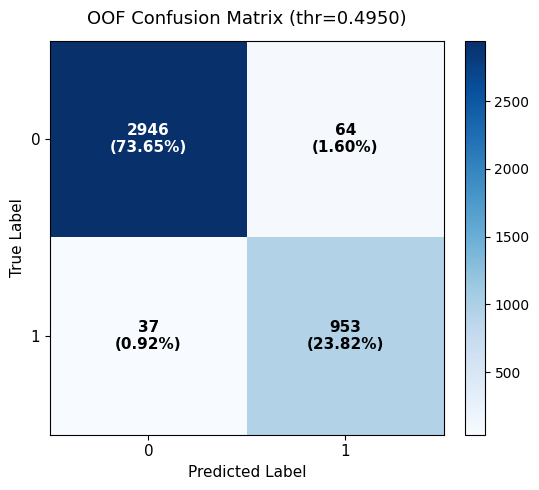


--------------------------------------------------------------------------------
OOF CALIBRATION INPUT PREVIEW (use for calibration / Platt / Isotonic)
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.002289
      0       0.006125
      0       0.002229
      1       0.940142
      0       0.001734
      1       0.986697
      0       0.002783
      0       0.002020
      0       0.002984
      0       0.006049

Shape: (4000, 2)


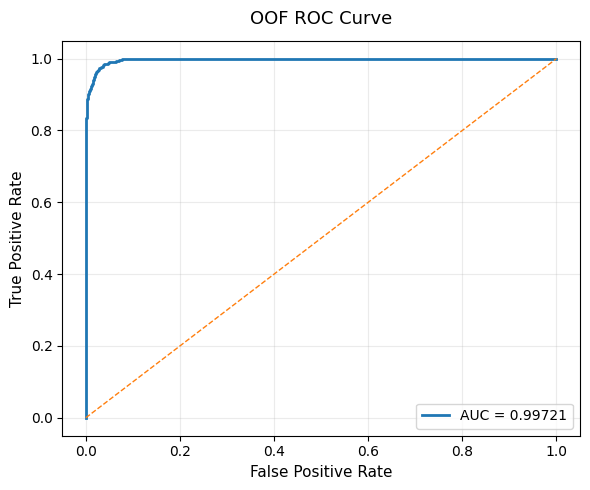


--------------------------------------------------------------------------------
OOF ROC ARRAYS PREVIEW
--------------------------------------------------------------------------------
     fpr      tpr  threshold
0.000000 0.000000        inf
0.000000 0.001010   0.989757
0.000000 0.154545   0.988225
0.000000 0.156566   0.988216
0.000000 0.413131   0.980988
0.000000 0.415152   0.980945
0.000000 0.778788   0.952625
0.000332 0.778788   0.951874
0.000332 0.815152   0.938402
0.000664 0.815152   0.937099

Shape: (154, 3)

--------------------------------------------------------------------------------
FINAL VALIDATION CALIBRATION INPUT PREVIEW (good for Platt / Isotonic)
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.000490
      0       0.002642
      0       0.000414
      1       0.992739
      0       0.006938
      1       0.995304
      1       0.992488
      0       0.000442
      0       0.000357
      0       

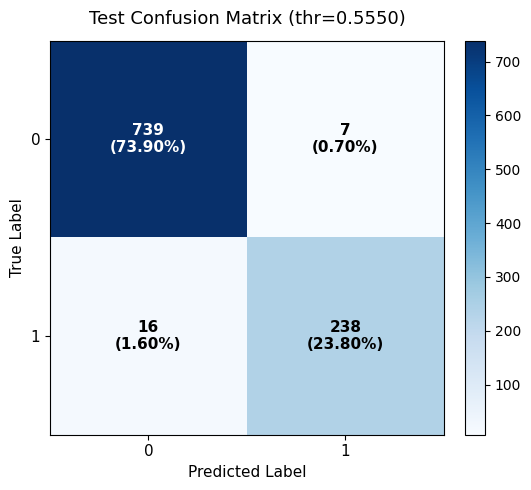


--------------------------------------------------------------------------------
TEST CALIBRATION INPUT PREVIEW
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.000351
      0       0.000994
      1       0.993425
      0       0.331283
      0       0.000394
      0       0.000420
      1       0.995011
      0       0.000399
      0       0.000373
      0       0.001506

Shape: (1000, 2)


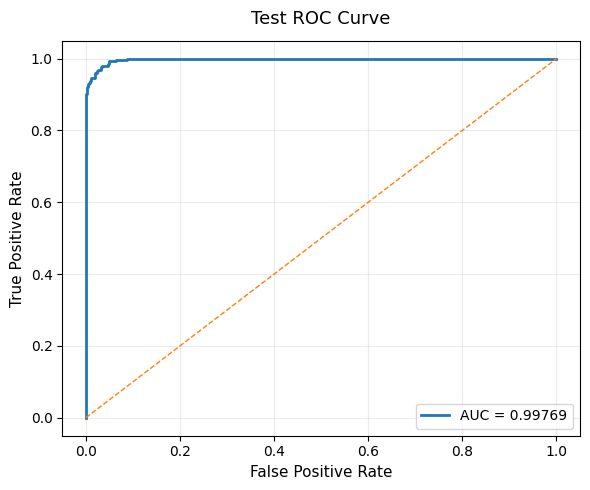


--------------------------------------------------------------------------------
TEST ROC ARRAYS PREVIEW
--------------------------------------------------------------------------------
     fpr      tpr  threshold
0.000000 0.000000        inf
0.000000 0.003937   0.995408
0.000000 0.133858   0.995178
0.000000 0.141732   0.995177
0.000000 0.267717   0.994756
0.000000 0.275591   0.994749
0.000000 0.889764   0.840247
0.001340 0.889764   0.834767
0.001340 0.901575   0.828068
0.002681 0.901575   0.803779

Shape: (44, 3)

READY VARIABLES IN MEMORY
                                     Use            Variable Name   Shape
                         OOF true labels   y_true_oof_calibration (4000,)
             OOF probabilities (class 1)   y_prob_oof_calibration (4000,)
            Final validation true labels y_true_valid_calibration  (400,)
Final validation probabilities (class 1) y_prob_valid_calibration  (400,)
                 Final validation logits logits_valid_temperature  (400,)
       

In [ ]:
import os
import json
import time
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    matthews_corrcoef,
    confusion_matrix,
    balanced_accuracy_score,
    brier_score_loss,
    roc_curve,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

TRAIN_PATH = "/content/train_fs_selected.csv"
TEST_PATH  = "/content/test_fs_selected.csv"
TARGET_COLUMN = "lung_cancer_risk"
ID_COLUMNS = []
DROP_COLUMNS = []

OUTPUT_DIR = "/content/fast_nested_tabsymformer_fast_f1fix"
SAVE_OUTPUTS = False
SHOW_PLOTS = False

SEED = 42

OUTER_FOLDS = 5
INNER_FOLDS = 2

N_TRIALS = 3
MAX_EPOCHS_INNER = 6
MAX_EPOCHS_OUTER = 10
MAX_EPOCHS_FINAL = 12

PATIENCE_INNER = 2
PATIENCE_OUTER = 3
PATIENCE_FINAL = 3

OUTER_DEV_VALID_SIZE = 0.12
FINAL_VALID_SIZE = 0.10

USE_AMP = True
NUM_WORKERS = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

THRESHOLD_GRID = np.linspace(0.16, 0.60, 177)
ACC_DROP_TOL = 0.0015

MIN_DYNAMIC_PRECISION = 0.970
PRECISION_RELAX = 0.012

USE_MILD_POS_WEIGHT = True
POS_WEIGHT_POWER = 0.35
POS_WEIGHT_MAX = 1.25

HP_ACC_TOL = 0.0015

FINAL_ENSEMBLE_SEEDS = [42]

SEARCH_CANDIDATES = [
    {"embed_dim": 128, "num_heads": 4, "depth": 2, "ff_mult": 2.0, "dropout": 0.08, "token_dropout": 0.01, "lr": 1.0e-3, "weight_decay": 1e-5, "batch_size": 2048},
    {"embed_dim": 160, "num_heads": 4, "depth": 2, "ff_mult": 2.0, "dropout": 0.10, "token_dropout": 0.02, "lr": 8.0e-4, "weight_decay": 1e-5, "batch_size": 2048},
    {"embed_dim": 192, "num_heads": 4, "depth": 3, "ff_mult": 2.0, "dropout": 0.10, "token_dropout": 0.02, "lr": 8.0e-4, "weight_decay": 1e-5, "batch_size": 1024},
]

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

def now():
    return time.strftime("%H:%M:%S")

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def safe_read_csv(path):
    if path is None or str(path).strip() == "":
        return None
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)

def to_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def clip_probs(prob, eps=1e-7):
    return np.clip(np.asarray(prob, dtype=np.float64), eps, 1 - eps)

def safe_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, prob))

def safe_pr_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, prob))

def metric_score_binary(y_true, y_pred, metric_name="accuracy"):
    if metric_name == "accuracy":
        return accuracy_score(y_true, y_pred)
    if metric_name == "f1":
        return f1_score(y_true, y_pred, zero_division=0)
    if metric_name == "mcc":
        return matthews_corrcoef(y_true, y_pred)
    if metric_name == "balanced_accuracy":
        return balanced_accuracy_score(y_true, y_pred)
    raise ValueError(f"Unsupported metric: {metric_name}")

def _threshold_table(y_true, prob, grid):
    rows = []
    prob = clip_probs(prob)

    for t in grid:
        pred = (prob >= t).astype(int)
        acc = accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)
        f1v = f1_score(y_true, pred, zero_division=0)
        mcc = matthews_corrcoef(y_true, pred)

        rows.append({
            "threshold": float(t),
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1v),
            "mcc": float(mcc),
        })

    return pd.DataFrame(rows)

def _pick_best_threshold_from_df(df_thr: pd.DataFrame) -> float:
    """
    Tie-break order after accuracy safety:
    1) max F1
    2) max Recall
    3) max Accuracy
    4) max MCC
    5) max Precision
    6) lower threshold
    """
    if df_thr.empty:
        return 0.50

    df_thr = df_thr.sort_values(
        by=["f1", "recall", "accuracy", "mcc", "precision", "threshold"],
        ascending=[False, False, False, False, False, True]
    ).reset_index(drop=True)

    return float(df_thr.loc[0, "threshold"])

def tune_threshold_constrained(
    y_true,
    prob,
    grid=None,
    acc_drop_tol=0.0015,
    min_dynamic_precision=0.970,
    precision_relax=0.012,
):
    """
    Accuracy-safe threshold tuning with dynamic precision protection.

    Steps:
    1) compute full threshold table
    2) keep thresholds within best-accuracy tolerance
    3) estimate precision at the best-accuracy operating region
    4) allow a small precision relaxation from that reference
    5) inside that safe region, maximize F1 -> Recall -> Accuracy -> MCC
    """
    if grid is None:
        grid = np.linspace(0.16, 0.60, 177)

    prob = clip_probs(prob)
    thr_df = _threshold_table(y_true, prob, grid)

    best_acc = float(thr_df["accuracy"].max())
    acc_floor = best_acc - float(acc_drop_tol)

    safe_df = thr_df.loc[thr_df["accuracy"] >= acc_floor].copy()
    if safe_df.empty:
        safe_df = thr_df.copy()

    best_acc_df = thr_df.loc[thr_df["accuracy"] >= best_acc - 1e-12].copy()
    best_acc_df = best_acc_df.sort_values(
        by=["f1", "recall", "mcc", "precision", "threshold"],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

    ref_precision = float(best_acc_df.loc[0, "precision"])
    precision_floor = max(float(min_dynamic_precision), ref_precision - float(precision_relax))

    guarded_df = safe_df.loc[safe_df["precision"] >= precision_floor].copy()
    if guarded_df.empty:
        guarded_df = safe_df.copy()

    return _pick_best_threshold_from_df(guarded_df)

def choose_best_hp_info(info_list, acc_tol=0.0015):
    """
    Keep only HPs within best accuracy tolerance,
    then choose the one with better F1 / recall / MCC.
    """
    rows = []
    for i, info in enumerate(info_list):
        m = info["metrics"]
        rows.append({
            "idx": i,
            "accuracy": float(m["accuracy"]),
            "f1": float(m["f1"]),
            "recall": float(m["recall"]),
            "precision": float(m["precision"]),
            "mcc": float(m["mcc"]),
            "logloss": float(m["logloss"]),
        })

    df = pd.DataFrame(rows)
    best_acc = float(df["accuracy"].max())

    keep = df.loc[df["accuracy"] >= best_acc - float(acc_tol)].copy()
    keep = keep.sort_values(
        by=["f1", "recall", "mcc", "precision", "accuracy", "logloss"],
        ascending=[False, False, False, False, False, True]
    ).reset_index(drop=True)

    return info_list[int(keep.loc[0, "idx"])]

def compute_metrics(y_true, prob, threshold=0.5):
    prob = clip_probs(prob)
    pred = (prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "specificity": float(specificity),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "roc_auc": safe_auc(y_true, prob),
        "pr_auc": safe_pr_auc(y_true, prob),
        "logloss": float(log_loss(y_true, prob, labels=[0, 1])),
        "brier": float(brier_score_loss(y_true, prob)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def plot_conf_matrix(cm, title="Confusion Matrix", class_names=("0", "1")):
    cm = np.asarray(cm)
    total = cm.sum()
    pct = (cm / total * 100.0) if total > 0 else np.zeros_like(cm, dtype=float)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)

    thresh = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f"{cm[i, j]}\n({pct[i, j]:.2f}%)",
                ha="center", va="center",
                fontsize=11,
                fontweight="bold",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()

def plot_roc_curve_from_prob(y_true, prob, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        print(f"{title}: skipped because only one class is present.")
        return None, None, None, np.nan

    fpr, tpr, thresholds = roc_curve(y_true, prob)
    auc_val = roc_auc_score(y_true, prob)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.5f}")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    ax.legend(loc="lower right")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return fpr, tpr, thresholds, auc_val

def print_preview_table(df, title, n=10):
    print("\n" + "-" * 80)
    print(title)
    print("-" * 80)
    print(df.head(n).to_string(index=False))
    print(f"\nShape: {df.shape}")

def hp_to_str(hp):
    return (
        f"embed={hp['embed_dim']} | heads={hp['num_heads']} | depth={hp['depth']} | "
        f"ff_mult={hp['ff_mult']} | drop={hp['dropout']} | tok_drop={hp['token_dropout']} | "
        f"lr={hp['lr']} | wd={hp['weight_decay']} | bs={hp['batch_size']}"
    )

class FoldPreprocessor:
    def __init__(self):
        self.imputer = SimpleImputer(strategy="median")
        self.scaler = StandardScaler()

    def fit(self, X_df):
        X_num = to_numeric_df(X_df)
        X_imp = self.imputer.fit_transform(X_num)
        self.scaler.fit(X_imp)
        return self

    def transform(self, X_df):
        X_num = to_numeric_df(X_df)
        X_imp = self.imputer.transform(X_num)
        X_scaled = self.scaler.transform(X_imp)
        X_scaled = np.clip(X_scaled, -8.0, 8.0).astype(np.float32)
        return X_scaled

    def fit_transform(self, X_df):
        self.fit(X_df)
        return self.transform(X_df)

class NumericFeatureTokenizer(nn.Module):
    """
    Each scalar feature becomes a learnable token.
    token_j = x_j * W_j + B_j + E_j
    """
    def __init__(self, n_features, embed_dim, token_dropout=0.01):
        super().__init__()
        self.n_features = n_features
        self.embed_dim = embed_dim
        self.token_dropout = float(token_dropout)

        self.weight = nn.Parameter(torch.randn(n_features, embed_dim) * 0.02)
        self.bias = nn.Parameter(torch.zeros(n_features, embed_dim))
        self.feature_embed = nn.Parameter(torch.randn(n_features, embed_dim) * 0.02)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        tokens = x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0) + self.feature_embed.unsqueeze(0)

        if self.training and self.token_dropout > 0:
            keep = (torch.rand((x.size(0), x.size(1), 1), device=x.device) > self.token_dropout).float()
            tokens = tokens * keep

        tokens = self.norm(tokens)
        return tokens

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_mult=2.0, dropout=0.10):
        super().__init__()
        ff_dim = int(embed_dim * ff_mult)

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.drop1 = nn.Dropout(dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff1 = nn.Linear(embed_dim, ff_dim * 2)
        self.ff2 = nn.Linear(ff_dim, embed_dim)
        self.drop2 = nn.Dropout(dropout)

        self.gate = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        y = self.norm1(x)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x = x + self.drop1(attn_out)

        y = self.norm2(x)
        a, b = self.ff1(y).chunk(2, dim=-1)
        y = a * F.gelu(b)
        y = self.ff2(self.drop2(y))

        gate = self.gate(x)
        x = x + gate * y
        return x

class TabFGT(nn.Module):
    """
    Faster custom transformer for encoded numeric tabular data.
    Lighter head: CLS + mean pooling only.
    """
    def __init__(
        self,
        input_dim,
        embed_dim=160,
        num_heads=4,
        depth=2,
        ff_mult=2.0,
        dropout=0.10,
        token_dropout=0.01,
    ):
        super().__init__()

        self.tokenizer = NumericFeatureTokenizer(
            n_features=input_dim,
            embed_dim=embed_dim,
            token_dropout=token_dropout
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.cls_bias = nn.Parameter(torch.zeros(1, 1, embed_dim))

        self.blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ff_mult=ff_mult,
                dropout=dropout
            )
            for _ in range(depth)
        ])

        self.final_norm = nn.LayerNorm(embed_dim)

        head_dim = embed_dim * 2
        hidden2 = max(embed_dim, 128)

        self.head = nn.Sequential(
            nn.LayerNorm(head_dim),
            nn.Linear(head_dim, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, hidden2 // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2 // 2, 1),
        )

    def forward(self, x):
        tok = self.tokenizer(x)
        cls = self.cls_token.expand(x.size(0), -1, -1) + self.cls_bias
        tok = torch.cat([cls, tok], dim=1)

        for block in self.blocks:
            tok = block(tok)

        tok = self.final_norm(tok)

        cls_tok = tok[:, 0]
        feat_tok = tok[:, 1:]
        mean_tok = feat_tok.mean(dim=1)

        rep = torch.cat([cls_tok, mean_tok], dim=1)
        out = self.head(rep).squeeze(1)
        return out

def make_loader(X, y=None, batch_size=1024, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    if y is None:
        ds = TensorDataset(X_t)
    else:
        y_t = torch.tensor(y, dtype=torch.float32)
        ds = TensorDataset(X_t, y_t)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )

@torch.no_grad()
def predict_proba(model, X, batch_size=1024):
    model.eval()
    loader = make_loader(X, y=None, batch_size=batch_size, shuffle=False)
    probs = []

    for batch in loader:
        xb = batch[0].to(DEVICE, non_blocking=True)
        logits = model(xb)
        p = torch.sigmoid(logits).detach().cpu().numpy()
        probs.append(p)

    return np.concatenate(probs).astype(np.float64)

@torch.no_grad()
def predict_logits(model, X, batch_size=1024):
    model.eval()
    loader = make_loader(X, y=None, batch_size=batch_size, shuffle=False)
    logits_all = []

    for batch in loader:
        xb = batch[0].to(DEVICE, non_blocking=True)
        logits = model(xb).detach().cpu().numpy()
        logits_all.append(logits)

    return np.concatenate(logits_all).astype(np.float64)

def train_one_model(
    X_train, y_train,
    X_valid, y_valid,
    hp,
    max_epochs=12,
    patience=3,
    seed=42
):
    set_seed(seed)

    model = TabFGT(
        input_dim=X_train.shape[1],
        embed_dim=hp["embed_dim"],
        num_heads=hp["num_heads"],
        depth=hp["depth"],
        ff_mult=hp["ff_mult"],
        dropout=hp["dropout"],
        token_dropout=hp["token_dropout"],
    ).to(DEVICE)

    train_loader = make_loader(X_train, y_train, batch_size=hp["batch_size"], shuffle=True)
    valid_loader = make_loader(X_valid, y_valid, batch_size=max(1024, hp["batch_size"]), shuffle=False)

    pos_count = max(float(np.sum(np.asarray(y_train) == 1)), 1.0)
    neg_count = max(float(np.sum(np.asarray(y_train) == 0)), 1.0)

    if USE_MILD_POS_WEIGHT:
        pos_weight_value = float(np.clip((neg_count / pos_count) ** POS_WEIGHT_POWER, 1.0, POS_WEIGHT_MAX))
    else:
        pos_weight_value = 1.0

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"]
    )

    steps_per_epoch = max(1, len(train_loader))
    total_steps = max(1, max_epochs * steps_per_epoch)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=hp["lr"],
        total_steps=total_steps,
        pct_start=0.20,
        div_factor=8.0,
        final_div_factor=80.0,
    )

    use_amp_now = bool(USE_AMP and DEVICE.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp_now)

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = np.inf
    best_epoch = 0
    bad_epochs = 0
    min_delta = 5e-4

    for epoch in range(1, max_epochs + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp_now):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

        model.eval()
        val_probs = []
        for xb, _ in valid_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp_now):
                logits = model(xb)
                p = torch.sigmoid(logits)
            val_probs.append(p.detach().cpu().numpy())

        val_probs = np.concatenate(val_probs).astype(np.float64)
        val_loss = log_loss(y_valid, clip_probs(val_probs), labels=[0, 1])

        if val_loss < best_val_loss - min_delta:
            best_val_loss = float(val_loss)
            best_epoch = int(epoch)
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    model.load_state_dict(best_state)
    return model, best_epoch, best_val_loss, pos_weight_value

def inner_cv_score(X_df, y, hp, seed=42):
    skf = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=seed)
    oof_prob = np.zeros(len(y), dtype=np.float64)
    pos_weights_used = []

    for inner_fold, (tr_idx, va_idx) in enumerate(skf.split(X_df, y), start=1):
        X_tr_df = X_df.iloc[tr_idx].reset_index(drop=True)
        X_va_df = X_df.iloc[va_idx].reset_index(drop=True)
        y_tr = y[tr_idx]
        y_va = y[va_idx]

        prep = FoldPreprocessor()
        X_tr = prep.fit_transform(X_tr_df)
        X_va = prep.transform(X_va_df)

        model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
            X_tr, y_tr,
            X_va, y_va,
            hp=hp,
            max_epochs=MAX_EPOCHS_INNER,
            patience=PATIENCE_INNER,
            seed=seed + inner_fold * 77
        )
        pos_weights_used.append(float(pos_weight_value))

        prob = predict_proba(model, X_va, batch_size=max(1024, hp["batch_size"]))
        oof_prob[va_idx] = prob

    best_thr = tune_threshold_constrained(
        y_true=y,
        prob=oof_prob,
        grid=THRESHOLD_GRID,
        acc_drop_tol=ACC_DROP_TOL,
        min_dynamic_precision=MIN_DYNAMIC_PRECISION,
        precision_relax=PRECISION_RELAX,
    )
    metrics = compute_metrics(y, oof_prob, threshold=best_thr)

    return {
        "hp": hp,
        "threshold": best_thr,
        "metrics": metrics,
        "score": metrics["accuracy"],
        "mean_pos_weight": float(np.mean(pos_weights_used)) if len(pos_weights_used) > 0 else 1.0,
    }

set_seed(SEED)
ensure_dir(OUTPUT_DIR)

print("\n" + "=" * 80)
print(f"[{now()}] LOADING DATA")
print("=" * 80)

train_df = safe_read_csv(TRAIN_PATH)
test_df = safe_read_csv(TEST_PATH)

if TARGET_COLUMN not in train_df.columns:
    raise ValueError(f"Target column '{TARGET_COLUMN}' not found.")

drop_train = list(set(ID_COLUMNS + DROP_COLUMNS + [TARGET_COLUMN]))
X_train_df = train_df.drop(columns=[c for c in drop_train if c in train_df.columns], errors="ignore").copy()
y_raw = train_df[TARGET_COLUMN].copy()

le = LabelEncoder()
y = le.fit_transform(y_raw)

if len(le.classes_) != 2:
    raise ValueError(f"Binary classification only. Found classes: {list(le.classes_)}")

class_names = [str(x) for x in le.classes_]

print(f"Train shape   : {train_df.shape}")
print(f"Feature shape : {X_train_df.shape}")
print(f"Classes       : {class_names}")
print(f"Device        : {DEVICE}")

if test_df is not None:
    drop_test = list(set(ID_COLUMNS + DROP_COLUMNS + [TARGET_COLUMN]))
    X_test_df = test_df.drop(columns=[c for c in drop_test if c in test_df.columns], errors="ignore").copy()

    if TARGET_COLUMN in test_df.columns:
        y_test = le.transform(test_df[TARGET_COLUMN])
        has_test_labels = True
    else:
        y_test = None
        has_test_labels = False

    print(f"Test shape    : {test_df.shape}")
    print(f"Test labels   : {'present' if has_test_labels else 'absent'}")
else:
    X_test_df = None
    y_test = None
    has_test_labels = False

print("\n" + "=" * 80)
print(f"[{now()}] STARTING NESTED CV ({OUTER_FOLDS} OUTER x {INNER_FOLDS} INNER)")
print("=" * 80)

outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)

oof_prob = np.zeros(len(y), dtype=np.float64)
outer_rows = []
outer_thresholds = []
outer_best_hps = []
outer_test_probs = []

candidate_pool = SEARCH_CANDIDATES[:N_TRIALS]

for outer_fold, (dev_idx, hold_idx) in enumerate(outer_cv.split(X_train_df, y), start=1):
    print(f"\n[{now()}] OUTER FOLD {outer_fold}/{OUTER_FOLDS}")

    X_dev_df = X_train_df.iloc[dev_idx].reset_index(drop=True)
    y_dev = y[dev_idx]

    X_hold_df = X_train_df.iloc[hold_idx].reset_index(drop=True)
    y_hold = y[hold_idx]

    fold_infos = []

    for trial_id, hp in enumerate(candidate_pool, start=1):
        info = inner_cv_score(
            X_df=X_dev_df,
            y=y_dev,
            hp=hp,
            seed=SEED + outer_fold * 100 + trial_id
        )
        fold_infos.append(info)

        m = info["metrics"]
        print(
            f"  trial {trial_id}/{len(candidate_pool)} | "
            f"acc={m['accuracy']:.5f} | f1={m['f1']:.5f} | rec={m['recall']:.5f} | "
            f"prec={m['precision']:.5f} | mcc={m['mcc']:.5f} | "
            f"auc={m['roc_auc']:.5f} | logloss={m['logloss']:.5f} | "
            f"thr={info['threshold']:.3f} | pos_w={info['mean_pos_weight']:.3f}"
        )

    best_info = choose_best_hp_info(fold_infos, acc_tol=HP_ACC_TOL)
    best_hp = best_info["hp"]
    best_thr = best_info["threshold"]

    outer_best_hps.append(best_hp)
    outer_thresholds.append(best_thr)

    print(f"  best hp  : {hp_to_str(best_hp)}")
    print(f"  best thr : {best_thr:.3f}")

    X_tr_df, X_va_df, y_tr, y_va = train_test_split(
        X_dev_df, y_dev,
        test_size=OUTER_DEV_VALID_SIZE,
        random_state=SEED + outer_fold,
        stratify=y_dev
    )

    prep = FoldPreprocessor()
    X_tr = prep.fit_transform(X_tr_df)
    X_va = prep.transform(X_va_df)
    X_hold = prep.transform(X_hold_df)

    model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
        X_tr, y_tr,
        X_va, y_va,
        hp=best_hp,
        max_epochs=MAX_EPOCHS_OUTER,
        patience=PATIENCE_OUTER,
        seed=SEED + outer_fold * 1000
    )

    hold_prob = predict_proba(model, X_hold, batch_size=max(1024, best_hp["batch_size"]))
    oof_prob[hold_idx] = hold_prob

    fold_metrics = compute_metrics(y_hold, hold_prob, threshold=best_thr)
    fold_metrics["outer_fold"] = outer_fold
    fold_metrics["best_epoch"] = best_epoch
    fold_metrics["best_val_loss"] = best_val_loss
    fold_metrics["pos_weight"] = float(pos_weight_value)
    outer_rows.append(fold_metrics)

    print(
        f"  fold result | acc={fold_metrics['accuracy']:.5f} | "
        f"prec={fold_metrics['precision']:.5f} | rec={fold_metrics['recall']:.5f} | "
        f"spec={fold_metrics['specificity']:.5f} | f1={fold_metrics['f1']:.5f} | "
        f"mcc={fold_metrics['mcc']:.5f} | auc={fold_metrics['roc_auc']:.5f} | "
        f"logloss={fold_metrics['logloss']:.5f}"
    )

    if X_test_df is not None:
        X_test_proc = prep.transform(X_test_df)
        test_prob_fold = predict_proba(model, X_test_proc, batch_size=max(1024, best_hp["batch_size"]))
        outer_test_probs.append(test_prob_fold)

outer_df = pd.DataFrame(outer_rows)

global_threshold = tune_threshold_constrained(
    y_true=y,
    prob=oof_prob,
    grid=THRESHOLD_GRID,
    acc_drop_tol=ACC_DROP_TOL,
    min_dynamic_precision=MIN_DYNAMIC_PRECISION,
    precision_relax=PRECISION_RELAX,
)

oof_metrics = compute_metrics(y, oof_prob, threshold=global_threshold)

print("\n" + "=" * 80)
print(f"[{now()}] NESTED CV SUMMARY")
print("=" * 80)
print(outer_df[
    ["outer_fold", "accuracy", "precision", "recall", "specificity", "f1",
     "mcc", "balanced_accuracy", "roc_auc", "pr_auc", "logloss", "threshold", "pos_weight"]
].round(5).to_string(index=False))

print("\nOOF SUMMARY")
print(pd.DataFrame([oof_metrics]).round(5).to_string(index=False))

if SHOW_PLOTS:
    cm_oof = confusion_matrix(y, (oof_prob >= global_threshold).astype(int), labels=[0, 1])
    plot_conf_matrix(
        cm_oof,
        title=f"OOF Confusion Matrix (thr={global_threshold:.3f})",
        class_names=class_names
    )

hp_keys = [tuple(sorted(hp.items())) for hp in outer_best_hps]
hp_counter = Counter(hp_keys)
max_count = max(hp_counter.values())
candidates = [dict(k) for k, v in hp_counter.items() if v == max_count]

if len(candidates) == 1:
    final_best_hp = candidates[0]
else:
    rows = []
    for cand in candidates:
        mask = [hp == cand for hp in outer_best_hps]
        rows.append({
            "hp": cand,
            "mean_acc": float(outer_df.loc[mask, "accuracy"].mean()),
            "mean_f1": float(outer_df.loc[mask, "f1"].mean()),
            "mean_recall": float(outer_df.loc[mask, "recall"].mean()),
            "mean_mcc": float(outer_df.loc[mask, "mcc"].mean()),
            "mean_logloss": float(outer_df.loc[mask, "logloss"].mean()),
        })

    hp_df = pd.DataFrame(rows)
    best_mean_acc = float(hp_df["mean_acc"].max())

    keep = hp_df.loc[hp_df["mean_acc"] >= best_mean_acc - HP_ACC_TOL].copy()
    keep = keep.sort_values(
        by=["mean_f1", "mean_recall", "mean_mcc", "mean_acc", "mean_logloss"],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

    final_best_hp = keep.iloc[0]["hp"]

print("\n" + "=" * 80)
print(f"[{now()}] FINAL CHOSEN SETTINGS")
print("=" * 80)
print("Final best hyperparameters:")
print(json.dumps(final_best_hp, indent=2))
print(f"OOF-derived threshold: {global_threshold:.4f}")

final_models = []
final_preps = []
final_valid_probs = []
final_valid_targets = []
final_valid_logits = []

for i, seed_i in enumerate(FINAL_ENSEMBLE_SEEDS, start=1):
    print(f"\n[{now()}] FINAL MODEL {i}/{len(FINAL_ENSEMBLE_SEEDS)}")

    X_tr_df, X_va_df, y_tr, y_va = train_test_split(
        X_train_df, y,
        test_size=FINAL_VALID_SIZE,
        random_state=seed_i,
        stratify=y
    )

    prep = FoldPreprocessor()
    X_tr = prep.fit_transform(X_tr_df)
    X_va = prep.transform(X_va_df)

    model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
        X_tr, y_tr,
        X_va, y_va,
        hp=final_best_hp,
        max_epochs=MAX_EPOCHS_FINAL,
        patience=PATIENCE_FINAL,
        seed=seed_i
    )

    final_models.append(model)
    final_preps.append(prep)

    va_prob = predict_proba(model, X_va, batch_size=max(1024, final_best_hp["batch_size"]))
    va_logit = predict_logits(model, X_va, batch_size=max(1024, final_best_hp["batch_size"]))

    final_valid_probs.append(va_prob)
    final_valid_targets.append(np.asarray(y_va, dtype=int))
    final_valid_logits.append(va_logit)

    print(
        f"  best_epoch={best_epoch} | best_val_loss={best_val_loss:.5f} | "
        f"pos_weight={pos_weight_value:.3f}"
    )

def predict_ensemble(models, preps, X_df, batch_size=1024):
    probs = []
    for model, prep in zip(models, preps):
        X_proc = prep.transform(X_df)
        p = predict_proba(model, X_proc, batch_size=batch_size)
        probs.append(p)
    return np.mean(np.vstack(probs), axis=0)

final_valid_prob = None
final_valid_y = None
final_valid_logit = None

if len(final_valid_probs) > 0:
    final_valid_prob = np.concatenate(final_valid_probs).astype(np.float64)
    final_valid_y = np.concatenate(final_valid_targets).astype(int)
    final_valid_logit = np.concatenate(final_valid_logits).astype(np.float64)

    final_threshold = tune_threshold_constrained(
        y_true=final_valid_y,
        prob=final_valid_prob,
        grid=THRESHOLD_GRID,
        acc_drop_tol=ACC_DROP_TOL,
        min_dynamic_precision=MIN_DYNAMIC_PRECISION,
        precision_relax=PRECISION_RELAX,
    )
else:
    final_threshold = global_threshold

print(f"\n[{now()}] FINAL DEPLOYMENT THRESHOLD: {final_threshold:.4f}")

if X_test_df is not None:
    print("\n" + "=" * 80)
    print(f"[{now()}] TEST RESULT")
    print("=" * 80)

    final_test_prob = predict_ensemble(
        final_models,
        final_preps,
        X_test_df,
        batch_size=max(1024, final_best_hp["batch_size"])
    )
    final_test_pred = (final_test_prob >= final_threshold).astype(int)

    if has_test_labels:
        test_metrics = compute_metrics(y_test, final_test_prob, threshold=final_threshold)
        print(pd.DataFrame([test_metrics]).round(5).to_string(index=False))

        if SHOW_PLOTS:
            cm_test = confusion_matrix(y_test, final_test_pred, labels=[0, 1])
            plot_conf_matrix(
                cm_test,
                title=f"Test Confusion Matrix (thr={final_threshold:.3f})",
                class_names=class_names
            )

        if len(outer_test_probs) > 0:
            nested_test_prob = np.mean(np.vstack(outer_test_probs), axis=0)
            nested_test_metrics = compute_metrics(y_test, nested_test_prob, threshold=global_threshold)

            print("\nOuter-fold test ensemble reference:")
            print(pd.DataFrame([nested_test_metrics]).round(5).to_string(index=False))
    else:
        test_metrics = None
        print("Test labels not available.")
else:
    final_test_prob = None
    final_test_pred = None
    test_metrics = None

if SAVE_OUTPUTS:
    ensure_dir(OUTPUT_DIR)

    outer_df.to_csv(os.path.join(OUTPUT_DIR, "outer_fold_results.csv"), index=False)
    pd.DataFrame([oof_metrics]).to_csv(os.path.join(OUTPUT_DIR, "oof_metrics.csv"), index=False)

    with open(os.path.join(OUTPUT_DIR, "final_best_hyperparameters.json"), "w") as f:
        json.dump(
            {
                "best_hyperparameters": final_best_hp,
                "oof_global_threshold": global_threshold,
                "final_threshold": final_threshold,
                "classes": class_names,
                "device": str(DEVICE),
                "model_name": "TabFGT-Fast-F1Fix",
                "threshold_grid_start": float(THRESHOLD_GRID[0]),
                "threshold_grid_end": float(THRESHOLD_GRID[-1]),
                "acc_drop_tol": float(ACC_DROP_TOL),
                "min_dynamic_precision": float(MIN_DYNAMIC_PRECISION),
                "precision_relax": float(PRECISION_RELAX),
                "use_mild_pos_weight": bool(USE_MILD_POS_WEIGHT),
                "pos_weight_power": float(POS_WEIGHT_POWER),
                "pos_weight_max": float(POS_WEIGHT_MAX),
                "hp_acc_tol": float(HP_ACC_TOL),
            },
            f,
            indent=2
        )

    oof_pred = (oof_prob >= global_threshold).astype(int)
    oof_df = pd.DataFrame({
        "true_label_encoded": y,
        "true_label": [class_names[i] for i in y],
        "prob_positive": oof_prob,
        "pred_label_encoded": oof_pred,
        "pred_label": [class_names[i] for i in oof_pred],
    })
    if ID_COLUMNS:
        ids = [c for c in ID_COLUMNS if c in train_df.columns]
        if len(ids) > 0:
            oof_df = pd.concat([train_df[ids].reset_index(drop=True), oof_df], axis=1)
    oof_df.to_csv(os.path.join(OUTPUT_DIR, "oof_predictions.csv"), index=False)

    if X_test_df is not None:
        test_out = pd.DataFrame({
            "prob_positive": final_test_prob,
            "pred_label_encoded": final_test_pred,
            "pred_label": [class_names[i] for i in final_test_pred],
        })
        if ID_COLUMNS:
            ids = [c for c in ID_COLUMNS if c in test_df.columns]
            if len(ids) > 0:
                test_out = pd.concat([test_df[ids].reset_index(drop=True), test_out], axis=1)
        test_out.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)

    print("\nSaved outputs in:", OUTPUT_DIR)

print("\n" + "=" * 80)
print(f"[{now()}] FINAL REPORT")
print("=" * 80)
print(f"Model         : TabFGT-Fast-F1Fix")
print(f"Final HP      : {hp_to_str(final_best_hp)}")
print(f"OOF thr       : {global_threshold:.4f}")
print(f"Final thr     : {final_threshold:.4f}")
print(f"OOF accuracy  : {oof_metrics['accuracy']:.5f}")
print(f"OOF precision : {oof_metrics['precision']:.5f}")
print(f"OOF recall    : {oof_metrics['recall']:.5f}")
print(f"OOF spec      : {oof_metrics['specificity']:.5f}")
print(f"OOF f1        : {oof_metrics['f1']:.5f}")
print(f"OOF mcc       : {oof_metrics['mcc']:.5f}")
print(f"OOF roc_auc   : {oof_metrics['roc_auc']:.5f}")
print(f"OOF logloss   : {oof_metrics['logloss']:.5f}")

if test_metrics is not None:
    print("\nTEST headline metrics")
    print(f"Test accuracy : {test_metrics['accuracy']:.5f}")
    print(f"Test precision: {test_metrics['precision']:.5f}")
    print(f"Test recall   : {test_metrics['recall']:.5f}")
    print(f"Test spec     : {test_metrics['specificity']:.5f}")
    print(f"Test f1       : {test_metrics['f1']:.5f}")
    print(f"Test mcc      : {test_metrics['mcc']:.5f}")
    print(f"Test roc_auc  : {test_metrics['roc_auc']:.5f}")
    print(f"Test logloss  : {test_metrics['logloss']:.5f}")

print("\n" + "=" * 80)
print(f"[{now()}] DISPLAY OUTPUTS")
print("=" * 80)

y_true_oof_calibration = np.asarray(y, dtype=int)
y_prob_oof_calibration = np.asarray(oof_prob, dtype=np.float64)
y_pred_oof_display = (y_prob_oof_calibration >= global_threshold).astype(int)

cm_oof_display = confusion_matrix(y_true_oof_calibration, y_pred_oof_display, labels=[0, 1])

print("\nOOF CONFUSION MATRIX")
print(pd.DataFrame(
    cm_oof_display,
    index=[f"True_{class_names[0]}", f"True_{class_names[1]}"],
    columns=[f"Pred_{class_names[0]}", f"Pred_{class_names[1]}"]
).to_string())

plot_conf_matrix(
    cm_oof_display,
    title=f"OOF Confusion Matrix (thr={global_threshold:.4f})",
    class_names=class_names
)

oof_calibration_df = pd.DataFrame({
    "y_true": y_true_oof_calibration,
    "y_prob_class1": y_prob_oof_calibration
})

print_preview_table(
    oof_calibration_df,
    "OOF CALIBRATION INPUT PREVIEW (use for calibration / Platt / Isotonic)",
    n=10
)

oof_roc_fpr, oof_roc_tpr, oof_roc_thresholds, oof_roc_auc = plot_roc_curve_from_prob(
    y_true_oof_calibration,
    y_prob_oof_calibration,
    title="OOF ROC Curve"
)

if oof_roc_fpr is not None:
    oof_roc_df = pd.DataFrame({
        "fpr": oof_roc_fpr,
        "tpr": oof_roc_tpr,
        "threshold": oof_roc_thresholds
    })
    print_preview_table(
        oof_roc_df,
        "OOF ROC ARRAYS PREVIEW",
        n=10
    )

if final_valid_prob is not None and final_valid_y is not None:
    y_true_valid_calibration = np.asarray(final_valid_y, dtype=int)
    y_prob_valid_calibration = np.asarray(final_valid_prob, dtype=np.float64)

    valid_calibration_df = pd.DataFrame({
        "y_true": y_true_valid_calibration,
        "y_prob_class1": y_prob_valid_calibration
    })

    print_preview_table(
        valid_calibration_df,
        "FINAL VALIDATION CALIBRATION INPUT PREVIEW (good for Platt / Isotonic)",
        n=10
    )

    if final_valid_logit is not None:
        logits_valid_temperature = np.asarray(final_valid_logit, dtype=np.float64)

        valid_temperature_df = pd.DataFrame({
            "y_true": y_true_valid_calibration,
            "logit": logits_valid_temperature
        })

        print_preview_table(
            valid_temperature_df,
            "FINAL VALIDATION TEMPERATURE-SCALING INPUT PREVIEW (y_true + logits)",
            n=10
        )
    else:
        logits_valid_temperature = None
else:
    y_true_valid_calibration = None
    y_prob_valid_calibration = None
    logits_valid_temperature = None

if final_test_prob is not None and has_test_labels:
    y_true_test_calibration = np.asarray(y_test, dtype=int)
    y_prob_test_calibration = np.asarray(final_test_prob, dtype=np.float64)
    y_pred_test_display = (y_prob_test_calibration >= final_threshold).astype(int)

    cm_test_display = confusion_matrix(y_true_test_calibration, y_pred_test_display, labels=[0, 1])

    print("\nTEST CONFUSION MATRIX")
    print(pd.DataFrame(
        cm_test_display,
        index=[f"True_{class_names[0]}", f"True_{class_names[1]}"],
        columns=[f"Pred_{class_names[0]}", f"Pred_{class_names[1]}"]
    ).to_string())

    plot_conf_matrix(
        cm_test_display,
        title=f"Test Confusion Matrix (thr={final_threshold:.4f})",
        class_names=class_names
    )

    test_calibration_df = pd.DataFrame({
        "y_true": y_true_test_calibration,
        "y_prob_class1": y_prob_test_calibration
    })

    print_preview_table(
        test_calibration_df,
        "TEST CALIBRATION INPUT PREVIEW",
        n=10
    )

    test_roc_fpr, test_roc_tpr, test_roc_thresholds, test_roc_auc = plot_roc_curve_from_prob(
        y_true_test_calibration,
        y_prob_test_calibration,
        title="Test ROC Curve"
    )

    if test_roc_fpr is not None:
        test_roc_df = pd.DataFrame({
            "fpr": test_roc_fpr,
            "tpr": test_roc_tpr,
            "threshold": test_roc_thresholds
        })
        print_preview_table(
            test_roc_df,
            "TEST ROC ARRAYS PREVIEW",
            n=10
        )
else:
    y_true_test_calibration = None
    y_prob_test_calibration = None
    test_roc_fpr = None
    test_roc_tpr = None
    test_roc_thresholds = None
    test_roc_auc = None

print("\n" + "=" * 80)
print("READY VARIABLES IN MEMORY")
print("=" * 80)

ready_rows = [
    ["OOF true labels", "y_true_oof_calibration", None if y_true_oof_calibration is None else y_true_oof_calibration.shape],
    ["OOF probabilities (class 1)", "y_prob_oof_calibration", None if y_prob_oof_calibration is None else y_prob_oof_calibration.shape],
    ["Final validation true labels", "y_true_valid_calibration", None if y_true_valid_calibration is None else y_true_valid_calibration.shape],
    ["Final validation probabilities (class 1)", "y_prob_valid_calibration", None if y_prob_valid_calibration is None else y_prob_valid_calibration.shape],
    ["Final validation logits", "logits_valid_temperature", None if logits_valid_temperature is None else logits_valid_temperature.shape],
    ["Test true labels", "y_true_test_calibration", None if y_true_test_calibration is None else y_true_test_calibration.shape],
    ["Test probabilities (class 1)", "y_prob_test_calibration", None if y_prob_test_calibration is None else y_prob_test_calibration.shape],
    ["OOF ROC FPR", "oof_roc_fpr", None if oof_roc_fpr is None else oof_roc_fpr.shape],
    ["OOF ROC TPR", "oof_roc_tpr", None if oof_roc_tpr is None else oof_roc_tpr.shape],
    ["OOF ROC thresholds", "oof_roc_thresholds", None if oof_roc_thresholds is None else oof_roc_thresholds.shape],
    ["Test ROC FPR", "test_roc_fpr", None if test_roc_fpr is None else test_roc_fpr.shape],
    ["Test ROC TPR", "test_roc_tpr", None if test_roc_tpr is None else test_roc_tpr.shape],
    ["Test ROC thresholds", "test_roc_thresholds", None if test_roc_thresholds is None else test_roc_thresholds.shape],
]

ready_df = pd.DataFrame(ready_rows, columns=["Use", "Variable Name", "Shape"])
print(ready_df.to_string(index=False))

print("\nBEST TO USE FOR CALIBRATION")
print("- OOF true labels + OOF probabilities      : y_true_oof_calibration, y_prob_oof_calibration")
if y_true_test_calibration is not None and y_prob_test_calibration is not None:
    print("- Test true labels + test probabilities    : y_true_test_calibration, y_prob_test_calibration")
if y_true_valid_calibration is not None and y_prob_valid_calibration is not None:
    print("- Validation true labels + probabilities   : y_true_valid_calibration, y_prob_valid_calibration")
if logits_valid_temperature is not None and y_true_valid_calibration is not None:
    print("- Temperature scaling inputs               : y_true_valid_calibration, logits_valid_temperature")

print("\nBEST TO USE FOR ROC")
print("- OOF ROC arrays  : oof_roc_fpr, oof_roc_tpr, oof_roc_thresholds")
if test_roc_fpr is not None:
    print("- Test ROC arrays : test_roc_fpr, test_roc_tpr, test_roc_thresholds")

#**RFE**

In [ ]:
TARGET_COL = "lung_cancer_risk"
USE_EXISTING_DATAFRAMES = False
TRAIN_DF_NAME = "train_df"
TEST_DF_NAME = "test_df"

TRAIN_PATH = "/content/train.csv"
TEST_PATH = "/content/test.csv"

ID_COLS = []
OUTPUT_DIR = "/content"

TRAIN_OUTPUT_PATH = f"{OUTPUT_DIR}/train_fs_selected.csv"
TEST_OUTPUT_PATH = f"{OUTPUT_DIR}/test_fs_selected.csv"
FEATURE_LIST_PATH = f"{OUTPUT_DIR}/selected_features.csv"

TOP_K_MODE = "auto"
TOP_K_VALUE = None
RFE_STEP = 0.1

RANDOM_STATE = 42
VERBOSE = True

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy import sparse
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE, VarianceThreshold
from sklearn.linear_model import LogisticRegression, LinearRegression

def _print(msg=""):
    if VERBOSE:
        print(msg)

def load_dataframe():
    if USE_EXISTING_DATAFRAMES:
        if TRAIN_DF_NAME not in globals():
            raise ValueError(f"'{TRAIN_DF_NAME}' not found in memory.")
        if TEST_DF_NAME not in globals():
            raise ValueError(f"'{TEST_DF_NAME}' not found in memory.")
        train_df = globals()[TRAIN_DF_NAME].copy()
        test_df = globals()[TEST_DF_NAME].copy()
    else:
        if not os.path.exists(TRAIN_PATH):
            raise FileNotFoundError(f"Train file not found: {TRAIN_PATH}")
        if not os.path.exists(TEST_PATH):
            raise FileNotFoundError(f"Test file not found: {TEST_PATH}")
        train_df = pd.read_csv(TRAIN_PATH)
        test_df = pd.read_csv(TEST_PATH)
    return train_df, test_df

def infer_task_type(y: pd.Series) -> str:
    """Infer classification vs regression adaptively."""
    if pd.api.types.is_bool_dtype(y) or pd.api.types.is_object_dtype(y) or pd.api.types.is_categorical_dtype(y):
        return "classification"

    if pd.api.types.is_integer_dtype(y):
        nunique = y.nunique(dropna=True)
        n = len(y)
        if nunique <= max(20, int(0.05 * n)):
            return "classification"

    if pd.api.types.is_float_dtype(y):
        nunique = y.nunique(dropna=True)
        n = len(y)
        if nunique <= max(10, int(0.03 * n)):
            return "classification"

    return "regression"

def align_test_to_train_columns(X_train: pd.DataFrame, X_test: pd.DataFrame):
    """Strictly keep train feature schema; add missing test cols as NaN, drop extra test cols."""
    train_cols = list(X_train.columns)

    for col in train_cols:
        if col not in X_test.columns:
            X_test[col] = np.nan

    extra_test_cols = [c for c in X_test.columns if c not in train_cols]
    if extra_test_cols:
        X_test = X_test.drop(columns=extra_test_cols)

    X_test = X_test[train_cols]
    return X_train, X_test

def get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols):
    """Robust feature name extraction after preprocessing."""
    feature_names = []

    if len(numeric_cols) > 0:
        feature_names.extend([f"num__{c}" for c in numeric_cols])

    if len(categorical_cols) > 0:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(categorical_cols)
        feature_names.extend([f"cat__{c}" for c in cat_names])

    return np.array(feature_names, dtype=object)

def choose_auto_k(n_features: int) -> int:
    """Adaptive top-k size, not fixed."""
    if n_features <= 20:
        return n_features
    k = int(max(10, min(n_features, round(np.sqrt(n_features) * 3))))
    return max(1, min(k, n_features))

def to_dense_if_needed(X):
    return X.toarray() if sparse.issparse(X) else X

def build_dataframe_from_matrix(X, feature_names, index=None):
    X_dense = to_dense_if_needed(X)
    return pd.DataFrame(X_dense, columns=feature_names, index=index)

train_df, test_df = load_dataframe()

if TARGET_COL not in train_df.columns:
    raise ValueError(f"TARGET_COL='{TARGET_COL}' not found in train data.")

_print("=" * 90)
_print("Loaded data")
_print(f"Train shape: {train_df.shape}")
_print(f"Test shape : {test_df.shape}")

train_df_original = train_df.copy()
test_df_original = test_df.copy()

y_train_raw = train_df[TARGET_COL].copy()
X_train = train_df.drop(columns=[TARGET_COL]).copy()

if TARGET_COL in test_df.columns:
    y_test_raw = test_df[TARGET_COL].copy()
    X_test = test_df.drop(columns=[TARGET_COL]).copy()
    test_has_target = True
else:
    y_test_raw = None
    X_test = test_df.copy()
    test_has_target = False

drop_cols = [c for c in ID_COLS if c in X_train.columns]
if drop_cols:
    X_train = X_train.drop(columns=drop_cols, errors="ignore")
    X_test = X_test.drop(columns=drop_cols, errors="ignore")

X_train, X_test = align_test_to_train_columns(X_train, X_test)

TASK_TYPE = infer_task_type(y_train_raw)
_print(f"Detected task type: {TASK_TYPE}")

label_encoder = None
if TASK_TYPE == "classification":
    label_encoder = LabelEncoder()
    y_train_model = label_encoder.fit_transform(y_train_raw.astype(str))
else:
    y_train_model = pd.to_numeric(y_train_raw, errors="coerce")
    if pd.isna(y_train_model).any():
        raise ValueError("Target contains non-numeric values, but task was inferred as regression.")

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

_print(f"Numeric columns     : {len(numeric_cols)}")
_print(f"Categorical columns : {len(categorical_cols)}")

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

feature_names_prep = get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols)

_print(f"Features after preprocessing: {X_train_prep.shape[1]}")

vt = VarianceThreshold(threshold=0.0)
X_train_vt = vt.fit_transform(X_train_prep)
X_test_vt = vt.transform(X_test_prep)

vt_mask = vt.get_support()
feature_names_vt = feature_names_prep[vt_mask]

_print(f"Features after removing constant columns: {X_train_vt.shape[1]}")

n_features_after_vt = X_train_vt.shape[1]

if n_features_after_vt == 0:
    raise ValueError("No features left after preprocessing and constant feature removal.")

if TOP_K_MODE == "manual":
    if TOP_K_VALUE is None:
        raise ValueError("TOP_K_VALUE cannot be None when TOP_K_MODE='manual'")
    top_k = max(1, min(int(TOP_K_VALUE), n_features_after_vt))
else:
    top_k = choose_auto_k(n_features_after_vt)

if TASK_TYPE == "classification":
    base_estimator = LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE,
        solver="liblinear"
    )
else:
    base_estimator = LinearRegression()

X_train_rfe_input = to_dense_if_needed(X_train_vt)
X_test_rfe_input = to_dense_if_needed(X_test_vt)

rfe_selector = RFE(
    estimator=base_estimator,
    n_features_to_select=top_k,
    step=RFE_STEP
)

rfe_selector.fit(X_train_rfe_input, y_train_model)

rfe_mask = rfe_selector.support_
rfe_ranking = rfe_selector.ranking_
final_features = feature_names_vt[rfe_mask]

X_train_final = X_train_rfe_input[:, rfe_mask]
X_test_final = X_test_rfe_input[:, rfe_mask]

selected_features_df = pd.DataFrame({
    "selected_feature": final_features
})

rfe_ranking_df = pd.DataFrame({
    "feature": feature_names_vt,
    "rfe_rank": rfe_ranking,
    "selected": rfe_mask
}).sort_values(by=["rfe_rank", "feature"]).reset_index(drop=True)

selected_train_df = pd.DataFrame(X_train_final, columns=final_features, index=train_df_original.index)
selected_test_df = pd.DataFrame(X_test_final, columns=final_features, index=test_df_original.index)

selected_train_df[TARGET_COL] = y_train_raw.values
if test_has_target:
    selected_test_df[TARGET_COL] = y_test_raw.values

os.makedirs(OUTPUT_DIR, exist_ok=True)

selected_train_df.to_csv(TRAIN_OUTPUT_PATH, index=False)
selected_test_df.to_csv(TEST_OUTPUT_PATH, index=False)
selected_features_df.to_csv(FEATURE_LIST_PATH, index=False)

RFE_RANKING_PATH = f"{OUTPUT_DIR}/rfe_feature_ranking.csv"
rfe_ranking_df.to_csv(RFE_RANKING_PATH, index=False)

summary_df = pd.DataFrame({
    "item": [
        "Task type",
        "Original train rows",
        "Original test rows",
        "Original raw feature count",
        "Features after preprocessing",
        "Features after constant removal",
        "RFE selected",
        "Final selected features",
        "Saved train file",
        "Saved test file",
        "Saved feature list",
        "Saved RFE ranking file",
    ],
    "value": [
        TASK_TYPE,
        train_df_original.shape[0],
        test_df_original.shape[0],
        X_train.shape[1],
        X_train_prep.shape[1],
        X_train_vt.shape[1],
        len(final_features),
        len(final_features),
        TRAIN_OUTPUT_PATH,
        TEST_OUTPUT_PATH,
        FEATURE_LIST_PATH,
        RFE_RANKING_PATH,
    ]
})

_print("\n" + "=" * 90)
_print("FEATURE SELECTION SUMMARY")
_print("=" * 90)
display(summary_df)

_print("\nPreview of final selected features:")
display(selected_features_df.head(100))

_print("\nTop 20 RFE-ranked features:")
display(rfe_ranking_df.head(20))

_print("\nTop 20 selected features:")
print(final_features[:20].tolist())

_print("\nSaved files:")
print(f"Train selected file : {TRAIN_OUTPUT_PATH}")
print(f"Test selected file  : {TEST_OUTPUT_PATH}")
print(f"Feature list file   : {FEATURE_LIST_PATH}")
print(f"RFE ranking file    : {RFE_RANKING_PATH}")

globals()["selected_train_df"] = selected_train_df
globals()["selected_test_df"] = selected_test_df
globals()["selected_features"] = final_features.tolist()
globals()["fs_summary_df"] = summary_df
globals()["rfe_ranking_df"] = rfe_ranking_df

_print("\nDone. Global outputs created:")
print("selected_train_df")
print("selected_test_df")
print("selected_features")
print("fs_summary_df")
print("rfe_ranking_df")

Loaded data
Train shape: (4000, 30)
Test shape : (1000, 30)
Detected task type: classification
Numeric columns     : 29
Categorical columns : 0
Features after preprocessing: 29
Features after removing constant columns: 29

FEATURE SELECTION SUMMARY


,item,value
0,Task type,classification
1,Original train rows,4000
2,Original test rows,1000
3,Original raw feature count,29
4,Features after preprocessing,29
5,Features after constant removal,29
6,RFE selected,16
7,Final selected features,16
8,Saved train file,/content/train_fs_selected.csv
9,Saved test file,/content/test_fs_selected.csv



Preview of final selected features:


,selected_feature
0,num__income_level
1,num__smoker
2,num__pack_years
3,num__passive_smoking
4,num__occupational_exposure
5,num__radon_exposure
6,num__family_history_cancer
7,num__copd
8,num__asthma
9,num__chronic_cough



Top 20 RFE-ranked features:


,feature,rfe_rank,selected
0,num__asthma,1,True
1,num__chronic_cough,1,True
2,num__copd,1,True
3,num__crp_level,1,True
4,num__diet_quality,1,True
5,num__exercise_hours_per_week,1,True
6,num__family_history_cancer,1,True
7,num__fev1_x10,1,True
8,num__healthcare_access,1,True
9,num__income_level,1,True



Top 20 selected features:
['num__income_level', 'num__smoker', 'num__pack_years', 'num__passive_smoking', 'num__occupational_exposure', 'num__radon_exposure', 'num__family_history_cancer', 'num__copd', 'num__asthma', 'num__chronic_cough', 'num__fev1_x10', 'num__crp_level', 'num__xray_abnormal', 'num__exercise_hours_per_week', 'num__diet_quality', 'num__healthcare_access']

Saved files:
Train selected file : /content/train_fs_selected.csv
Test selected file  : /content/test_fs_selected.csv
Feature list file   : /content/selected_features.csv
RFE ranking file    : /content/rfe_feature_ranking.csv

Done. Global outputs created:
selected_train_df
selected_test_df
selected_features
fs_summary_df
rfe_ranking_df



[13:07:15] LOADING DATA
Train shape   : (4000, 17)
Feature shape : (4000, 16)
Classes       : ['0', '1']
Device        : cuda
Test shape    : (1000, 17)
Test labels   : present

[13:07:15] STARTING NESTED CV (5 OUTER x 2 INNER)

[13:07:15] OUTER FOLD 1/5
  trial 1/3 | acc=0.96313 | f1=0.92725 | rec=0.94949 | prec=0.90602 | mcc=0.90302 | auc=0.99251 | logloss=0.51479 | thr=0.410 | pos_w=1.250
  trial 2/3 | acc=0.95344 | f1=0.90819 | rec=0.93056 | prec=0.88688 | mcc=0.87748 | auc=0.99009 | logloss=0.46114 | thr=0.367 | pos_w=1.250
  trial 3/3 | acc=0.95750 | f1=0.91392 | rec=0.91162 | prec=0.91624 | mcc=0.88571 | auc=0.99095 | logloss=0.16916 | thr=0.600 | pos_w=1.250
  best hp  : embed=128 | heads=4 | depth=2 | ff_mult=2.0 | drop=0.08 | tok_drop=0.01 | lr=0.001 | wd=1e-05 | bs=2048
  best thr : 0.410
  fold result | acc=0.96125 | prec=0.91542 | rec=0.92929 | spec=0.97176 | f1=0.92231 | mcc=0.89654 | auc=0.99460 | logloss=0.11264

[13:07:29] OUTER FOLD 2/5
  trial 1/3 | acc=0.93375 | f1

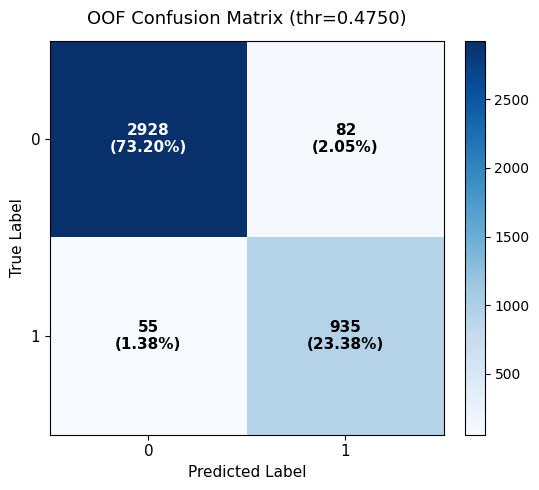


--------------------------------------------------------------------------------
OOF CALIBRATION INPUT PREVIEW (use for calibration / Platt / Isotonic)
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.020540
      0       0.024228
      0       0.020448
      1       0.636318
      0       0.019358
      1       0.985852
      0       0.002241
      0       0.002444
      0       0.030307
      0       0.026916

Shape: (4000, 2)


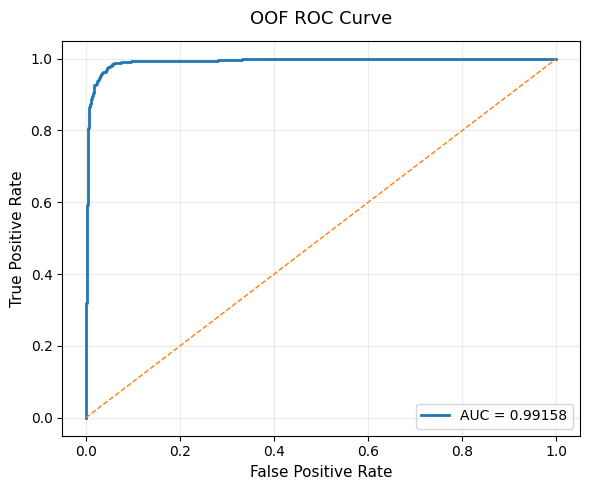


--------------------------------------------------------------------------------
OOF ROC ARRAYS PREVIEW
--------------------------------------------------------------------------------
     fpr      tpr  threshold
0.000000 0.000000        inf
0.000000 0.001010   0.989228
0.000000 0.121212   0.986171
0.000000 0.123232   0.986149
0.000000 0.277778   0.968148
0.000332 0.277778   0.968001
0.000332 0.297980   0.961210
0.000664 0.297980   0.960803
0.000664 0.302020   0.959006
0.000997 0.302020   0.958101

Shape: (218, 3)

--------------------------------------------------------------------------------
FINAL VALIDATION CALIBRATION INPUT PREVIEW (good for Platt / Isotonic)
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.039925
      0       0.064059
      0       0.039560
      1       0.945291
      0       0.064153
      1       0.959015
      1       0.945334
      0       0.040680
      0       0.040049
      0       

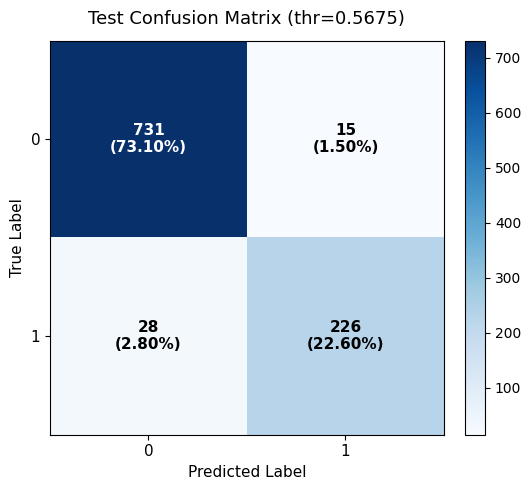


--------------------------------------------------------------------------------
TEST CALIBRATION INPUT PREVIEW
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.041281
      0       0.058549
      1       0.957289
      0       0.301518
      0       0.039610
      0       0.040464
      1       0.956620
      0       0.040824
      0       0.040364
      0       0.050142

Shape: (1000, 2)


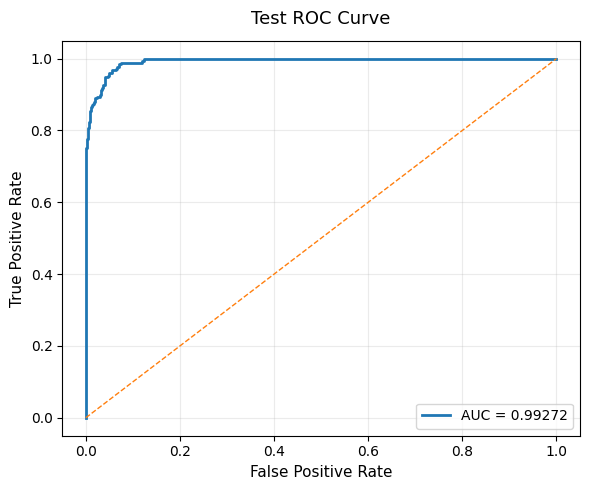


--------------------------------------------------------------------------------
TEST ROC ARRAYS PREVIEW
--------------------------------------------------------------------------------
     fpr      tpr  threshold
0.000000 0.000000        inf
0.000000 0.003937   0.960996
0.000000 0.606299   0.951192
0.001340 0.606299   0.951154
0.001340 0.751969   0.937887
0.002681 0.751969   0.937599
0.002681 0.775591   0.930186
0.004021 0.775591   0.929016
0.004021 0.779528   0.928442
0.005362 0.779528   0.926552

Shape: (68, 3)

READY VARIABLES IN MEMORY
                                     Use            Variable Name   Shape
                         OOF true labels   y_true_oof_calibration (4000,)
             OOF probabilities (class 1)   y_prob_oof_calibration (4000,)
            Final validation true labels y_true_valid_calibration  (400,)
Final validation probabilities (class 1) y_prob_valid_calibration  (400,)
                 Final validation logits logits_valid_temperature  (400,)
       

In [ ]:
import os
import json
import time
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    matthews_corrcoef,
    confusion_matrix,
    balanced_accuracy_score,
    brier_score_loss,
    roc_curve,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

TRAIN_PATH = "/content/train_fs_selected.csv"
TEST_PATH  = "/content/test_fs_selected.csv"
TARGET_COLUMN = "lung_cancer_risk"
ID_COLUMNS = []
DROP_COLUMNS = []

OUTPUT_DIR = "/content/fast_nested_tabsymformer_fast_f1fix"
SAVE_OUTPUTS = False
SHOW_PLOTS = False

SEED = 42

OUTER_FOLDS = 5
INNER_FOLDS = 2

N_TRIALS = 3
MAX_EPOCHS_INNER = 6
MAX_EPOCHS_OUTER = 10
MAX_EPOCHS_FINAL = 12

PATIENCE_INNER = 2
PATIENCE_OUTER = 3
PATIENCE_FINAL = 3

OUTER_DEV_VALID_SIZE = 0.12
FINAL_VALID_SIZE = 0.10

USE_AMP = True
NUM_WORKERS = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

THRESHOLD_GRID = np.linspace(0.16, 0.60, 177)
ACC_DROP_TOL = 0.0015

MIN_DYNAMIC_PRECISION = 0.970
PRECISION_RELAX = 0.012

USE_MILD_POS_WEIGHT = True
POS_WEIGHT_POWER = 0.35
POS_WEIGHT_MAX = 1.25

HP_ACC_TOL = 0.0015

FINAL_ENSEMBLE_SEEDS = [42]

SEARCH_CANDIDATES = [
    {"embed_dim": 128, "num_heads": 4, "depth": 2, "ff_mult": 2.0, "dropout": 0.08, "token_dropout": 0.01, "lr": 1.0e-3, "weight_decay": 1e-5, "batch_size": 2048},
    {"embed_dim": 160, "num_heads": 4, "depth": 2, "ff_mult": 2.0, "dropout": 0.10, "token_dropout": 0.02, "lr": 8.0e-4, "weight_decay": 1e-5, "batch_size": 2048},
    {"embed_dim": 192, "num_heads": 4, "depth": 3, "ff_mult": 2.0, "dropout": 0.10, "token_dropout": 0.02, "lr": 8.0e-4, "weight_decay": 1e-5, "batch_size": 1024},
]

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

def now():
    return time.strftime("%H:%M:%S")

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def safe_read_csv(path):
    if path is None or str(path).strip() == "":
        return None
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)

def to_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def clip_probs(prob, eps=1e-7):
    return np.clip(np.asarray(prob, dtype=np.float64), eps, 1 - eps)

def safe_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, prob))

def safe_pr_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, prob))

def metric_score_binary(y_true, y_pred, metric_name="accuracy"):
    if metric_name == "accuracy":
        return accuracy_score(y_true, y_pred)
    if metric_name == "f1":
        return f1_score(y_true, y_pred, zero_division=0)
    if metric_name == "mcc":
        return matthews_corrcoef(y_true, y_pred)
    if metric_name == "balanced_accuracy":
        return balanced_accuracy_score(y_true, y_pred)
    raise ValueError(f"Unsupported metric: {metric_name}")

def _threshold_table(y_true, prob, grid):
    rows = []
    prob = clip_probs(prob)

    for t in grid:
        pred = (prob >= t).astype(int)
        acc = accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)
        f1v = f1_score(y_true, pred, zero_division=0)
        mcc = matthews_corrcoef(y_true, pred)

        rows.append({
            "threshold": float(t),
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1v),
            "mcc": float(mcc),
        })

    return pd.DataFrame(rows)

def _pick_best_threshold_from_df(df_thr: pd.DataFrame) -> float:
    """
    Tie-break order after accuracy safety:
    1) max F1
    2) max Recall
    3) max Accuracy
    4) max MCC
    5) max Precision
    6) lower threshold
    """
    if df_thr.empty:
        return 0.50

    df_thr = df_thr.sort_values(
        by=["f1", "recall", "accuracy", "mcc", "precision", "threshold"],
        ascending=[False, False, False, False, False, True]
    ).reset_index(drop=True)

    return float(df_thr.loc[0, "threshold"])

def tune_threshold_constrained(
    y_true,
    prob,
    grid=None,
    acc_drop_tol=0.0015,
    min_dynamic_precision=0.970,
    precision_relax=0.012,
):
    """
    Accuracy-safe threshold tuning with dynamic precision protection.

    Steps:
    1) compute full threshold table
    2) keep thresholds within best-accuracy tolerance
    3) estimate precision at the best-accuracy operating region
    4) allow a small precision relaxation from that reference
    5) inside that safe region, maximize F1 -> Recall -> Accuracy -> MCC
    """
    if grid is None:
        grid = np.linspace(0.16, 0.60, 177)

    prob = clip_probs(prob)
    thr_df = _threshold_table(y_true, prob, grid)

    best_acc = float(thr_df["accuracy"].max())
    acc_floor = best_acc - float(acc_drop_tol)

    safe_df = thr_df.loc[thr_df["accuracy"] >= acc_floor].copy()
    if safe_df.empty:
        safe_df = thr_df.copy()

    best_acc_df = thr_df.loc[thr_df["accuracy"] >= best_acc - 1e-12].copy()
    best_acc_df = best_acc_df.sort_values(
        by=["f1", "recall", "mcc", "precision", "threshold"],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

    ref_precision = float(best_acc_df.loc[0, "precision"])
    precision_floor = max(float(min_dynamic_precision), ref_precision - float(precision_relax))

    guarded_df = safe_df.loc[safe_df["precision"] >= precision_floor].copy()
    if guarded_df.empty:
        guarded_df = safe_df.copy()

    return _pick_best_threshold_from_df(guarded_df)

def choose_best_hp_info(info_list, acc_tol=0.0015):
    """
    Keep only HPs within best accuracy tolerance,
    then choose the one with better F1 / recall / MCC.
    """
    rows = []
    for i, info in enumerate(info_list):
        m = info["metrics"]
        rows.append({
            "idx": i,
            "accuracy": float(m["accuracy"]),
            "f1": float(m["f1"]),
            "recall": float(m["recall"]),
            "precision": float(m["precision"]),
            "mcc": float(m["mcc"]),
            "logloss": float(m["logloss"]),
        })

    df = pd.DataFrame(rows)
    best_acc = float(df["accuracy"].max())

    keep = df.loc[df["accuracy"] >= best_acc - float(acc_tol)].copy()
    keep = keep.sort_values(
        by=["f1", "recall", "mcc", "precision", "accuracy", "logloss"],
        ascending=[False, False, False, False, False, True]
    ).reset_index(drop=True)

    return info_list[int(keep.loc[0, "idx"])]

def compute_metrics(y_true, prob, threshold=0.5):
    prob = clip_probs(prob)
    pred = (prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "specificity": float(specificity),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "roc_auc": safe_auc(y_true, prob),
        "pr_auc": safe_pr_auc(y_true, prob),
        "logloss": float(log_loss(y_true, prob, labels=[0, 1])),
        "brier": float(brier_score_loss(y_true, prob)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def plot_conf_matrix(cm, title="Confusion Matrix", class_names=("0", "1")):
    cm = np.asarray(cm)
    total = cm.sum()
    pct = (cm / total * 100.0) if total > 0 else np.zeros_like(cm, dtype=float)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)

    thresh = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f"{cm[i, j]}\n({pct[i, j]:.2f}%)",
                ha="center", va="center",
                fontsize=11,
                fontweight="bold",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()

def plot_roc_curve_from_prob(y_true, prob, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        print(f"{title}: skipped because only one class is present.")
        return None, None, None, np.nan

    fpr, tpr, thresholds = roc_curve(y_true, prob)
    auc_val = roc_auc_score(y_true, prob)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.5f}")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    ax.legend(loc="lower right")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return fpr, tpr, thresholds, auc_val

def print_preview_table(df, title, n=10):
    print("\n" + "-" * 80)
    print(title)
    print("-" * 80)
    print(df.head(n).to_string(index=False))
    print(f"\nShape: {df.shape}")

def hp_to_str(hp):
    return (
        f"embed={hp['embed_dim']} | heads={hp['num_heads']} | depth={hp['depth']} | "
        f"ff_mult={hp['ff_mult']} | drop={hp['dropout']} | tok_drop={hp['token_dropout']} | "
        f"lr={hp['lr']} | wd={hp['weight_decay']} | bs={hp['batch_size']}"
    )

class FoldPreprocessor:
    def __init__(self):
        self.imputer = SimpleImputer(strategy="median")
        self.scaler = StandardScaler()

    def fit(self, X_df):
        X_num = to_numeric_df(X_df)
        X_imp = self.imputer.fit_transform(X_num)
        self.scaler.fit(X_imp)
        return self

    def transform(self, X_df):
        X_num = to_numeric_df(X_df)
        X_imp = self.imputer.transform(X_num)
        X_scaled = self.scaler.transform(X_imp)
        X_scaled = np.clip(X_scaled, -8.0, 8.0).astype(np.float32)
        return X_scaled

    def fit_transform(self, X_df):
        self.fit(X_df)
        return self.transform(X_df)

class NumericFeatureTokenizer(nn.Module):
    """
    Each scalar feature becomes a learnable token.
    token_j = x_j * W_j + B_j + E_j
    """
    def __init__(self, n_features, embed_dim, token_dropout=0.01):
        super().__init__()
        self.n_features = n_features
        self.embed_dim = embed_dim
        self.token_dropout = float(token_dropout)

        self.weight = nn.Parameter(torch.randn(n_features, embed_dim) * 0.02)
        self.bias = nn.Parameter(torch.zeros(n_features, embed_dim))
        self.feature_embed = nn.Parameter(torch.randn(n_features, embed_dim) * 0.02)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        tokens = x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0) + self.feature_embed.unsqueeze(0)

        if self.training and self.token_dropout > 0:
            keep = (torch.rand((x.size(0), x.size(1), 1), device=x.device) > self.token_dropout).float()
            tokens = tokens * keep

        tokens = self.norm(tokens)
        return tokens

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_mult=2.0, dropout=0.10):
        super().__init__()
        ff_dim = int(embed_dim * ff_mult)

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.drop1 = nn.Dropout(dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff1 = nn.Linear(embed_dim, ff_dim * 2)
        self.ff2 = nn.Linear(ff_dim, embed_dim)
        self.drop2 = nn.Dropout(dropout)

        self.gate = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        y = self.norm1(x)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x = x + self.drop1(attn_out)

        y = self.norm2(x)
        a, b = self.ff1(y).chunk(2, dim=-1)
        y = a * F.gelu(b)
        y = self.ff2(self.drop2(y))

        gate = self.gate(x)
        x = x + gate * y
        return x

class TabFGT(nn.Module):
    """
    Faster custom transformer for encoded numeric tabular data.
    Lighter head: CLS + mean pooling only.
    """
    def __init__(
        self,
        input_dim,
        embed_dim=160,
        num_heads=4,
        depth=2,
        ff_mult=2.0,
        dropout=0.10,
        token_dropout=0.01,
    ):
        super().__init__()

        self.tokenizer = NumericFeatureTokenizer(
            n_features=input_dim,
            embed_dim=embed_dim,
            token_dropout=token_dropout
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.cls_bias = nn.Parameter(torch.zeros(1, 1, embed_dim))

        self.blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ff_mult=ff_mult,
                dropout=dropout
            )
            for _ in range(depth)
        ])

        self.final_norm = nn.LayerNorm(embed_dim)

        head_dim = embed_dim * 2
        hidden2 = max(embed_dim, 128)

        self.head = nn.Sequential(
            nn.LayerNorm(head_dim),
            nn.Linear(head_dim, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, hidden2 // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2 // 2, 1),
        )

    def forward(self, x):
        tok = self.tokenizer(x)
        cls = self.cls_token.expand(x.size(0), -1, -1) + self.cls_bias
        tok = torch.cat([cls, tok], dim=1)

        for block in self.blocks:
            tok = block(tok)

        tok = self.final_norm(tok)

        cls_tok = tok[:, 0]
        feat_tok = tok[:, 1:]
        mean_tok = feat_tok.mean(dim=1)

        rep = torch.cat([cls_tok, mean_tok], dim=1)
        out = self.head(rep).squeeze(1)
        return out

def make_loader(X, y=None, batch_size=1024, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    if y is None:
        ds = TensorDataset(X_t)
    else:
        y_t = torch.tensor(y, dtype=torch.float32)
        ds = TensorDataset(X_t, y_t)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )

@torch.no_grad()
def predict_proba(model, X, batch_size=1024):
    model.eval()
    loader = make_loader(X, y=None, batch_size=batch_size, shuffle=False)
    probs = []

    for batch in loader:
        xb = batch[0].to(DEVICE, non_blocking=True)
        logits = model(xb)
        p = torch.sigmoid(logits).detach().cpu().numpy()
        probs.append(p)

    return np.concatenate(probs).astype(np.float64)

@torch.no_grad()
def predict_logits(model, X, batch_size=1024):
    model.eval()
    loader = make_loader(X, y=None, batch_size=batch_size, shuffle=False)
    logits_all = []

    for batch in loader:
        xb = batch[0].to(DEVICE, non_blocking=True)
        logits = model(xb).detach().cpu().numpy()
        logits_all.append(logits)

    return np.concatenate(logits_all).astype(np.float64)

def train_one_model(
    X_train, y_train,
    X_valid, y_valid,
    hp,
    max_epochs=12,
    patience=3,
    seed=42
):
    set_seed(seed)

    model = TabFGT(
        input_dim=X_train.shape[1],
        embed_dim=hp["embed_dim"],
        num_heads=hp["num_heads"],
        depth=hp["depth"],
        ff_mult=hp["ff_mult"],
        dropout=hp["dropout"],
        token_dropout=hp["token_dropout"],
    ).to(DEVICE)

    train_loader = make_loader(X_train, y_train, batch_size=hp["batch_size"], shuffle=True)
    valid_loader = make_loader(X_valid, y_valid, batch_size=max(1024, hp["batch_size"]), shuffle=False)

    pos_count = max(float(np.sum(np.asarray(y_train) == 1)), 1.0)
    neg_count = max(float(np.sum(np.asarray(y_train) == 0)), 1.0)

    if USE_MILD_POS_WEIGHT:
        pos_weight_value = float(np.clip((neg_count / pos_count) ** POS_WEIGHT_POWER, 1.0, POS_WEIGHT_MAX))
    else:
        pos_weight_value = 1.0

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"]
    )

    steps_per_epoch = max(1, len(train_loader))
    total_steps = max(1, max_epochs * steps_per_epoch)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=hp["lr"],
        total_steps=total_steps,
        pct_start=0.20,
        div_factor=8.0,
        final_div_factor=80.0,
    )

    use_amp_now = bool(USE_AMP and DEVICE.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp_now)

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = np.inf
    best_epoch = 0
    bad_epochs = 0
    min_delta = 5e-4

    for epoch in range(1, max_epochs + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp_now):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

        model.eval()
        val_probs = []
        for xb, _ in valid_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp_now):
                logits = model(xb)
                p = torch.sigmoid(logits)
            val_probs.append(p.detach().cpu().numpy())

        val_probs = np.concatenate(val_probs).astype(np.float64)
        val_loss = log_loss(y_valid, clip_probs(val_probs), labels=[0, 1])

        if val_loss < best_val_loss - min_delta:
            best_val_loss = float(val_loss)
            best_epoch = int(epoch)
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    model.load_state_dict(best_state)
    return model, best_epoch, best_val_loss, pos_weight_value

def inner_cv_score(X_df, y, hp, seed=42):
    skf = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=seed)
    oof_prob = np.zeros(len(y), dtype=np.float64)
    pos_weights_used = []

    for inner_fold, (tr_idx, va_idx) in enumerate(skf.split(X_df, y), start=1):
        X_tr_df = X_df.iloc[tr_idx].reset_index(drop=True)
        X_va_df = X_df.iloc[va_idx].reset_index(drop=True)
        y_tr = y[tr_idx]
        y_va = y[va_idx]

        prep = FoldPreprocessor()
        X_tr = prep.fit_transform(X_tr_df)
        X_va = prep.transform(X_va_df)

        model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
            X_tr, y_tr,
            X_va, y_va,
            hp=hp,
            max_epochs=MAX_EPOCHS_INNER,
            patience=PATIENCE_INNER,
            seed=seed + inner_fold * 77
        )
        pos_weights_used.append(float(pos_weight_value))

        prob = predict_proba(model, X_va, batch_size=max(1024, hp["batch_size"]))
        oof_prob[va_idx] = prob

    best_thr = tune_threshold_constrained(
        y_true=y,
        prob=oof_prob,
        grid=THRESHOLD_GRID,
        acc_drop_tol=ACC_DROP_TOL,
        min_dynamic_precision=MIN_DYNAMIC_PRECISION,
        precision_relax=PRECISION_RELAX,
    )
    metrics = compute_metrics(y, oof_prob, threshold=best_thr)

    return {
        "hp": hp,
        "threshold": best_thr,
        "metrics": metrics,
        "score": metrics["accuracy"],
        "mean_pos_weight": float(np.mean(pos_weights_used)) if len(pos_weights_used) > 0 else 1.0,
    }

set_seed(SEED)
ensure_dir(OUTPUT_DIR)

print("\n" + "=" * 80)
print(f"[{now()}] LOADING DATA")
print("=" * 80)

train_df = safe_read_csv(TRAIN_PATH)
test_df = safe_read_csv(TEST_PATH)

if TARGET_COLUMN not in train_df.columns:
    raise ValueError(f"Target column '{TARGET_COLUMN}' not found.")

drop_train = list(set(ID_COLUMNS + DROP_COLUMNS + [TARGET_COLUMN]))
X_train_df = train_df.drop(columns=[c for c in drop_train if c in train_df.columns], errors="ignore").copy()
y_raw = train_df[TARGET_COLUMN].copy()

le = LabelEncoder()
y = le.fit_transform(y_raw)

if len(le.classes_) != 2:
    raise ValueError(f"Binary classification only. Found classes: {list(le.classes_)}")

class_names = [str(x) for x in le.classes_]

print(f"Train shape   : {train_df.shape}")
print(f"Feature shape : {X_train_df.shape}")
print(f"Classes       : {class_names}")
print(f"Device        : {DEVICE}")

if test_df is not None:
    drop_test = list(set(ID_COLUMNS + DROP_COLUMNS + [TARGET_COLUMN]))
    X_test_df = test_df.drop(columns=[c for c in drop_test if c in test_df.columns], errors="ignore").copy()

    if TARGET_COLUMN in test_df.columns:
        y_test = le.transform(test_df[TARGET_COLUMN])
        has_test_labels = True
    else:
        y_test = None
        has_test_labels = False

    print(f"Test shape    : {test_df.shape}")
    print(f"Test labels   : {'present' if has_test_labels else 'absent'}")
else:
    X_test_df = None
    y_test = None
    has_test_labels = False

print("\n" + "=" * 80)
print(f"[{now()}] STARTING NESTED CV ({OUTER_FOLDS} OUTER x {INNER_FOLDS} INNER)")
print("=" * 80)

outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)

oof_prob = np.zeros(len(y), dtype=np.float64)
outer_rows = []
outer_thresholds = []
outer_best_hps = []
outer_test_probs = []

candidate_pool = SEARCH_CANDIDATES[:N_TRIALS]

for outer_fold, (dev_idx, hold_idx) in enumerate(outer_cv.split(X_train_df, y), start=1):
    print(f"\n[{now()}] OUTER FOLD {outer_fold}/{OUTER_FOLDS}")

    X_dev_df = X_train_df.iloc[dev_idx].reset_index(drop=True)
    y_dev = y[dev_idx]

    X_hold_df = X_train_df.iloc[hold_idx].reset_index(drop=True)
    y_hold = y[hold_idx]

    fold_infos = []

    for trial_id, hp in enumerate(candidate_pool, start=1):
        info = inner_cv_score(
            X_df=X_dev_df,
            y=y_dev,
            hp=hp,
            seed=SEED + outer_fold * 100 + trial_id
        )
        fold_infos.append(info)

        m = info["metrics"]
        print(
            f"  trial {trial_id}/{len(candidate_pool)} | "
            f"acc={m['accuracy']:.5f} | f1={m['f1']:.5f} | rec={m['recall']:.5f} | "
            f"prec={m['precision']:.5f} | mcc={m['mcc']:.5f} | "
            f"auc={m['roc_auc']:.5f} | logloss={m['logloss']:.5f} | "
            f"thr={info['threshold']:.3f} | pos_w={info['mean_pos_weight']:.3f}"
        )

    best_info = choose_best_hp_info(fold_infos, acc_tol=HP_ACC_TOL)
    best_hp = best_info["hp"]
    best_thr = best_info["threshold"]

    outer_best_hps.append(best_hp)
    outer_thresholds.append(best_thr)

    print(f"  best hp  : {hp_to_str(best_hp)}")
    print(f"  best thr : {best_thr:.3f}")

    X_tr_df, X_va_df, y_tr, y_va = train_test_split(
        X_dev_df, y_dev,
        test_size=OUTER_DEV_VALID_SIZE,
        random_state=SEED + outer_fold,
        stratify=y_dev
    )

    prep = FoldPreprocessor()
    X_tr = prep.fit_transform(X_tr_df)
    X_va = prep.transform(X_va_df)
    X_hold = prep.transform(X_hold_df)

    model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
        X_tr, y_tr,
        X_va, y_va,
        hp=best_hp,
        max_epochs=MAX_EPOCHS_OUTER,
        patience=PATIENCE_OUTER,
        seed=SEED + outer_fold * 1000
    )

    hold_prob = predict_proba(model, X_hold, batch_size=max(1024, best_hp["batch_size"]))
    oof_prob[hold_idx] = hold_prob

    fold_metrics = compute_metrics(y_hold, hold_prob, threshold=best_thr)
    fold_metrics["outer_fold"] = outer_fold
    fold_metrics["best_epoch"] = best_epoch
    fold_metrics["best_val_loss"] = best_val_loss
    fold_metrics["pos_weight"] = float(pos_weight_value)
    outer_rows.append(fold_metrics)

    print(
        f"  fold result | acc={fold_metrics['accuracy']:.5f} | "
        f"prec={fold_metrics['precision']:.5f} | rec={fold_metrics['recall']:.5f} | "
        f"spec={fold_metrics['specificity']:.5f} | f1={fold_metrics['f1']:.5f} | "
        f"mcc={fold_metrics['mcc']:.5f} | auc={fold_metrics['roc_auc']:.5f} | "
        f"logloss={fold_metrics['logloss']:.5f}"
    )

    if X_test_df is not None:
        X_test_proc = prep.transform(X_test_df)
        test_prob_fold = predict_proba(model, X_test_proc, batch_size=max(1024, best_hp["batch_size"]))
        outer_test_probs.append(test_prob_fold)

outer_df = pd.DataFrame(outer_rows)

global_threshold = tune_threshold_constrained(
    y_true=y,
    prob=oof_prob,
    grid=THRESHOLD_GRID,
    acc_drop_tol=ACC_DROP_TOL,
    min_dynamic_precision=MIN_DYNAMIC_PRECISION,
    precision_relax=PRECISION_RELAX,
)

oof_metrics = compute_metrics(y, oof_prob, threshold=global_threshold)

print("\n" + "=" * 80)
print(f"[{now()}] NESTED CV SUMMARY")
print("=" * 80)
print(outer_df[
    ["outer_fold", "accuracy", "precision", "recall", "specificity", "f1",
     "mcc", "balanced_accuracy", "roc_auc", "pr_auc", "logloss", "threshold", "pos_weight"]
].round(5).to_string(index=False))

print("\nOOF SUMMARY")
print(pd.DataFrame([oof_metrics]).round(5).to_string(index=False))

if SHOW_PLOTS:
    cm_oof = confusion_matrix(y, (oof_prob >= global_threshold).astype(int), labels=[0, 1])
    plot_conf_matrix(
        cm_oof,
        title=f"OOF Confusion Matrix (thr={global_threshold:.3f})",
        class_names=class_names
    )

hp_keys = [tuple(sorted(hp.items())) for hp in outer_best_hps]
hp_counter = Counter(hp_keys)
max_count = max(hp_counter.values())
candidates = [dict(k) for k, v in hp_counter.items() if v == max_count]

if len(candidates) == 1:
    final_best_hp = candidates[0]
else:
    rows = []
    for cand in candidates:
        mask = [hp == cand for hp in outer_best_hps]
        rows.append({
            "hp": cand,
            "mean_acc": float(outer_df.loc[mask, "accuracy"].mean()),
            "mean_f1": float(outer_df.loc[mask, "f1"].mean()),
            "mean_recall": float(outer_df.loc[mask, "recall"].mean()),
            "mean_mcc": float(outer_df.loc[mask, "mcc"].mean()),
            "mean_logloss": float(outer_df.loc[mask, "logloss"].mean()),
        })

    hp_df = pd.DataFrame(rows)
    best_mean_acc = float(hp_df["mean_acc"].max())

    keep = hp_df.loc[hp_df["mean_acc"] >= best_mean_acc - HP_ACC_TOL].copy()
    keep = keep.sort_values(
        by=["mean_f1", "mean_recall", "mean_mcc", "mean_acc", "mean_logloss"],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

    final_best_hp = keep.iloc[0]["hp"]

print("\n" + "=" * 80)
print(f"[{now()}] FINAL CHOSEN SETTINGS")
print("=" * 80)
print("Final best hyperparameters:")
print(json.dumps(final_best_hp, indent=2))
print(f"OOF-derived threshold: {global_threshold:.4f}")

final_models = []
final_preps = []
final_valid_probs = []
final_valid_targets = []
final_valid_logits = []

for i, seed_i in enumerate(FINAL_ENSEMBLE_SEEDS, start=1):
    print(f"\n[{now()}] FINAL MODEL {i}/{len(FINAL_ENSEMBLE_SEEDS)}")

    X_tr_df, X_va_df, y_tr, y_va = train_test_split(
        X_train_df, y,
        test_size=FINAL_VALID_SIZE,
        random_state=seed_i,
        stratify=y
    )

    prep = FoldPreprocessor()
    X_tr = prep.fit_transform(X_tr_df)
    X_va = prep.transform(X_va_df)

    model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
        X_tr, y_tr,
        X_va, y_va,
        hp=final_best_hp,
        max_epochs=MAX_EPOCHS_FINAL,
        patience=PATIENCE_FINAL,
        seed=seed_i
    )

    final_models.append(model)
    final_preps.append(prep)

    va_prob = predict_proba(model, X_va, batch_size=max(1024, final_best_hp["batch_size"]))
    va_logit = predict_logits(model, X_va, batch_size=max(1024, final_best_hp["batch_size"]))

    final_valid_probs.append(va_prob)
    final_valid_targets.append(np.asarray(y_va, dtype=int))
    final_valid_logits.append(va_logit)

    print(
        f"  best_epoch={best_epoch} | best_val_loss={best_val_loss:.5f} | "
        f"pos_weight={pos_weight_value:.3f}"
    )

def predict_ensemble(models, preps, X_df, batch_size=1024):
    probs = []
    for model, prep in zip(models, preps):
        X_proc = prep.transform(X_df)
        p = predict_proba(model, X_proc, batch_size=batch_size)
        probs.append(p)
    return np.mean(np.vstack(probs), axis=0)

final_valid_prob = None
final_valid_y = None
final_valid_logit = None

if len(final_valid_probs) > 0:
    final_valid_prob = np.concatenate(final_valid_probs).astype(np.float64)
    final_valid_y = np.concatenate(final_valid_targets).astype(int)
    final_valid_logit = np.concatenate(final_valid_logits).astype(np.float64)

    final_threshold = tune_threshold_constrained(
        y_true=final_valid_y,
        prob=final_valid_prob,
        grid=THRESHOLD_GRID,
        acc_drop_tol=ACC_DROP_TOL,
        min_dynamic_precision=MIN_DYNAMIC_PRECISION,
        precision_relax=PRECISION_RELAX,
    )
else:
    final_threshold = global_threshold

print(f"\n[{now()}] FINAL DEPLOYMENT THRESHOLD: {final_threshold:.4f}")

if X_test_df is not None:
    print("\n" + "=" * 80)
    print(f"[{now()}] TEST RESULT")
    print("=" * 80)

    final_test_prob = predict_ensemble(
        final_models,
        final_preps,
        X_test_df,
        batch_size=max(1024, final_best_hp["batch_size"])
    )
    final_test_pred = (final_test_prob >= final_threshold).astype(int)

    if has_test_labels:
        test_metrics = compute_metrics(y_test, final_test_prob, threshold=final_threshold)
        print(pd.DataFrame([test_metrics]).round(5).to_string(index=False))

        if SHOW_PLOTS:
            cm_test = confusion_matrix(y_test, final_test_pred, labels=[0, 1])
            plot_conf_matrix(
                cm_test,
                title=f"Test Confusion Matrix (thr={final_threshold:.3f})",
                class_names=class_names
            )

        if len(outer_test_probs) > 0:
            nested_test_prob = np.mean(np.vstack(outer_test_probs), axis=0)
            nested_test_metrics = compute_metrics(y_test, nested_test_prob, threshold=global_threshold)

            print("\nOuter-fold test ensemble reference:")
            print(pd.DataFrame([nested_test_metrics]).round(5).to_string(index=False))
    else:
        test_metrics = None
        print("Test labels not available.")
else:
    final_test_prob = None
    final_test_pred = None
    test_metrics = None

if SAVE_OUTPUTS:
    ensure_dir(OUTPUT_DIR)

    outer_df.to_csv(os.path.join(OUTPUT_DIR, "outer_fold_results.csv"), index=False)
    pd.DataFrame([oof_metrics]).to_csv(os.path.join(OUTPUT_DIR, "oof_metrics.csv"), index=False)

    with open(os.path.join(OUTPUT_DIR, "final_best_hyperparameters.json"), "w") as f:
        json.dump(
            {
                "best_hyperparameters": final_best_hp,
                "oof_global_threshold": global_threshold,
                "final_threshold": final_threshold,
                "classes": class_names,
                "device": str(DEVICE),
                "model_name": "TabFGT-Fast-F1Fix",
                "threshold_grid_start": float(THRESHOLD_GRID[0]),
                "threshold_grid_end": float(THRESHOLD_GRID[-1]),
                "acc_drop_tol": float(ACC_DROP_TOL),
                "min_dynamic_precision": float(MIN_DYNAMIC_PRECISION),
                "precision_relax": float(PRECISION_RELAX),
                "use_mild_pos_weight": bool(USE_MILD_POS_WEIGHT),
                "pos_weight_power": float(POS_WEIGHT_POWER),
                "pos_weight_max": float(POS_WEIGHT_MAX),
                "hp_acc_tol": float(HP_ACC_TOL),
            },
            f,
            indent=2
        )

    oof_pred = (oof_prob >= global_threshold).astype(int)
    oof_df = pd.DataFrame({
        "true_label_encoded": y,
        "true_label": [class_names[i] for i in y],
        "prob_positive": oof_prob,
        "pred_label_encoded": oof_pred,
        "pred_label": [class_names[i] for i in oof_pred],
    })
    if ID_COLUMNS:
        ids = [c for c in ID_COLUMNS if c in train_df.columns]
        if len(ids) > 0:
            oof_df = pd.concat([train_df[ids].reset_index(drop=True), oof_df], axis=1)
    oof_df.to_csv(os.path.join(OUTPUT_DIR, "oof_predictions.csv"), index=False)

    if X_test_df is not None:
        test_out = pd.DataFrame({
            "prob_positive": final_test_prob,
            "pred_label_encoded": final_test_pred,
            "pred_label": [class_names[i] for i in final_test_pred],
        })
        if ID_COLUMNS:
            ids = [c for c in ID_COLUMNS if c in test_df.columns]
            if len(ids) > 0:
                test_out = pd.concat([test_df[ids].reset_index(drop=True), test_out], axis=1)
        test_out.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)

    print("\nSaved outputs in:", OUTPUT_DIR)

print("\n" + "=" * 80)
print(f"[{now()}] FINAL REPORT")
print("=" * 80)
print(f"Model         : TabFGT-Fast-F1Fix")
print(f"Final HP      : {hp_to_str(final_best_hp)}")
print(f"OOF thr       : {global_threshold:.4f}")
print(f"Final thr     : {final_threshold:.4f}")
print(f"OOF accuracy  : {oof_metrics['accuracy']:.5f}")
print(f"OOF precision : {oof_metrics['precision']:.5f}")
print(f"OOF recall    : {oof_metrics['recall']:.5f}")
print(f"OOF spec      : {oof_metrics['specificity']:.5f}")
print(f"OOF f1        : {oof_metrics['f1']:.5f}")
print(f"OOF mcc       : {oof_metrics['mcc']:.5f}")
print(f"OOF roc_auc   : {oof_metrics['roc_auc']:.5f}")
print(f"OOF logloss   : {oof_metrics['logloss']:.5f}")

if test_metrics is not None:
    print("\nTEST headline metrics")
    print(f"Test accuracy : {test_metrics['accuracy']:.5f}")
    print(f"Test precision: {test_metrics['precision']:.5f}")
    print(f"Test recall   : {test_metrics['recall']:.5f}")
    print(f"Test spec     : {test_metrics['specificity']:.5f}")
    print(f"Test f1       : {test_metrics['f1']:.5f}")
    print(f"Test mcc      : {test_metrics['mcc']:.5f}")
    print(f"Test roc_auc  : {test_metrics['roc_auc']:.5f}")
    print(f"Test logloss  : {test_metrics['logloss']:.5f}")

print("\n" + "=" * 80)
print(f"[{now()}] DISPLAY OUTPUTS")
print("=" * 80)

y_true_oof_calibration = np.asarray(y, dtype=int)
y_prob_oof_calibration = np.asarray(oof_prob, dtype=np.float64)
y_pred_oof_display = (y_prob_oof_calibration >= global_threshold).astype(int)

cm_oof_display = confusion_matrix(y_true_oof_calibration, y_pred_oof_display, labels=[0, 1])

print("\nOOF CONFUSION MATRIX")
print(pd.DataFrame(
    cm_oof_display,
    index=[f"True_{class_names[0]}", f"True_{class_names[1]}"],
    columns=[f"Pred_{class_names[0]}", f"Pred_{class_names[1]}"]
).to_string())

plot_conf_matrix(
    cm_oof_display,
    title=f"OOF Confusion Matrix (thr={global_threshold:.4f})",
    class_names=class_names
)

oof_calibration_df = pd.DataFrame({
    "y_true": y_true_oof_calibration,
    "y_prob_class1": y_prob_oof_calibration
})

print_preview_table(
    oof_calibration_df,
    "OOF CALIBRATION INPUT PREVIEW (use for calibration / Platt / Isotonic)",
    n=10
)

oof_roc_fpr, oof_roc_tpr, oof_roc_thresholds, oof_roc_auc = plot_roc_curve_from_prob(
    y_true_oof_calibration,
    y_prob_oof_calibration,
    title="OOF ROC Curve"
)

if oof_roc_fpr is not None:
    oof_roc_df = pd.DataFrame({
        "fpr": oof_roc_fpr,
        "tpr": oof_roc_tpr,
        "threshold": oof_roc_thresholds
    })
    print_preview_table(
        oof_roc_df,
        "OOF ROC ARRAYS PREVIEW",
        n=10
    )

if final_valid_prob is not None and final_valid_y is not None:
    y_true_valid_calibration = np.asarray(final_valid_y, dtype=int)
    y_prob_valid_calibration = np.asarray(final_valid_prob, dtype=np.float64)

    valid_calibration_df = pd.DataFrame({
        "y_true": y_true_valid_calibration,
        "y_prob_class1": y_prob_valid_calibration
    })

    print_preview_table(
        valid_calibration_df,
        "FINAL VALIDATION CALIBRATION INPUT PREVIEW (good for Platt / Isotonic)",
        n=10
    )

    if final_valid_logit is not None:
        logits_valid_temperature = np.asarray(final_valid_logit, dtype=np.float64)

        valid_temperature_df = pd.DataFrame({
            "y_true": y_true_valid_calibration,
            "logit": logits_valid_temperature
        })

        print_preview_table(
            valid_temperature_df,
            "FINAL VALIDATION TEMPERATURE-SCALING INPUT PREVIEW (y_true + logits)",
            n=10
        )
    else:
        logits_valid_temperature = None
else:
    y_true_valid_calibration = None
    y_prob_valid_calibration = None
    logits_valid_temperature = None

if final_test_prob is not None and has_test_labels:
    y_true_test_calibration = np.asarray(y_test, dtype=int)
    y_prob_test_calibration = np.asarray(final_test_prob, dtype=np.float64)
    y_pred_test_display = (y_prob_test_calibration >= final_threshold).astype(int)

    cm_test_display = confusion_matrix(y_true_test_calibration, y_pred_test_display, labels=[0, 1])

    print("\nTEST CONFUSION MATRIX")
    print(pd.DataFrame(
        cm_test_display,
        index=[f"True_{class_names[0]}", f"True_{class_names[1]}"],
        columns=[f"Pred_{class_names[0]}", f"Pred_{class_names[1]}"]
    ).to_string())

    plot_conf_matrix(
        cm_test_display,
        title=f"Test Confusion Matrix (thr={final_threshold:.4f})",
        class_names=class_names
    )

    test_calibration_df = pd.DataFrame({
        "y_true": y_true_test_calibration,
        "y_prob_class1": y_prob_test_calibration
    })

    print_preview_table(
        test_calibration_df,
        "TEST CALIBRATION INPUT PREVIEW",
        n=10
    )

    test_roc_fpr, test_roc_tpr, test_roc_thresholds, test_roc_auc = plot_roc_curve_from_prob(
        y_true_test_calibration,
        y_prob_test_calibration,
        title="Test ROC Curve"
    )

    if test_roc_fpr is not None:
        test_roc_df = pd.DataFrame({
            "fpr": test_roc_fpr,
            "tpr": test_roc_tpr,
            "threshold": test_roc_thresholds
        })
        print_preview_table(
            test_roc_df,
            "TEST ROC ARRAYS PREVIEW",
            n=10
        )
else:
    y_true_test_calibration = None
    y_prob_test_calibration = None
    test_roc_fpr = None
    test_roc_tpr = None
    test_roc_thresholds = None
    test_roc_auc = None

print("\n" + "=" * 80)
print("READY VARIABLES IN MEMORY")
print("=" * 80)

ready_rows = [
    ["OOF true labels", "y_true_oof_calibration", None if y_true_oof_calibration is None else y_true_oof_calibration.shape],
    ["OOF probabilities (class 1)", "y_prob_oof_calibration", None if y_prob_oof_calibration is None else y_prob_oof_calibration.shape],
    ["Final validation true labels", "y_true_valid_calibration", None if y_true_valid_calibration is None else y_true_valid_calibration.shape],
    ["Final validation probabilities (class 1)", "y_prob_valid_calibration", None if y_prob_valid_calibration is None else y_prob_valid_calibration.shape],
    ["Final validation logits", "logits_valid_temperature", None if logits_valid_temperature is None else logits_valid_temperature.shape],
    ["Test true labels", "y_true_test_calibration", None if y_true_test_calibration is None else y_true_test_calibration.shape],
    ["Test probabilities (class 1)", "y_prob_test_calibration", None if y_prob_test_calibration is None else y_prob_test_calibration.shape],
    ["OOF ROC FPR", "oof_roc_fpr", None if oof_roc_fpr is None else oof_roc_fpr.shape],
    ["OOF ROC TPR", "oof_roc_tpr", None if oof_roc_tpr is None else oof_roc_tpr.shape],
    ["OOF ROC thresholds", "oof_roc_thresholds", None if oof_roc_thresholds is None else oof_roc_thresholds.shape],
    ["Test ROC FPR", "test_roc_fpr", None if test_roc_fpr is None else test_roc_fpr.shape],
    ["Test ROC TPR", "test_roc_tpr", None if test_roc_tpr is None else test_roc_tpr.shape],
    ["Test ROC thresholds", "test_roc_thresholds", None if test_roc_thresholds is None else test_roc_thresholds.shape],
]

ready_df = pd.DataFrame(ready_rows, columns=["Use", "Variable Name", "Shape"])
print(ready_df.to_string(index=False))

print("\nBEST TO USE FOR CALIBRATION")
print("- OOF true labels + OOF probabilities      : y_true_oof_calibration, y_prob_oof_calibration")
if y_true_test_calibration is not None and y_prob_test_calibration is not None:
    print("- Test true labels + test probabilities    : y_true_test_calibration, y_prob_test_calibration")
if y_true_valid_calibration is not None and y_prob_valid_calibration is not None:
    print("- Validation true labels + probabilities   : y_true_valid_calibration, y_prob_valid_calibration")
if logits_valid_temperature is not None and y_true_valid_calibration is not None:
    print("- Temperature scaling inputs               : y_true_valid_calibration, logits_valid_temperature")

print("\nBEST TO USE FOR ROC")
print("- OOF ROC arrays  : oof_roc_fpr, oof_roc_tpr, oof_roc_thresholds")
if test_roc_fpr is not None:
    print("- Test ROC arrays : test_roc_fpr, test_roc_tpr, test_roc_thresholds")

#**Correlation**

In [ ]:
TARGET_COL = "lung_cancer_risk"
USE_EXISTING_DATAFRAMES = False
TRAIN_DF_NAME = "train_df"
TEST_DF_NAME = "test_df"

TRAIN_PATH = "/content/train.csv"
TEST_PATH = "/content/test.csv"

ID_COLS = []
OUTPUT_DIR = "/content"

TRAIN_OUTPUT_PATH = f"{OUTPUT_DIR}/train_fs_selected.csv"
TEST_OUTPUT_PATH = f"{OUTPUT_DIR}/test_fs_selected.csv"
FEATURE_LIST_PATH = f"{OUTPUT_DIR}/selected_features.csv"

TOP_K_MODE = "auto"
TOP_K_VALUE = None

INTER_CORR_THRESHOLD_MODE = "auto"
INTER_CORR_THRESHOLD_VALUE = None

MAX_CANDIDATES_BEFORE_REDUNDANCY_CHECK_MODE = "auto"
MAX_CANDIDATES_BEFORE_REDUNDANCY_CHECK_VALUE = None

RANDOM_STATE = 42
VERBOSE = True

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy import sparse
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold

def _print(msg=""):
    if VERBOSE:
        print(msg)

def load_dataframe():
    if USE_EXISTING_DATAFRAMES:
        if TRAIN_DF_NAME not in globals():
            raise ValueError(f"'{TRAIN_DF_NAME}' not found in memory.")
        if TEST_DF_NAME not in globals():
            raise ValueError(f"'{TEST_DF_NAME}' not found in memory.")
        train_df = globals()[TRAIN_DF_NAME].copy()
        test_df = globals()[TEST_DF_NAME].copy()
    else:
        if not os.path.exists(TRAIN_PATH):
            raise FileNotFoundError(f"Train file not found: {TRAIN_PATH}")
        if not os.path.exists(TEST_PATH):
            raise FileNotFoundError(f"Test file not found: {TEST_PATH}")
        train_df = pd.read_csv(TRAIN_PATH)
        test_df = pd.read_csv(TEST_PATH)
    return train_df, test_df

def infer_task_type(y: pd.Series) -> str:
    """Infer classification vs regression adaptively."""
    if pd.api.types.is_bool_dtype(y) or pd.api.types.is_object_dtype(y) or pd.api.types.is_categorical_dtype(y):
        return "classification"

    if pd.api.types.is_integer_dtype(y):
        nunique = y.nunique(dropna=True)
        n = len(y)
        if nunique <= max(20, int(0.05 * n)):
            return "classification"

    if pd.api.types.is_float_dtype(y):
        nunique = y.nunique(dropna=True)
        n = len(y)
        if nunique <= max(10, int(0.03 * n)):
            return "classification"

    return "regression"

def align_test_to_train_columns(X_train: pd.DataFrame, X_test: pd.DataFrame):
    """Strictly keep train feature schema; add missing test cols as NaN, drop extra test cols."""
    train_cols = list(X_train.columns)

    for col in train_cols:
        if col not in X_test.columns:
            X_test[col] = np.nan

    extra_test_cols = [c for c in X_test.columns if c not in train_cols]
    if extra_test_cols:
        X_test = X_test.drop(columns=extra_test_cols)

    X_test = X_test[train_cols]
    return X_train, X_test

def get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols):
    """Robust feature name extraction after preprocessing."""
    feature_names = []

    if len(numeric_cols) > 0:
        feature_names.extend([f"num__{c}" for c in numeric_cols])

    if len(categorical_cols) > 0:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(categorical_cols)
        feature_names.extend([f"cat__{c}" for c in cat_names])

    return np.array(feature_names, dtype=object)

def choose_auto_k(n_features: int) -> int:
    """Adaptive top-k size, not fixed."""
    if n_features <= 20:
        return n_features
    k = int(max(10, min(n_features, round(np.sqrt(n_features) * 3))))
    return max(1, min(k, n_features))

def choose_auto_candidate_cap(n_features: int) -> int:
    """Adaptive cap before redundancy filtering."""
    if n_features <= 100:
        return n_features
    cap = int(min(n_features, max(50, round(np.sqrt(n_features) * 8))))
    return max(10, min(cap, n_features))

def choose_auto_inter_corr_threshold(n_features: int) -> float:
    """
    Adaptive redundancy threshold.
    Slightly stricter for very wide feature spaces.
    """
    if n_features <= 30:
        return 0.90
    elif n_features <= 100:
        return 0.85
    else:
        return 0.80

def to_dense_if_needed(X):
    return X.toarray() if sparse.issparse(X) else X

def build_dataframe_from_matrix(X, feature_names, index=None):
    X_dense = to_dense_if_needed(X)
    return pd.DataFrame(X_dense, columns=feature_names, index=index)

def safe_abs_pearson_corr_with_target(X_df: pd.DataFrame, y: pd.Series) -> pd.Series:
    """
    Compute absolute Pearson correlation with target.
    Works on numeric / one-hot encoded features.
    """
    corrs = {}
    y_values = pd.Series(y).astype(float)

    y_std = y_values.std(ddof=0)
    if pd.isna(y_std) or y_std == 0:
        raise ValueError("Target variance is zero. Correlation-based selection cannot run.")

    for col in X_df.columns:
        x = pd.to_numeric(X_df[col], errors="coerce")

        x_std = x.std(ddof=0)
        if pd.isna(x_std) or x_std == 0:
            corrs[col] = 0.0
            continue

        corr_val = x.corr(y_values)
        if pd.isna(corr_val):
            corr_val = 0.0

        corrs[col] = abs(float(corr_val))

    return pd.Series(corrs).sort_values(ascending=False)

def remove_highly_correlated_features(candidate_df: pd.DataFrame,
                                      feature_score_series: pd.Series,
                                      threshold: float):
    """
    Greedy redundancy removal:
    - features are processed from highest target-correlation to lowest
    - keep a feature unless it is too correlated with any already-kept feature
    """
    ordered_features = feature_score_series.index.tolist()
    kept = []

    for feat in ordered_features:
        keep_flag = True

        for kept_feat in kept:
            corr_val = candidate_df[feat].corr(candidate_df[kept_feat])
            if pd.isna(corr_val):
                corr_val = 0.0

            if abs(float(corr_val)) >= threshold:
                keep_flag = False
                break

        if keep_flag:
            kept.append(feat)

    return kept

train_df, test_df = load_dataframe()

if TARGET_COL not in train_df.columns:
    raise ValueError(f"TARGET_COL='{TARGET_COL}' not found in train data.")

_print("=" * 90)
_print("Loaded data")
_print(f"Train shape: {train_df.shape}")
_print(f"Test shape : {test_df.shape}")

train_df_original = train_df.copy()
test_df_original = test_df.copy()

y_train_raw = train_df[TARGET_COL].copy()
X_train = train_df.drop(columns=[TARGET_COL]).copy()

if TARGET_COL in test_df.columns:
    y_test_raw = test_df[TARGET_COL].copy()
    X_test = test_df.drop(columns=[TARGET_COL]).copy()
    test_has_target = True
else:
    y_test_raw = None
    X_test = test_df.copy()
    test_has_target = False

drop_cols = [c for c in ID_COLS if c in X_train.columns]
if drop_cols:
    X_train = X_train.drop(columns=drop_cols, errors="ignore")
    X_test = X_test.drop(columns=drop_cols, errors="ignore")

X_train, X_test = align_test_to_train_columns(X_train, X_test)

TASK_TYPE = infer_task_type(y_train_raw)
_print(f"Detected task type: {TASK_TYPE}")

label_encoder = None
if TASK_TYPE == "classification":
    label_encoder = LabelEncoder()
    y_train_model = label_encoder.fit_transform(y_train_raw.astype(str))
else:
    y_train_model = pd.to_numeric(y_train_raw, errors="coerce")
    if pd.isna(y_train_model).any():
        raise ValueError("Target contains non-numeric values, but task was inferred as regression.")

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

_print(f"Numeric columns     : {len(numeric_cols)}")
_print(f"Categorical columns : {len(categorical_cols)}")

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

feature_names_prep = get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols)

_print(f"Features after preprocessing: {X_train_prep.shape[1]}")

vt = VarianceThreshold(threshold=0.0)
X_train_vt = vt.fit_transform(X_train_prep)
X_test_vt = vt.transform(X_test_prep)

vt_mask = vt.get_support()
feature_names_vt = feature_names_prep[vt_mask]

_print(f"Features after removing constant columns: {X_train_vt.shape[1]}")

n_features_after_vt = X_train_vt.shape[1]

if n_features_after_vt == 0:
    raise ValueError("No features left after preprocessing and constant feature removal.")

if TOP_K_MODE == "manual":
    if TOP_K_VALUE is None:
        raise ValueError("TOP_K_VALUE cannot be None when TOP_K_MODE='manual'")
    top_k = max(1, min(int(TOP_K_VALUE), n_features_after_vt))
else:
    top_k = choose_auto_k(n_features_after_vt)

if MAX_CANDIDATES_BEFORE_REDUNDANCY_CHECK_MODE == "manual":
    if MAX_CANDIDATES_BEFORE_REDUNDANCY_CHECK_VALUE is None:
        raise ValueError("MAX_CANDIDATES_BEFORE_REDUNDANCY_CHECK_VALUE cannot be None when mode='manual'")
    candidate_cap = max(1, min(int(MAX_CANDIDATES_BEFORE_REDUNDANCY_CHECK_VALUE), n_features_after_vt))
else:
    candidate_cap = choose_auto_candidate_cap(n_features_after_vt)

if INTER_CORR_THRESHOLD_MODE == "manual":
    if INTER_CORR_THRESHOLD_VALUE is None:
        raise ValueError("INTER_CORR_THRESHOLD_VALUE cannot be None when mode='manual'")
    inter_corr_threshold = float(INTER_CORR_THRESHOLD_VALUE)
else:
    inter_corr_threshold = choose_auto_inter_corr_threshold(n_features_after_vt)

X_train_vt_df = build_dataframe_from_matrix(X_train_vt, feature_names_vt, index=train_df_original.index)
X_test_vt_df = build_dataframe_from_matrix(X_test_vt, feature_names_vt, index=test_df_original.index)

target_corr_series = safe_abs_pearson_corr_with_target(X_train_vt_df, pd.Series(y_train_model, index=X_train_vt_df.index))

candidate_cap = max(candidate_cap, top_k)
candidate_cap = min(candidate_cap, len(target_corr_series))

candidate_features = target_corr_series.head(candidate_cap).index.tolist()
candidate_corr_scores = target_corr_series.loc[candidate_features]
candidate_df = X_train_vt_df[candidate_features].copy()

reduced_features = remove_highly_correlated_features(
    candidate_df=candidate_df,
    feature_score_series=candidate_corr_scores,
    threshold=inter_corr_threshold
)

if len(reduced_features) >= top_k:
    final_features = np.array(reduced_features[:top_k], dtype=object)
else:

    remaining = [f for f in candidate_features if f not in reduced_features]
    needed = top_k - len(reduced_features)
    final_features = np.array(reduced_features + remaining[:needed], dtype=object)

if len(final_features) == 0:
    final_features = np.array(target_corr_series.head(top_k).index.tolist(), dtype=object)

final_mask = np.isin(feature_names_vt, final_features)

X_train_final = X_train_vt_df[final_features].copy()
X_test_final = X_test_vt_df[final_features].copy()

feature_corr_df = pd.DataFrame({
    "feature": feature_names_vt,
    "abs_target_correlation": [target_corr_series.get(f, 0.0) for f in feature_names_vt],
    "selected": [f in set(final_features.tolist()) for f in feature_names_vt]
}).sort_values(by="abs_target_correlation", ascending=False).reset_index(drop=True)

selected_features_df = feature_corr_df[feature_corr_df["selected"]].copy().reset_index(drop=True)
selected_features_df = selected_features_df.rename(columns={"feature": "selected_feature"})

selected_train_df = X_train_final.copy()
selected_test_df = X_test_final.copy()

selected_train_df[TARGET_COL] = y_train_raw.values
if test_has_target:
    selected_test_df[TARGET_COL] = y_test_raw.values

os.makedirs(OUTPUT_DIR, exist_ok=True)

selected_train_df.to_csv(TRAIN_OUTPUT_PATH, index=False)
selected_test_df.to_csv(TEST_OUTPUT_PATH, index=False)
selected_features_df[["selected_feature"]].to_csv(FEATURE_LIST_PATH, index=False)

CORR_SCORE_PATH = f"{OUTPUT_DIR}/correlation_feature_scores.csv"
feature_corr_df.to_csv(CORR_SCORE_PATH, index=False)

summary_df = pd.DataFrame({
    "item": [
        "Task type",
        "Original train rows",
        "Original test rows",
        "Original raw feature count",
        "Features after preprocessing",
        "Features after constant removal",
        "Target-correlation candidate pool",
        "Inter-correlation threshold",
        "Correlation selected",
        "Final selected features",
        "Saved train file",
        "Saved test file",
        "Saved feature list",
        "Saved correlation score file",
    ],
    "value": [
        TASK_TYPE,
        train_df_original.shape[0],
        test_df_original.shape[0],
        X_train.shape[1],
        X_train_prep.shape[1],
        X_train_vt.shape[1],
        candidate_cap,
        inter_corr_threshold,
        len(final_features),
        len(final_features),
        TRAIN_OUTPUT_PATH,
        TEST_OUTPUT_PATH,
        FEATURE_LIST_PATH,
        CORR_SCORE_PATH,
    ]
})

_print("\n" + "=" * 90)
_print("FEATURE SELECTION SUMMARY")
_print("=" * 90)
display(summary_df)

_print("\nPreview of final selected features:")
display(selected_features_df.head(100))

_print("\nTop 20 correlation-ranked features:")
display(feature_corr_df.head(20))

_print("\nTop 20 selected features:")
print(final_features[:20].tolist())

_print("\nSaved files:")
print(f"Train selected file      : {TRAIN_OUTPUT_PATH}")
print(f"Test selected file       : {TEST_OUTPUT_PATH}")
print(f"Feature list file        : {FEATURE_LIST_PATH}")
print(f"Correlation score file   : {CORR_SCORE_PATH}")

globals()["selected_train_df"] = selected_train_df
globals()["selected_test_df"] = selected_test_df
globals()["selected_features"] = final_features.tolist()
globals()["fs_summary_df"] = summary_df
globals()["corr_scores_df"] = feature_corr_df

_print("\nDone. Global outputs created:")
print("selected_train_df")
print("selected_test_df")
print("selected_features")
print("fs_summary_df")
print("corr_scores_df")

Loaded data
Train shape: (4000, 30)
Test shape : (1000, 30)
Detected task type: classification
Numeric columns     : 29
Categorical columns : 0
Features after preprocessing: 29
Features after removing constant columns: 29

FEATURE SELECTION SUMMARY


,item,value
0,Task type,classification
1,Original train rows,4000
2,Original test rows,1000
3,Original raw feature count,29
4,Features after preprocessing,29
5,Features after constant removal,29
6,Target-correlation candidate pool,29
7,Inter-correlation threshold,0.9
8,Correlation selected,16
9,Final selected features,16



Preview of final selected features:


,selected_feature,abs_target_correlation,selected
0,num__pack_years,0.831135,True
1,num__cigarettes_per_day,0.751931,True
2,num__xray_abnormal,0.748657,True
3,num__smoking_years,0.721287,True
4,num__shortness_of_breath,0.661215,True
5,num__chronic_cough,0.643692,True
6,num__smoker,0.629565,True
7,num__copd,0.616409,True
8,num__age,0.082676,True
9,num__family_history_cancer,0.073020,True



Top 20 correlation-ranked features:


,feature,abs_target_correlation,selected
0,num__pack_years,0.831135,True
1,num__fev1_x10,0.786758,False
2,num__crp_level,0.782264,False
3,num__oxygen_saturation,0.767227,False
4,num__cigarettes_per_day,0.751931,True
5,num__xray_abnormal,0.748657,True
6,num__smoking_years,0.721287,True
7,num__shortness_of_breath,0.661215,True
8,num__chronic_cough,0.643692,True
9,num__smoker,0.629565,True



Top 20 selected features:
['num__pack_years', 'num__cigarettes_per_day', 'num__xray_abnormal', 'num__smoking_years', 'num__shortness_of_breath', 'num__chronic_cough', 'num__smoker', 'num__copd', 'num__age', 'num__family_history_cancer', 'num__air_pollution_index', 'num__radon_exposure', 'num__exercise_hours_per_week', 'num__education_years', 'num__passive_smoking', 'num__bmi']

Saved files:
Train selected file      : /content/train_fs_selected.csv
Test selected file       : /content/test_fs_selected.csv
Feature list file        : /content/selected_features.csv
Correlation score file   : /content/correlation_feature_scores.csv

Done. Global outputs created:
selected_train_df
selected_test_df
selected_features
fs_summary_df
corr_scores_df



[13:18:13] LOADING DATA
Train shape   : (4000, 17)
Feature shape : (4000, 16)
Classes       : ['0', '1']
Device        : cuda
Test shape    : (1000, 17)
Test labels   : present

[13:18:13] STARTING NESTED CV (5 OUTER x 2 INNER)

[13:18:13] OUTER FOLD 1/5
  trial 1/3 | acc=0.94875 | f1=0.89501 | rec=0.88258 | prec=0.90779 | mcc=0.86127 | auc=0.98946 | logloss=0.50971 | thr=0.425 | pos_w=1.250
  trial 2/3 | acc=0.93719 | f1=0.87508 | rec=0.88889 | prec=0.86169 | mcc=0.83332 | auc=0.98382 | logloss=0.45897 | thr=0.377 | pos_w=1.250
  trial 3/3 | acc=0.96062 | f1=0.91985 | rec=0.91288 | prec=0.92692 | mcc=0.89380 | auc=0.99019 | logloss=0.18676 | thr=0.577 | pos_w=1.250
  best hp  : embed=192 | heads=4 | depth=3 | ff_mult=2.0 | drop=0.1 | tok_drop=0.02 | lr=0.0008 | wd=1e-05 | bs=1024
  best thr : 0.577
  fold result | acc=0.97125 | prec=0.94872 | rec=0.93434 | spec=0.98339 | f1=0.94148 | mcc=0.92247 | auc=0.99472 | logloss=0.09422

[13:18:28] OUTER FOLD 2/5
  trial 1/3 | acc=0.92500 | f1

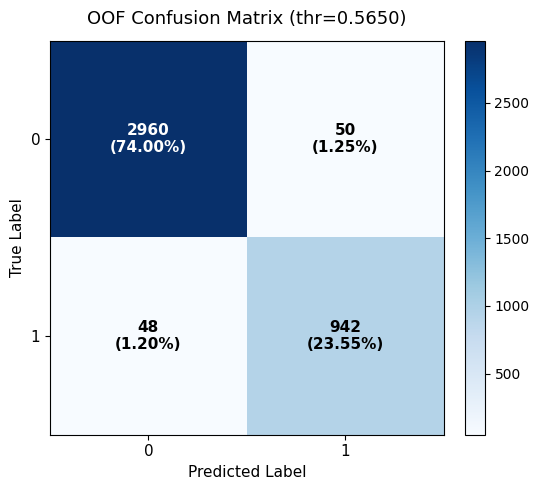


--------------------------------------------------------------------------------
OOF CALIBRATION INPUT PREVIEW (use for calibration / Platt / Isotonic)
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.003568
      0       0.010115
      0       0.003543
      1       0.773617
      0       0.005900
      1       0.981527
      0       0.002202
      0       0.002093
      0       0.005720
      0       0.008378

Shape: (4000, 2)


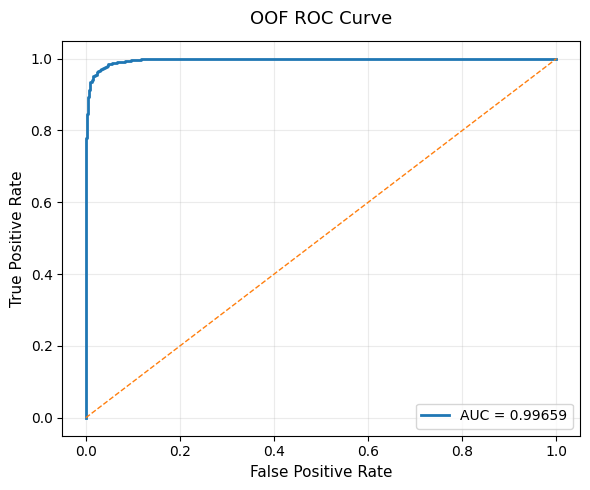


--------------------------------------------------------------------------------
OOF ROC ARRAYS PREVIEW
--------------------------------------------------------------------------------
     fpr      tpr  threshold
0.000000 0.000000        inf
0.000000 0.001010   0.990294
0.000000 0.021212   0.989687
0.000000 0.023232   0.989674
0.000000 0.628283   0.961246
0.000332 0.628283   0.961214
0.000332 0.733333   0.955341
0.000664 0.733333   0.955250
0.000664 0.759596   0.950485
0.000997 0.759596   0.950123

Shape: (150, 3)

--------------------------------------------------------------------------------
FINAL VALIDATION CALIBRATION INPUT PREVIEW (good for Platt / Isotonic)
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.000536
      0       0.003132
      0       0.000450
      1       0.993814
      0       0.040437
      1       0.996225
      1       0.994732
      0       0.000589
      0       0.000419
      0       

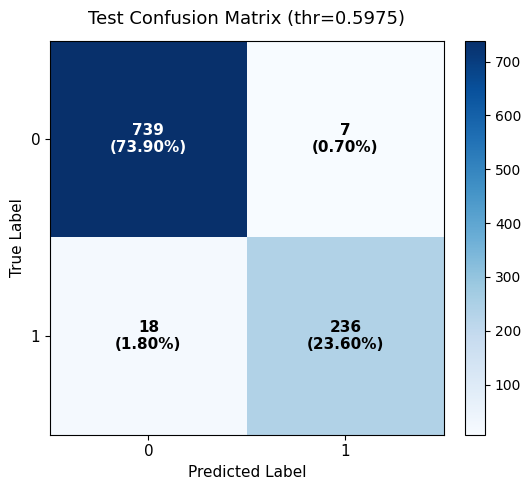


--------------------------------------------------------------------------------
TEST CALIBRATION INPUT PREVIEW
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.000431
      0       0.006645
      1       0.992757
      0       0.239640
      0       0.000477
      0       0.000503
      1       0.995668
      0       0.000565
      0       0.000470
      0       0.002105

Shape: (1000, 2)


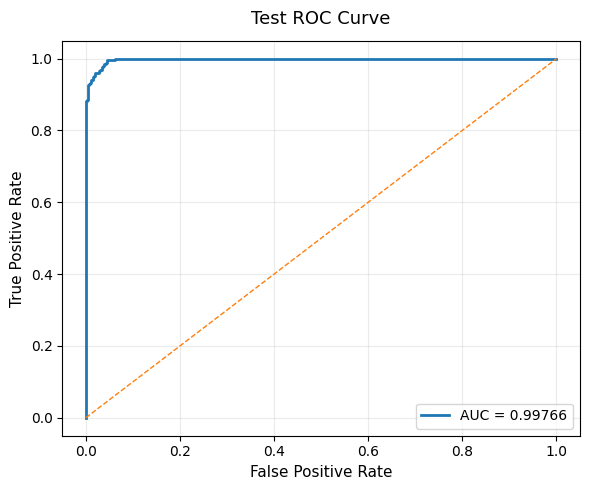


--------------------------------------------------------------------------------
TEST ROC ARRAYS PREVIEW
--------------------------------------------------------------------------------
     fpr      tpr  threshold
0.000000 0.000000        inf
0.000000 0.003937   0.996489
0.000000 0.846457   0.943357
0.001340 0.846457   0.942125
0.001340 0.881890   0.837873
0.002681 0.881890   0.826395
0.002681 0.885827   0.813057
0.004021 0.885827   0.775784
0.004021 0.889764   0.773723
0.005362 0.889764   0.748812

Shape: (44, 3)

READY VARIABLES IN MEMORY
                                     Use            Variable Name   Shape
                         OOF true labels   y_true_oof_calibration (4000,)
             OOF probabilities (class 1)   y_prob_oof_calibration (4000,)
            Final validation true labels y_true_valid_calibration  (400,)
Final validation probabilities (class 1) y_prob_valid_calibration  (400,)
                 Final validation logits logits_valid_temperature  (400,)
       

In [ ]:
import os
import json
import time
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    matthews_corrcoef,
    confusion_matrix,
    balanced_accuracy_score,
    brier_score_loss,
    roc_curve,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

TRAIN_PATH = "/content/train_fs_selected.csv"
TEST_PATH  = "/content/test_fs_selected.csv"
TARGET_COLUMN = "lung_cancer_risk"
ID_COLUMNS = []
DROP_COLUMNS = []

OUTPUT_DIR = "/content/fast_nested_tabsymformer_fast_f1fix"
SAVE_OUTPUTS = False
SHOW_PLOTS = False

SEED = 42

OUTER_FOLDS = 5
INNER_FOLDS = 2

N_TRIALS = 3
MAX_EPOCHS_INNER = 6
MAX_EPOCHS_OUTER = 10
MAX_EPOCHS_FINAL = 12

PATIENCE_INNER = 2
PATIENCE_OUTER = 3
PATIENCE_FINAL = 3

OUTER_DEV_VALID_SIZE = 0.12
FINAL_VALID_SIZE = 0.10

USE_AMP = True
NUM_WORKERS = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

THRESHOLD_GRID = np.linspace(0.16, 0.60, 177)
ACC_DROP_TOL = 0.0015

MIN_DYNAMIC_PRECISION = 0.970
PRECISION_RELAX = 0.012

USE_MILD_POS_WEIGHT = True
POS_WEIGHT_POWER = 0.35
POS_WEIGHT_MAX = 1.25

HP_ACC_TOL = 0.0015

FINAL_ENSEMBLE_SEEDS = [42]

SEARCH_CANDIDATES = [
    {"embed_dim": 128, "num_heads": 4, "depth": 2, "ff_mult": 2.0, "dropout": 0.08, "token_dropout": 0.01, "lr": 1.0e-3, "weight_decay": 1e-5, "batch_size": 2048},
    {"embed_dim": 160, "num_heads": 4, "depth": 2, "ff_mult": 2.0, "dropout": 0.10, "token_dropout": 0.02, "lr": 8.0e-4, "weight_decay": 1e-5, "batch_size": 2048},
    {"embed_dim": 192, "num_heads": 4, "depth": 3, "ff_mult": 2.0, "dropout": 0.10, "token_dropout": 0.02, "lr": 8.0e-4, "weight_decay": 1e-5, "batch_size": 1024},
]

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

def now():
    return time.strftime("%H:%M:%S")

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def safe_read_csv(path):
    if path is None or str(path).strip() == "":
        return None
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)

def to_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def clip_probs(prob, eps=1e-7):
    return np.clip(np.asarray(prob, dtype=np.float64), eps, 1 - eps)

def safe_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, prob))

def safe_pr_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, prob))

def metric_score_binary(y_true, y_pred, metric_name="accuracy"):
    if metric_name == "accuracy":
        return accuracy_score(y_true, y_pred)
    if metric_name == "f1":
        return f1_score(y_true, y_pred, zero_division=0)
    if metric_name == "mcc":
        return matthews_corrcoef(y_true, y_pred)
    if metric_name == "balanced_accuracy":
        return balanced_accuracy_score(y_true, y_pred)
    raise ValueError(f"Unsupported metric: {metric_name}")

def _threshold_table(y_true, prob, grid):
    rows = []
    prob = clip_probs(prob)

    for t in grid:
        pred = (prob >= t).astype(int)
        acc = accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)
        f1v = f1_score(y_true, pred, zero_division=0)
        mcc = matthews_corrcoef(y_true, pred)

        rows.append({
            "threshold": float(t),
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1v),
            "mcc": float(mcc),
        })

    return pd.DataFrame(rows)

def _pick_best_threshold_from_df(df_thr: pd.DataFrame) -> float:
    """
    Tie-break order after accuracy safety:
    1) max F1
    2) max Recall
    3) max Accuracy
    4) max MCC
    5) max Precision
    6) lower threshold
    """
    if df_thr.empty:
        return 0.50

    df_thr = df_thr.sort_values(
        by=["f1", "recall", "accuracy", "mcc", "precision", "threshold"],
        ascending=[False, False, False, False, False, True]
    ).reset_index(drop=True)

    return float(df_thr.loc[0, "threshold"])

def tune_threshold_constrained(
    y_true,
    prob,
    grid=None,
    acc_drop_tol=0.0015,
    min_dynamic_precision=0.970,
    precision_relax=0.012,
):
    """
    Accuracy-safe threshold tuning with dynamic precision protection.

    Steps:
    1) compute full threshold table
    2) keep thresholds within best-accuracy tolerance
    3) estimate precision at the best-accuracy operating region
    4) allow a small precision relaxation from that reference
    5) inside that safe region, maximize F1 -> Recall -> Accuracy -> MCC
    """
    if grid is None:
        grid = np.linspace(0.16, 0.60, 177)

    prob = clip_probs(prob)
    thr_df = _threshold_table(y_true, prob, grid)

    best_acc = float(thr_df["accuracy"].max())
    acc_floor = best_acc - float(acc_drop_tol)

    safe_df = thr_df.loc[thr_df["accuracy"] >= acc_floor].copy()
    if safe_df.empty:
        safe_df = thr_df.copy()

    best_acc_df = thr_df.loc[thr_df["accuracy"] >= best_acc - 1e-12].copy()
    best_acc_df = best_acc_df.sort_values(
        by=["f1", "recall", "mcc", "precision", "threshold"],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

    ref_precision = float(best_acc_df.loc[0, "precision"])
    precision_floor = max(float(min_dynamic_precision), ref_precision - float(precision_relax))

    guarded_df = safe_df.loc[safe_df["precision"] >= precision_floor].copy()
    if guarded_df.empty:
        guarded_df = safe_df.copy()

    return _pick_best_threshold_from_df(guarded_df)

def choose_best_hp_info(info_list, acc_tol=0.0015):
    """
    Keep only HPs within best accuracy tolerance,
    then choose the one with better F1 / recall / MCC.
    """
    rows = []
    for i, info in enumerate(info_list):
        m = info["metrics"]
        rows.append({
            "idx": i,
            "accuracy": float(m["accuracy"]),
            "f1": float(m["f1"]),
            "recall": float(m["recall"]),
            "precision": float(m["precision"]),
            "mcc": float(m["mcc"]),
            "logloss": float(m["logloss"]),
        })

    df = pd.DataFrame(rows)
    best_acc = float(df["accuracy"].max())

    keep = df.loc[df["accuracy"] >= best_acc - float(acc_tol)].copy()
    keep = keep.sort_values(
        by=["f1", "recall", "mcc", "precision", "accuracy", "logloss"],
        ascending=[False, False, False, False, False, True]
    ).reset_index(drop=True)

    return info_list[int(keep.loc[0, "idx"])]

def compute_metrics(y_true, prob, threshold=0.5):
    prob = clip_probs(prob)
    pred = (prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "specificity": float(specificity),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "roc_auc": safe_auc(y_true, prob),
        "pr_auc": safe_pr_auc(y_true, prob),
        "logloss": float(log_loss(y_true, prob, labels=[0, 1])),
        "brier": float(brier_score_loss(y_true, prob)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def plot_conf_matrix(cm, title="Confusion Matrix", class_names=("0", "1")):
    cm = np.asarray(cm)
    total = cm.sum()
    pct = (cm / total * 100.0) if total > 0 else np.zeros_like(cm, dtype=float)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)

    thresh = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f"{cm[i, j]}\n({pct[i, j]:.2f}%)",
                ha="center", va="center",
                fontsize=11,
                fontweight="bold",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()

def plot_roc_curve_from_prob(y_true, prob, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        print(f"{title}: skipped because only one class is present.")
        return None, None, None, np.nan

    fpr, tpr, thresholds = roc_curve(y_true, prob)
    auc_val = roc_auc_score(y_true, prob)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.5f}")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    ax.legend(loc="lower right")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return fpr, tpr, thresholds, auc_val

def print_preview_table(df, title, n=10):
    print("\n" + "-" * 80)
    print(title)
    print("-" * 80)
    print(df.head(n).to_string(index=False))
    print(f"\nShape: {df.shape}")

def hp_to_str(hp):
    return (
        f"embed={hp['embed_dim']} | heads={hp['num_heads']} | depth={hp['depth']} | "
        f"ff_mult={hp['ff_mult']} | drop={hp['dropout']} | tok_drop={hp['token_dropout']} | "
        f"lr={hp['lr']} | wd={hp['weight_decay']} | bs={hp['batch_size']}"
    )

class FoldPreprocessor:
    def __init__(self):
        self.imputer = SimpleImputer(strategy="median")
        self.scaler = StandardScaler()

    def fit(self, X_df):
        X_num = to_numeric_df(X_df)
        X_imp = self.imputer.fit_transform(X_num)
        self.scaler.fit(X_imp)
        return self

    def transform(self, X_df):
        X_num = to_numeric_df(X_df)
        X_imp = self.imputer.transform(X_num)
        X_scaled = self.scaler.transform(X_imp)
        X_scaled = np.clip(X_scaled, -8.0, 8.0).astype(np.float32)
        return X_scaled

    def fit_transform(self, X_df):
        self.fit(X_df)
        return self.transform(X_df)

class NumericFeatureTokenizer(nn.Module):
    """
    Each scalar feature becomes a learnable token.
    token_j = x_j * W_j + B_j + E_j
    """
    def __init__(self, n_features, embed_dim, token_dropout=0.01):
        super().__init__()
        self.n_features = n_features
        self.embed_dim = embed_dim
        self.token_dropout = float(token_dropout)

        self.weight = nn.Parameter(torch.randn(n_features, embed_dim) * 0.02)
        self.bias = nn.Parameter(torch.zeros(n_features, embed_dim))
        self.feature_embed = nn.Parameter(torch.randn(n_features, embed_dim) * 0.02)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        tokens = x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0) + self.feature_embed.unsqueeze(0)

        if self.training and self.token_dropout > 0:
            keep = (torch.rand((x.size(0), x.size(1), 1), device=x.device) > self.token_dropout).float()
            tokens = tokens * keep

        tokens = self.norm(tokens)
        return tokens

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_mult=2.0, dropout=0.10):
        super().__init__()
        ff_dim = int(embed_dim * ff_mult)

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.drop1 = nn.Dropout(dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff1 = nn.Linear(embed_dim, ff_dim * 2)
        self.ff2 = nn.Linear(ff_dim, embed_dim)
        self.drop2 = nn.Dropout(dropout)

        self.gate = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        y = self.norm1(x)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x = x + self.drop1(attn_out)

        y = self.norm2(x)
        a, b = self.ff1(y).chunk(2, dim=-1)
        y = a * F.gelu(b)
        y = self.ff2(self.drop2(y))

        gate = self.gate(x)
        x = x + gate * y
        return x

class TabFGT(nn.Module):
    """
    Faster custom transformer for encoded numeric tabular data.
    Lighter head: CLS + mean pooling only.
    """
    def __init__(
        self,
        input_dim,
        embed_dim=160,
        num_heads=4,
        depth=2,
        ff_mult=2.0,
        dropout=0.10,
        token_dropout=0.01,
    ):
        super().__init__()

        self.tokenizer = NumericFeatureTokenizer(
            n_features=input_dim,
            embed_dim=embed_dim,
            token_dropout=token_dropout
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.cls_bias = nn.Parameter(torch.zeros(1, 1, embed_dim))

        self.blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ff_mult=ff_mult,
                dropout=dropout
            )
            for _ in range(depth)
        ])

        self.final_norm = nn.LayerNorm(embed_dim)

        head_dim = embed_dim * 2
        hidden2 = max(embed_dim, 128)

        self.head = nn.Sequential(
            nn.LayerNorm(head_dim),
            nn.Linear(head_dim, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, hidden2 // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2 // 2, 1),
        )

    def forward(self, x):
        tok = self.tokenizer(x)
        cls = self.cls_token.expand(x.size(0), -1, -1) + self.cls_bias
        tok = torch.cat([cls, tok], dim=1)

        for block in self.blocks:
            tok = block(tok)

        tok = self.final_norm(tok)

        cls_tok = tok[:, 0]
        feat_tok = tok[:, 1:]
        mean_tok = feat_tok.mean(dim=1)

        rep = torch.cat([cls_tok, mean_tok], dim=1)
        out = self.head(rep).squeeze(1)
        return out

def make_loader(X, y=None, batch_size=1024, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    if y is None:
        ds = TensorDataset(X_t)
    else:
        y_t = torch.tensor(y, dtype=torch.float32)
        ds = TensorDataset(X_t, y_t)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )

@torch.no_grad()
def predict_proba(model, X, batch_size=1024):
    model.eval()
    loader = make_loader(X, y=None, batch_size=batch_size, shuffle=False)
    probs = []

    for batch in loader:
        xb = batch[0].to(DEVICE, non_blocking=True)
        logits = model(xb)
        p = torch.sigmoid(logits).detach().cpu().numpy()
        probs.append(p)

    return np.concatenate(probs).astype(np.float64)

@torch.no_grad()
def predict_logits(model, X, batch_size=1024):
    model.eval()
    loader = make_loader(X, y=None, batch_size=batch_size, shuffle=False)
    logits_all = []

    for batch in loader:
        xb = batch[0].to(DEVICE, non_blocking=True)
        logits = model(xb).detach().cpu().numpy()
        logits_all.append(logits)

    return np.concatenate(logits_all).astype(np.float64)

def train_one_model(
    X_train, y_train,
    X_valid, y_valid,
    hp,
    max_epochs=12,
    patience=3,
    seed=42
):
    set_seed(seed)

    model = TabFGT(
        input_dim=X_train.shape[1],
        embed_dim=hp["embed_dim"],
        num_heads=hp["num_heads"],
        depth=hp["depth"],
        ff_mult=hp["ff_mult"],
        dropout=hp["dropout"],
        token_dropout=hp["token_dropout"],
    ).to(DEVICE)

    train_loader = make_loader(X_train, y_train, batch_size=hp["batch_size"], shuffle=True)
    valid_loader = make_loader(X_valid, y_valid, batch_size=max(1024, hp["batch_size"]), shuffle=False)

    pos_count = max(float(np.sum(np.asarray(y_train) == 1)), 1.0)
    neg_count = max(float(np.sum(np.asarray(y_train) == 0)), 1.0)

    if USE_MILD_POS_WEIGHT:
        pos_weight_value = float(np.clip((neg_count / pos_count) ** POS_WEIGHT_POWER, 1.0, POS_WEIGHT_MAX))
    else:
        pos_weight_value = 1.0

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"]
    )

    steps_per_epoch = max(1, len(train_loader))
    total_steps = max(1, max_epochs * steps_per_epoch)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=hp["lr"],
        total_steps=total_steps,
        pct_start=0.20,
        div_factor=8.0,
        final_div_factor=80.0,
    )

    use_amp_now = bool(USE_AMP and DEVICE.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp_now)

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = np.inf
    best_epoch = 0
    bad_epochs = 0
    min_delta = 5e-4

    for epoch in range(1, max_epochs + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp_now):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

        model.eval()
        val_probs = []
        for xb, _ in valid_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp_now):
                logits = model(xb)
                p = torch.sigmoid(logits)
            val_probs.append(p.detach().cpu().numpy())

        val_probs = np.concatenate(val_probs).astype(np.float64)
        val_loss = log_loss(y_valid, clip_probs(val_probs), labels=[0, 1])

        if val_loss < best_val_loss - min_delta:
            best_val_loss = float(val_loss)
            best_epoch = int(epoch)
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    model.load_state_dict(best_state)
    return model, best_epoch, best_val_loss, pos_weight_value

def inner_cv_score(X_df, y, hp, seed=42):
    skf = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=seed)
    oof_prob = np.zeros(len(y), dtype=np.float64)
    pos_weights_used = []

    for inner_fold, (tr_idx, va_idx) in enumerate(skf.split(X_df, y), start=1):
        X_tr_df = X_df.iloc[tr_idx].reset_index(drop=True)
        X_va_df = X_df.iloc[va_idx].reset_index(drop=True)
        y_tr = y[tr_idx]
        y_va = y[va_idx]

        prep = FoldPreprocessor()
        X_tr = prep.fit_transform(X_tr_df)
        X_va = prep.transform(X_va_df)

        model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
            X_tr, y_tr,
            X_va, y_va,
            hp=hp,
            max_epochs=MAX_EPOCHS_INNER,
            patience=PATIENCE_INNER,
            seed=seed + inner_fold * 77
        )
        pos_weights_used.append(float(pos_weight_value))

        prob = predict_proba(model, X_va, batch_size=max(1024, hp["batch_size"]))
        oof_prob[va_idx] = prob

    best_thr = tune_threshold_constrained(
        y_true=y,
        prob=oof_prob,
        grid=THRESHOLD_GRID,
        acc_drop_tol=ACC_DROP_TOL,
        min_dynamic_precision=MIN_DYNAMIC_PRECISION,
        precision_relax=PRECISION_RELAX,
    )
    metrics = compute_metrics(y, oof_prob, threshold=best_thr)

    return {
        "hp": hp,
        "threshold": best_thr,
        "metrics": metrics,
        "score": metrics["accuracy"],
        "mean_pos_weight": float(np.mean(pos_weights_used)) if len(pos_weights_used) > 0 else 1.0,
    }

set_seed(SEED)
ensure_dir(OUTPUT_DIR)

print("\n" + "=" * 80)
print(f"[{now()}] LOADING DATA")
print("=" * 80)

train_df = safe_read_csv(TRAIN_PATH)
test_df = safe_read_csv(TEST_PATH)

if TARGET_COLUMN not in train_df.columns:
    raise ValueError(f"Target column '{TARGET_COLUMN}' not found.")

drop_train = list(set(ID_COLUMNS + DROP_COLUMNS + [TARGET_COLUMN]))
X_train_df = train_df.drop(columns=[c for c in drop_train if c in train_df.columns], errors="ignore").copy()
y_raw = train_df[TARGET_COLUMN].copy()

le = LabelEncoder()
y = le.fit_transform(y_raw)

if len(le.classes_) != 2:
    raise ValueError(f"Binary classification only. Found classes: {list(le.classes_)}")

class_names = [str(x) for x in le.classes_]

print(f"Train shape   : {train_df.shape}")
print(f"Feature shape : {X_train_df.shape}")
print(f"Classes       : {class_names}")
print(f"Device        : {DEVICE}")

if test_df is not None:
    drop_test = list(set(ID_COLUMNS + DROP_COLUMNS + [TARGET_COLUMN]))
    X_test_df = test_df.drop(columns=[c for c in drop_test if c in test_df.columns], errors="ignore").copy()

    if TARGET_COLUMN in test_df.columns:
        y_test = le.transform(test_df[TARGET_COLUMN])
        has_test_labels = True
    else:
        y_test = None
        has_test_labels = False

    print(f"Test shape    : {test_df.shape}")
    print(f"Test labels   : {'present' if has_test_labels else 'absent'}")
else:
    X_test_df = None
    y_test = None
    has_test_labels = False

print("\n" + "=" * 80)
print(f"[{now()}] STARTING NESTED CV ({OUTER_FOLDS} OUTER x {INNER_FOLDS} INNER)")
print("=" * 80)

outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)

oof_prob = np.zeros(len(y), dtype=np.float64)
outer_rows = []
outer_thresholds = []
outer_best_hps = []
outer_test_probs = []

candidate_pool = SEARCH_CANDIDATES[:N_TRIALS]

for outer_fold, (dev_idx, hold_idx) in enumerate(outer_cv.split(X_train_df, y), start=1):
    print(f"\n[{now()}] OUTER FOLD {outer_fold}/{OUTER_FOLDS}")

    X_dev_df = X_train_df.iloc[dev_idx].reset_index(drop=True)
    y_dev = y[dev_idx]

    X_hold_df = X_train_df.iloc[hold_idx].reset_index(drop=True)
    y_hold = y[hold_idx]

    fold_infos = []

    for trial_id, hp in enumerate(candidate_pool, start=1):
        info = inner_cv_score(
            X_df=X_dev_df,
            y=y_dev,
            hp=hp,
            seed=SEED + outer_fold * 100 + trial_id
        )
        fold_infos.append(info)

        m = info["metrics"]
        print(
            f"  trial {trial_id}/{len(candidate_pool)} | "
            f"acc={m['accuracy']:.5f} | f1={m['f1']:.5f} | rec={m['recall']:.5f} | "
            f"prec={m['precision']:.5f} | mcc={m['mcc']:.5f} | "
            f"auc={m['roc_auc']:.5f} | logloss={m['logloss']:.5f} | "
            f"thr={info['threshold']:.3f} | pos_w={info['mean_pos_weight']:.3f}"
        )

    best_info = choose_best_hp_info(fold_infos, acc_tol=HP_ACC_TOL)
    best_hp = best_info["hp"]
    best_thr = best_info["threshold"]

    outer_best_hps.append(best_hp)
    outer_thresholds.append(best_thr)

    print(f"  best hp  : {hp_to_str(best_hp)}")
    print(f"  best thr : {best_thr:.3f}")

    X_tr_df, X_va_df, y_tr, y_va = train_test_split(
        X_dev_df, y_dev,
        test_size=OUTER_DEV_VALID_SIZE,
        random_state=SEED + outer_fold,
        stratify=y_dev
    )

    prep = FoldPreprocessor()
    X_tr = prep.fit_transform(X_tr_df)
    X_va = prep.transform(X_va_df)
    X_hold = prep.transform(X_hold_df)

    model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
        X_tr, y_tr,
        X_va, y_va,
        hp=best_hp,
        max_epochs=MAX_EPOCHS_OUTER,
        patience=PATIENCE_OUTER,
        seed=SEED + outer_fold * 1000
    )

    hold_prob = predict_proba(model, X_hold, batch_size=max(1024, best_hp["batch_size"]))
    oof_prob[hold_idx] = hold_prob

    fold_metrics = compute_metrics(y_hold, hold_prob, threshold=best_thr)
    fold_metrics["outer_fold"] = outer_fold
    fold_metrics["best_epoch"] = best_epoch
    fold_metrics["best_val_loss"] = best_val_loss
    fold_metrics["pos_weight"] = float(pos_weight_value)
    outer_rows.append(fold_metrics)

    print(
        f"  fold result | acc={fold_metrics['accuracy']:.5f} | "
        f"prec={fold_metrics['precision']:.5f} | rec={fold_metrics['recall']:.5f} | "
        f"spec={fold_metrics['specificity']:.5f} | f1={fold_metrics['f1']:.5f} | "
        f"mcc={fold_metrics['mcc']:.5f} | auc={fold_metrics['roc_auc']:.5f} | "
        f"logloss={fold_metrics['logloss']:.5f}"
    )

    if X_test_df is not None:
        X_test_proc = prep.transform(X_test_df)
        test_prob_fold = predict_proba(model, X_test_proc, batch_size=max(1024, best_hp["batch_size"]))
        outer_test_probs.append(test_prob_fold)

outer_df = pd.DataFrame(outer_rows)

global_threshold = tune_threshold_constrained(
    y_true=y,
    prob=oof_prob,
    grid=THRESHOLD_GRID,
    acc_drop_tol=ACC_DROP_TOL,
    min_dynamic_precision=MIN_DYNAMIC_PRECISION,
    precision_relax=PRECISION_RELAX,
)

oof_metrics = compute_metrics(y, oof_prob, threshold=global_threshold)

print("\n" + "=" * 80)
print(f"[{now()}] NESTED CV SUMMARY")
print("=" * 80)
print(outer_df[
    ["outer_fold", "accuracy", "precision", "recall", "specificity", "f1",
     "mcc", "balanced_accuracy", "roc_auc", "pr_auc", "logloss", "threshold", "pos_weight"]
].round(5).to_string(index=False))

print("\nOOF SUMMARY")
print(pd.DataFrame([oof_metrics]).round(5).to_string(index=False))

if SHOW_PLOTS:
    cm_oof = confusion_matrix(y, (oof_prob >= global_threshold).astype(int), labels=[0, 1])
    plot_conf_matrix(
        cm_oof,
        title=f"OOF Confusion Matrix (thr={global_threshold:.3f})",
        class_names=class_names
    )

hp_keys = [tuple(sorted(hp.items())) for hp in outer_best_hps]
hp_counter = Counter(hp_keys)
max_count = max(hp_counter.values())
candidates = [dict(k) for k, v in hp_counter.items() if v == max_count]

if len(candidates) == 1:
    final_best_hp = candidates[0]
else:
    rows = []
    for cand in candidates:
        mask = [hp == cand for hp in outer_best_hps]
        rows.append({
            "hp": cand,
            "mean_acc": float(outer_df.loc[mask, "accuracy"].mean()),
            "mean_f1": float(outer_df.loc[mask, "f1"].mean()),
            "mean_recall": float(outer_df.loc[mask, "recall"].mean()),
            "mean_mcc": float(outer_df.loc[mask, "mcc"].mean()),
            "mean_logloss": float(outer_df.loc[mask, "logloss"].mean()),
        })

    hp_df = pd.DataFrame(rows)
    best_mean_acc = float(hp_df["mean_acc"].max())

    keep = hp_df.loc[hp_df["mean_acc"] >= best_mean_acc - HP_ACC_TOL].copy()
    keep = keep.sort_values(
        by=["mean_f1", "mean_recall", "mean_mcc", "mean_acc", "mean_logloss"],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

    final_best_hp = keep.iloc[0]["hp"]

print("\n" + "=" * 80)
print(f"[{now()}] FINAL CHOSEN SETTINGS")
print("=" * 80)
print("Final best hyperparameters:")
print(json.dumps(final_best_hp, indent=2))
print(f"OOF-derived threshold: {global_threshold:.4f}")

final_models = []
final_preps = []
final_valid_probs = []
final_valid_targets = []
final_valid_logits = []

for i, seed_i in enumerate(FINAL_ENSEMBLE_SEEDS, start=1):
    print(f"\n[{now()}] FINAL MODEL {i}/{len(FINAL_ENSEMBLE_SEEDS)}")

    X_tr_df, X_va_df, y_tr, y_va = train_test_split(
        X_train_df, y,
        test_size=FINAL_VALID_SIZE,
        random_state=seed_i,
        stratify=y
    )

    prep = FoldPreprocessor()
    X_tr = prep.fit_transform(X_tr_df)
    X_va = prep.transform(X_va_df)

    model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
        X_tr, y_tr,
        X_va, y_va,
        hp=final_best_hp,
        max_epochs=MAX_EPOCHS_FINAL,
        patience=PATIENCE_FINAL,
        seed=seed_i
    )

    final_models.append(model)
    final_preps.append(prep)

    va_prob = predict_proba(model, X_va, batch_size=max(1024, final_best_hp["batch_size"]))
    va_logit = predict_logits(model, X_va, batch_size=max(1024, final_best_hp["batch_size"]))

    final_valid_probs.append(va_prob)
    final_valid_targets.append(np.asarray(y_va, dtype=int))
    final_valid_logits.append(va_logit)

    print(
        f"  best_epoch={best_epoch} | best_val_loss={best_val_loss:.5f} | "
        f"pos_weight={pos_weight_value:.3f}"
    )

def predict_ensemble(models, preps, X_df, batch_size=1024):
    probs = []
    for model, prep in zip(models, preps):
        X_proc = prep.transform(X_df)
        p = predict_proba(model, X_proc, batch_size=batch_size)
        probs.append(p)
    return np.mean(np.vstack(probs), axis=0)

final_valid_prob = None
final_valid_y = None
final_valid_logit = None

if len(final_valid_probs) > 0:
    final_valid_prob = np.concatenate(final_valid_probs).astype(np.float64)
    final_valid_y = np.concatenate(final_valid_targets).astype(int)
    final_valid_logit = np.concatenate(final_valid_logits).astype(np.float64)

    final_threshold = tune_threshold_constrained(
        y_true=final_valid_y,
        prob=final_valid_prob,
        grid=THRESHOLD_GRID,
        acc_drop_tol=ACC_DROP_TOL,
        min_dynamic_precision=MIN_DYNAMIC_PRECISION,
        precision_relax=PRECISION_RELAX,
    )
else:
    final_threshold = global_threshold

print(f"\n[{now()}] FINAL DEPLOYMENT THRESHOLD: {final_threshold:.4f}")

if X_test_df is not None:
    print("\n" + "=" * 80)
    print(f"[{now()}] TEST RESULT")
    print("=" * 80)

    final_test_prob = predict_ensemble(
        final_models,
        final_preps,
        X_test_df,
        batch_size=max(1024, final_best_hp["batch_size"])
    )
    final_test_pred = (final_test_prob >= final_threshold).astype(int)

    if has_test_labels:
        test_metrics = compute_metrics(y_test, final_test_prob, threshold=final_threshold)
        print(pd.DataFrame([test_metrics]).round(5).to_string(index=False))

        if SHOW_PLOTS:
            cm_test = confusion_matrix(y_test, final_test_pred, labels=[0, 1])
            plot_conf_matrix(
                cm_test,
                title=f"Test Confusion Matrix (thr={final_threshold:.3f})",
                class_names=class_names
            )

        if len(outer_test_probs) > 0:
            nested_test_prob = np.mean(np.vstack(outer_test_probs), axis=0)
            nested_test_metrics = compute_metrics(y_test, nested_test_prob, threshold=global_threshold)

            print("\nOuter-fold test ensemble reference:")
            print(pd.DataFrame([nested_test_metrics]).round(5).to_string(index=False))
    else:
        test_metrics = None
        print("Test labels not available.")
else:
    final_test_prob = None
    final_test_pred = None
    test_metrics = None

if SAVE_OUTPUTS:
    ensure_dir(OUTPUT_DIR)

    outer_df.to_csv(os.path.join(OUTPUT_DIR, "outer_fold_results.csv"), index=False)
    pd.DataFrame([oof_metrics]).to_csv(os.path.join(OUTPUT_DIR, "oof_metrics.csv"), index=False)

    with open(os.path.join(OUTPUT_DIR, "final_best_hyperparameters.json"), "w") as f:
        json.dump(
            {
                "best_hyperparameters": final_best_hp,
                "oof_global_threshold": global_threshold,
                "final_threshold": final_threshold,
                "classes": class_names,
                "device": str(DEVICE),
                "model_name": "TabFGT-Fast-F1Fix",
                "threshold_grid_start": float(THRESHOLD_GRID[0]),
                "threshold_grid_end": float(THRESHOLD_GRID[-1]),
                "acc_drop_tol": float(ACC_DROP_TOL),
                "min_dynamic_precision": float(MIN_DYNAMIC_PRECISION),
                "precision_relax": float(PRECISION_RELAX),
                "use_mild_pos_weight": bool(USE_MILD_POS_WEIGHT),
                "pos_weight_power": float(POS_WEIGHT_POWER),
                "pos_weight_max": float(POS_WEIGHT_MAX),
                "hp_acc_tol": float(HP_ACC_TOL),
            },
            f,
            indent=2
        )

    oof_pred = (oof_prob >= global_threshold).astype(int)
    oof_df = pd.DataFrame({
        "true_label_encoded": y,
        "true_label": [class_names[i] for i in y],
        "prob_positive": oof_prob,
        "pred_label_encoded": oof_pred,
        "pred_label": [class_names[i] for i in oof_pred],
    })
    if ID_COLUMNS:
        ids = [c for c in ID_COLUMNS if c in train_df.columns]
        if len(ids) > 0:
            oof_df = pd.concat([train_df[ids].reset_index(drop=True), oof_df], axis=1)
    oof_df.to_csv(os.path.join(OUTPUT_DIR, "oof_predictions.csv"), index=False)

    if X_test_df is not None:
        test_out = pd.DataFrame({
            "prob_positive": final_test_prob,
            "pred_label_encoded": final_test_pred,
            "pred_label": [class_names[i] for i in final_test_pred],
        })
        if ID_COLUMNS:
            ids = [c for c in ID_COLUMNS if c in test_df.columns]
            if len(ids) > 0:
                test_out = pd.concat([test_df[ids].reset_index(drop=True), test_out], axis=1)
        test_out.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)

    print("\nSaved outputs in:", OUTPUT_DIR)

print("\n" + "=" * 80)
print(f"[{now()}] FINAL REPORT")
print("=" * 80)
print(f"Model         : TabFGT-Fast-F1Fix")
print(f"Final HP      : {hp_to_str(final_best_hp)}")
print(f"OOF thr       : {global_threshold:.4f}")
print(f"Final thr     : {final_threshold:.4f}")
print(f"OOF accuracy  : {oof_metrics['accuracy']:.5f}")
print(f"OOF precision : {oof_metrics['precision']:.5f}")
print(f"OOF recall    : {oof_metrics['recall']:.5f}")
print(f"OOF spec      : {oof_metrics['specificity']:.5f}")
print(f"OOF f1        : {oof_metrics['f1']:.5f}")
print(f"OOF mcc       : {oof_metrics['mcc']:.5f}")
print(f"OOF roc_auc   : {oof_metrics['roc_auc']:.5f}")
print(f"OOF logloss   : {oof_metrics['logloss']:.5f}")

if test_metrics is not None:
    print("\nTEST headline metrics")
    print(f"Test accuracy : {test_metrics['accuracy']:.5f}")
    print(f"Test precision: {test_metrics['precision']:.5f}")
    print(f"Test recall   : {test_metrics['recall']:.5f}")
    print(f"Test spec     : {test_metrics['specificity']:.5f}")
    print(f"Test f1       : {test_metrics['f1']:.5f}")
    print(f"Test mcc      : {test_metrics['mcc']:.5f}")
    print(f"Test roc_auc  : {test_metrics['roc_auc']:.5f}")
    print(f"Test logloss  : {test_metrics['logloss']:.5f}")

print("\n" + "=" * 80)
print(f"[{now()}] DISPLAY OUTPUTS")
print("=" * 80)

y_true_oof_calibration = np.asarray(y, dtype=int)
y_prob_oof_calibration = np.asarray(oof_prob, dtype=np.float64)
y_pred_oof_display = (y_prob_oof_calibration >= global_threshold).astype(int)

cm_oof_display = confusion_matrix(y_true_oof_calibration, y_pred_oof_display, labels=[0, 1])

print("\nOOF CONFUSION MATRIX")
print(pd.DataFrame(
    cm_oof_display,
    index=[f"True_{class_names[0]}", f"True_{class_names[1]}"],
    columns=[f"Pred_{class_names[0]}", f"Pred_{class_names[1]}"]
).to_string())

plot_conf_matrix(
    cm_oof_display,
    title=f"OOF Confusion Matrix (thr={global_threshold:.4f})",
    class_names=class_names
)

oof_calibration_df = pd.DataFrame({
    "y_true": y_true_oof_calibration,
    "y_prob_class1": y_prob_oof_calibration
})

print_preview_table(
    oof_calibration_df,
    "OOF CALIBRATION INPUT PREVIEW (use for calibration / Platt / Isotonic)",
    n=10
)

oof_roc_fpr, oof_roc_tpr, oof_roc_thresholds, oof_roc_auc = plot_roc_curve_from_prob(
    y_true_oof_calibration,
    y_prob_oof_calibration,
    title="OOF ROC Curve"
)

if oof_roc_fpr is not None:
    oof_roc_df = pd.DataFrame({
        "fpr": oof_roc_fpr,
        "tpr": oof_roc_tpr,
        "threshold": oof_roc_thresholds
    })
    print_preview_table(
        oof_roc_df,
        "OOF ROC ARRAYS PREVIEW",
        n=10
    )

if final_valid_prob is not None and final_valid_y is not None:
    y_true_valid_calibration = np.asarray(final_valid_y, dtype=int)
    y_prob_valid_calibration = np.asarray(final_valid_prob, dtype=np.float64)

    valid_calibration_df = pd.DataFrame({
        "y_true": y_true_valid_calibration,
        "y_prob_class1": y_prob_valid_calibration
    })

    print_preview_table(
        valid_calibration_df,
        "FINAL VALIDATION CALIBRATION INPUT PREVIEW (good for Platt / Isotonic)",
        n=10
    )

    if final_valid_logit is not None:
        logits_valid_temperature = np.asarray(final_valid_logit, dtype=np.float64)

        valid_temperature_df = pd.DataFrame({
            "y_true": y_true_valid_calibration,
            "logit": logits_valid_temperature
        })

        print_preview_table(
            valid_temperature_df,
            "FINAL VALIDATION TEMPERATURE-SCALING INPUT PREVIEW (y_true + logits)",
            n=10
        )
    else:
        logits_valid_temperature = None
else:
    y_true_valid_calibration = None
    y_prob_valid_calibration = None
    logits_valid_temperature = None

if final_test_prob is not None and has_test_labels:
    y_true_test_calibration = np.asarray(y_test, dtype=int)
    y_prob_test_calibration = np.asarray(final_test_prob, dtype=np.float64)
    y_pred_test_display = (y_prob_test_calibration >= final_threshold).astype(int)

    cm_test_display = confusion_matrix(y_true_test_calibration, y_pred_test_display, labels=[0, 1])

    print("\nTEST CONFUSION MATRIX")
    print(pd.DataFrame(
        cm_test_display,
        index=[f"True_{class_names[0]}", f"True_{class_names[1]}"],
        columns=[f"Pred_{class_names[0]}", f"Pred_{class_names[1]}"]
    ).to_string())

    plot_conf_matrix(
        cm_test_display,
        title=f"Test Confusion Matrix (thr={final_threshold:.4f})",
        class_names=class_names
    )

    test_calibration_df = pd.DataFrame({
        "y_true": y_true_test_calibration,
        "y_prob_class1": y_prob_test_calibration
    })

    print_preview_table(
        test_calibration_df,
        "TEST CALIBRATION INPUT PREVIEW",
        n=10
    )

    test_roc_fpr, test_roc_tpr, test_roc_thresholds, test_roc_auc = plot_roc_curve_from_prob(
        y_true_test_calibration,
        y_prob_test_calibration,
        title="Test ROC Curve"
    )

    if test_roc_fpr is not None:
        test_roc_df = pd.DataFrame({
            "fpr": test_roc_fpr,
            "tpr": test_roc_tpr,
            "threshold": test_roc_thresholds
        })
        print_preview_table(
            test_roc_df,
            "TEST ROC ARRAYS PREVIEW",
            n=10
        )
else:
    y_true_test_calibration = None
    y_prob_test_calibration = None
    test_roc_fpr = None
    test_roc_tpr = None
    test_roc_thresholds = None
    test_roc_auc = None

print("\n" + "=" * 80)
print("READY VARIABLES IN MEMORY")
print("=" * 80)

ready_rows = [
    ["OOF true labels", "y_true_oof_calibration", None if y_true_oof_calibration is None else y_true_oof_calibration.shape],
    ["OOF probabilities (class 1)", "y_prob_oof_calibration", None if y_prob_oof_calibration is None else y_prob_oof_calibration.shape],
    ["Final validation true labels", "y_true_valid_calibration", None if y_true_valid_calibration is None else y_true_valid_calibration.shape],
    ["Final validation probabilities (class 1)", "y_prob_valid_calibration", None if y_prob_valid_calibration is None else y_prob_valid_calibration.shape],
    ["Final validation logits", "logits_valid_temperature", None if logits_valid_temperature is None else logits_valid_temperature.shape],
    ["Test true labels", "y_true_test_calibration", None if y_true_test_calibration is None else y_true_test_calibration.shape],
    ["Test probabilities (class 1)", "y_prob_test_calibration", None if y_prob_test_calibration is None else y_prob_test_calibration.shape],
    ["OOF ROC FPR", "oof_roc_fpr", None if oof_roc_fpr is None else oof_roc_fpr.shape],
    ["OOF ROC TPR", "oof_roc_tpr", None if oof_roc_tpr is None else oof_roc_tpr.shape],
    ["OOF ROC thresholds", "oof_roc_thresholds", None if oof_roc_thresholds is None else oof_roc_thresholds.shape],
    ["Test ROC FPR", "test_roc_fpr", None if test_roc_fpr is None else test_roc_fpr.shape],
    ["Test ROC TPR", "test_roc_tpr", None if test_roc_tpr is None else test_roc_tpr.shape],
    ["Test ROC thresholds", "test_roc_thresholds", None if test_roc_thresholds is None else test_roc_thresholds.shape],
]

ready_df = pd.DataFrame(ready_rows, columns=["Use", "Variable Name", "Shape"])
print(ready_df.to_string(index=False))

print("\nBEST TO USE FOR CALIBRATION")
print("- OOF true labels + OOF probabilities      : y_true_oof_calibration, y_prob_oof_calibration")
if y_true_test_calibration is not None and y_prob_test_calibration is not None:
    print("- Test true labels + test probabilities    : y_true_test_calibration, y_prob_test_calibration")
if y_true_valid_calibration is not None and y_prob_valid_calibration is not None:
    print("- Validation true labels + probabilities   : y_true_valid_calibration, y_prob_valid_calibration")
if logits_valid_temperature is not None and y_true_valid_calibration is not None:
    print("- Temperature scaling inputs               : y_true_valid_calibration, logits_valid_temperature")

print("\nBEST TO USE FOR ROC")
print("- OOF ROC arrays  : oof_roc_fpr, oof_roc_tpr, oof_roc_thresholds")
if test_roc_fpr is not None:
    print("- Test ROC arrays : test_roc_fpr, test_roc_tpr, test_roc_thresholds")